# Código. Análisis Poblacional de Registros Electrofisiológicos   
### Daniel Yedra Cázares
### Instituto de Fisiología Celular, UNAM

**Propósito.** Practicar con código las diferentes secciónes del texto

**Qué aprenderás**
1. Cargar/generar señales y **visualizarlas**.
2. Mitigación de Errores: **Fuga espectral, Ventanas, Tapers, Wavelets, etc**.
5. Calcular **ITPC** y visualización
6. Ejemplos de **Reducción de dimensiónes**
7. **Ejercicios** cortos 
8. **Apéndice**

## Tabla de contenidos:
[1. Introducción](#introduction)

[2. Mitigación errores ](#EM)

[2.1. Ventanas](#Vent)

[2.2. Tapers](#Tap)

[2.3. Wavelets](#Wav)

[2.5 Ejercicios](#EjerMit)

[3. Análisis Tiempo-Frecuencia](#AT-F)

[3.1 Normalizaciónes Basales](#NB)

[3.2 Cálculo de ITPC y representación](#ITPC)

[4 Apéndices](#Apen)


## Introducción 

El objetivo de este cuaderno es ayudar a entendimientos de herramientas para el análisis y afianzar conceptos con ejemplos gráficos. 

### Inicializar el cuaderno

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp
from scipy.signal import spectrogram, windows
from scipy.signal.windows import dpss
from scipy.signal import get_window
from scipy.signal import windows, spectrogram
from scipy.special import legendre
from scipy.integrate import quad
import scipy.sparse as sparse
from scipy.sparse.linalg import eigs
from scipy.special import pro_ang1
from scipy.signal import windows
import math
from scipy.signal import butter, filtfilt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.decomposition import FastICA
from sklearn.decomposition import PCA
from scipy.io import wavfile
import scipy.io.wavfile as wf
from IPython.display import Image
from scipy.signal import hilbert, stft

> **Explicación breve:** Esta celda centraliza todas las dependencias usadas en el notebook para que las importaciones no se repitan en cada bloque.


#### Ejemplo de instalación de paquetes y actualización de pip

In [1]:
# En caso de ser necesario
!pip install --upgrade pip

In [9]:
pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 10.8 MB/s eta 0:00:0031m9.8 MB/s eta 0:00:01

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Código para mejor visualización de gráficas

%matplotlib inline 



%config InlineBackend.figure_formats = {'png', 'retina'} 
plt.rcParams['axes.labelsize'] = 18 
plt.rcParams['axes.titlesize'] = 20 
plt.rcParams['font.size'] = 16 
plt.rcParams['lines.linewidth'] = 1.6


## LFP, ERP y Bootstrap


Pico observado: 1.826 | IC95% bootstrap: [1.782, 1.869]


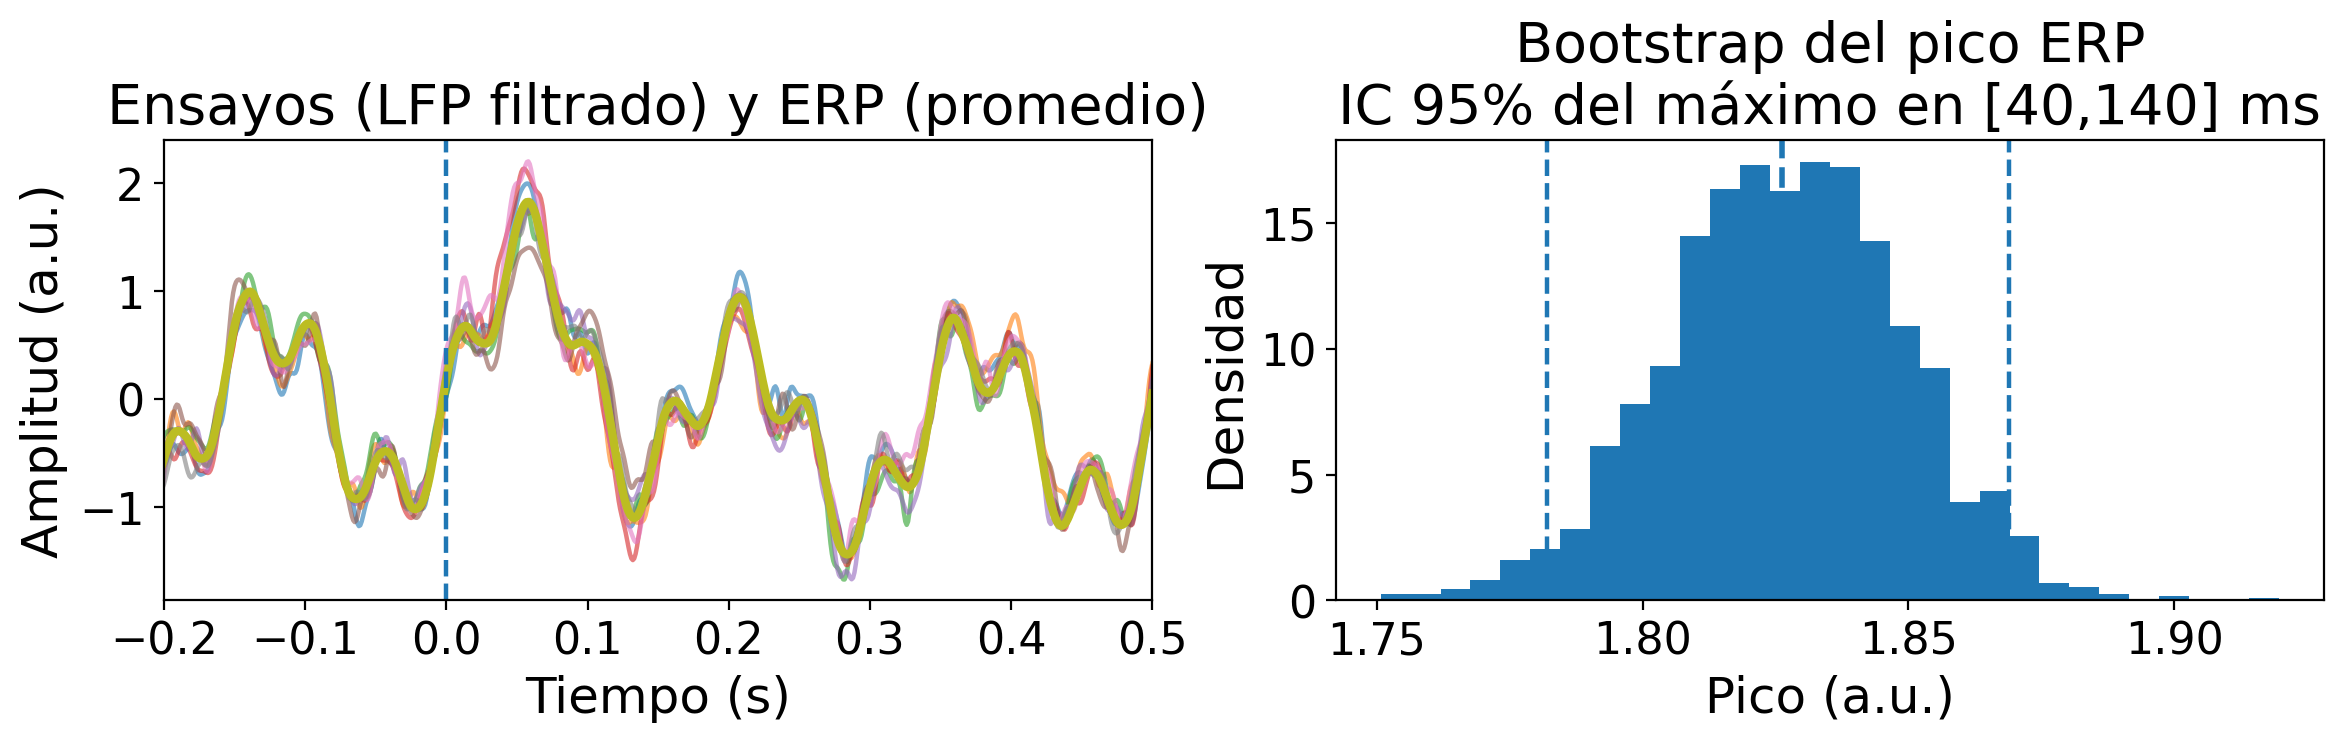

In [56]:
# Ejemplo: LFP, ERP y Bootstrap 
fs = 1000  # Hz
t = np.arange(-0.5, 1.0, 1/fs)  # ventana alrededor del evento (0 s)

n_trials = 80
rng = np.random.default_rng(0)

# 1) LFP
theta = np.sin(2*np.pi*6*t)                        # 6 Hz
beta  = 0.4*np.sin(2*np.pi*20*t + 0.7)             # 20 Hz
erp_kernel = np.exp(-(t-0.08)**2/(2*(0.03**2)))    # pico ~80 ms (gauss)
erp_kernel = erp_kernel - erp_kernel.mean()

# Ruido simple
def colored_noise(n, scale=1.0, rng=None):
    w = rng.standard_normal(n)
    return scale*np.cumsum(w)/np.sqrt(np.arange(1, n+1))

trials = []
for _ in range(n_trials):
    noise = 0.25*colored_noise(len(t), rng=rng) + 0.2*rng.standard_normal(len(t))
    jitter = rng.normal(0, 0.008)  # jitter temporal del componente evocado (8 ms)
    erp_j = np.exp(-(t-(0.08+jitter))**2/(2*(0.03**2)))
    erp_j = erp_j - erp_j.mean()
    x = 0.8*theta + beta + 1.2*erp_j + noise
    trials.append(x)

X = np.vstack(trials)  # tamaño: (trials, time)

# 2) Filtro band-pass típico para LFP 
def bandpass(x, fs, f_lo=1, f_hi=100, order=4):
    nyq = fs/2
    b, a = butter(order, [f_lo/nyq, f_hi/nyq], btype="band")
    return filtfilt(b, a, x)

X_lfp = np.vstack([bandpass(x, fs, 1, 100) for x in X])

# 3) ERP: promedio a través de ensayos 
erp = X_lfp.mean(axis=0)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Mostrar algunos ensayos y el ERP
for k in range(8):
    axs[0].plot(t, X_lfp[k], alpha=0.6)
axs[0].plot(t, erp, linewidth=3)
axs[0].axvline(0, linestyle="--")
axs[0].set_title("Ensayos (LFP filtrado) y ERP (promedio)")
axs[0].set_xlabel("Tiempo (s)")
axs[0].set_ylabel("Amplitud (a.u.)")
axs[0].set_xlim(-0.2, 0.5)

# 4) Bootstrap CI para el pico ERP en una ventana de interés
win = (t >= 0.04) & (t <= 0.14)  # donde esperamos el componente 
peak_obs = erp[win].max()

n_boot = 2000
boot_peaks = np.empty(n_boot)
for b in range(n_boot):
    idx = rng.integers(0, n_trials, n_trials)  # remuestreo con reemplazo
    erp_b = X_lfp[idx].mean(axis=0)
    boot_peaks[b] = erp_b[win].max()

ci_low, ci_high = np.quantile(boot_peaks, [0.025, 0.975])

axs[1].hist(boot_peaks, bins=30, density=True)
axs[1].axvline(peak_obs, linestyle="--", linewidth=2)
axs[1].axvline(ci_low, linestyle="--")
axs[1].axvline(ci_high, linestyle="--")
axs[1].set_title("Bootstrap del pico ERP\nIC 95% del máximo en [40,140] ms")
axs[1].set_xlabel("Pico (a.u.)")
axs[1].set_ylabel("Densidad")

plt.tight_layout()
print(f"Pico observado: {peak_obs:.3f} | IC95% bootstrap: [{ci_low:.3f}, {ci_high:.3f}]")


## Fourier 

En la sección 4 del texto trabajamos esta herramienta. Primero vamos a graficar 2 interpretaciónes de esta

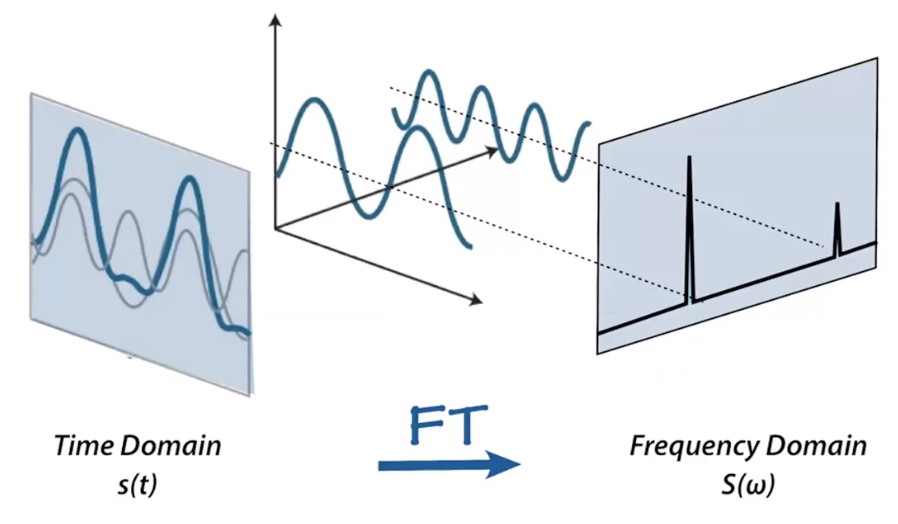








In [21]:
def fft_spectrum(x, fs):
    n = len(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(X) / n
    pow_ = mag**2
    return f, mag, pow_

def style_axes(ax, title, xlabel, ylabel):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

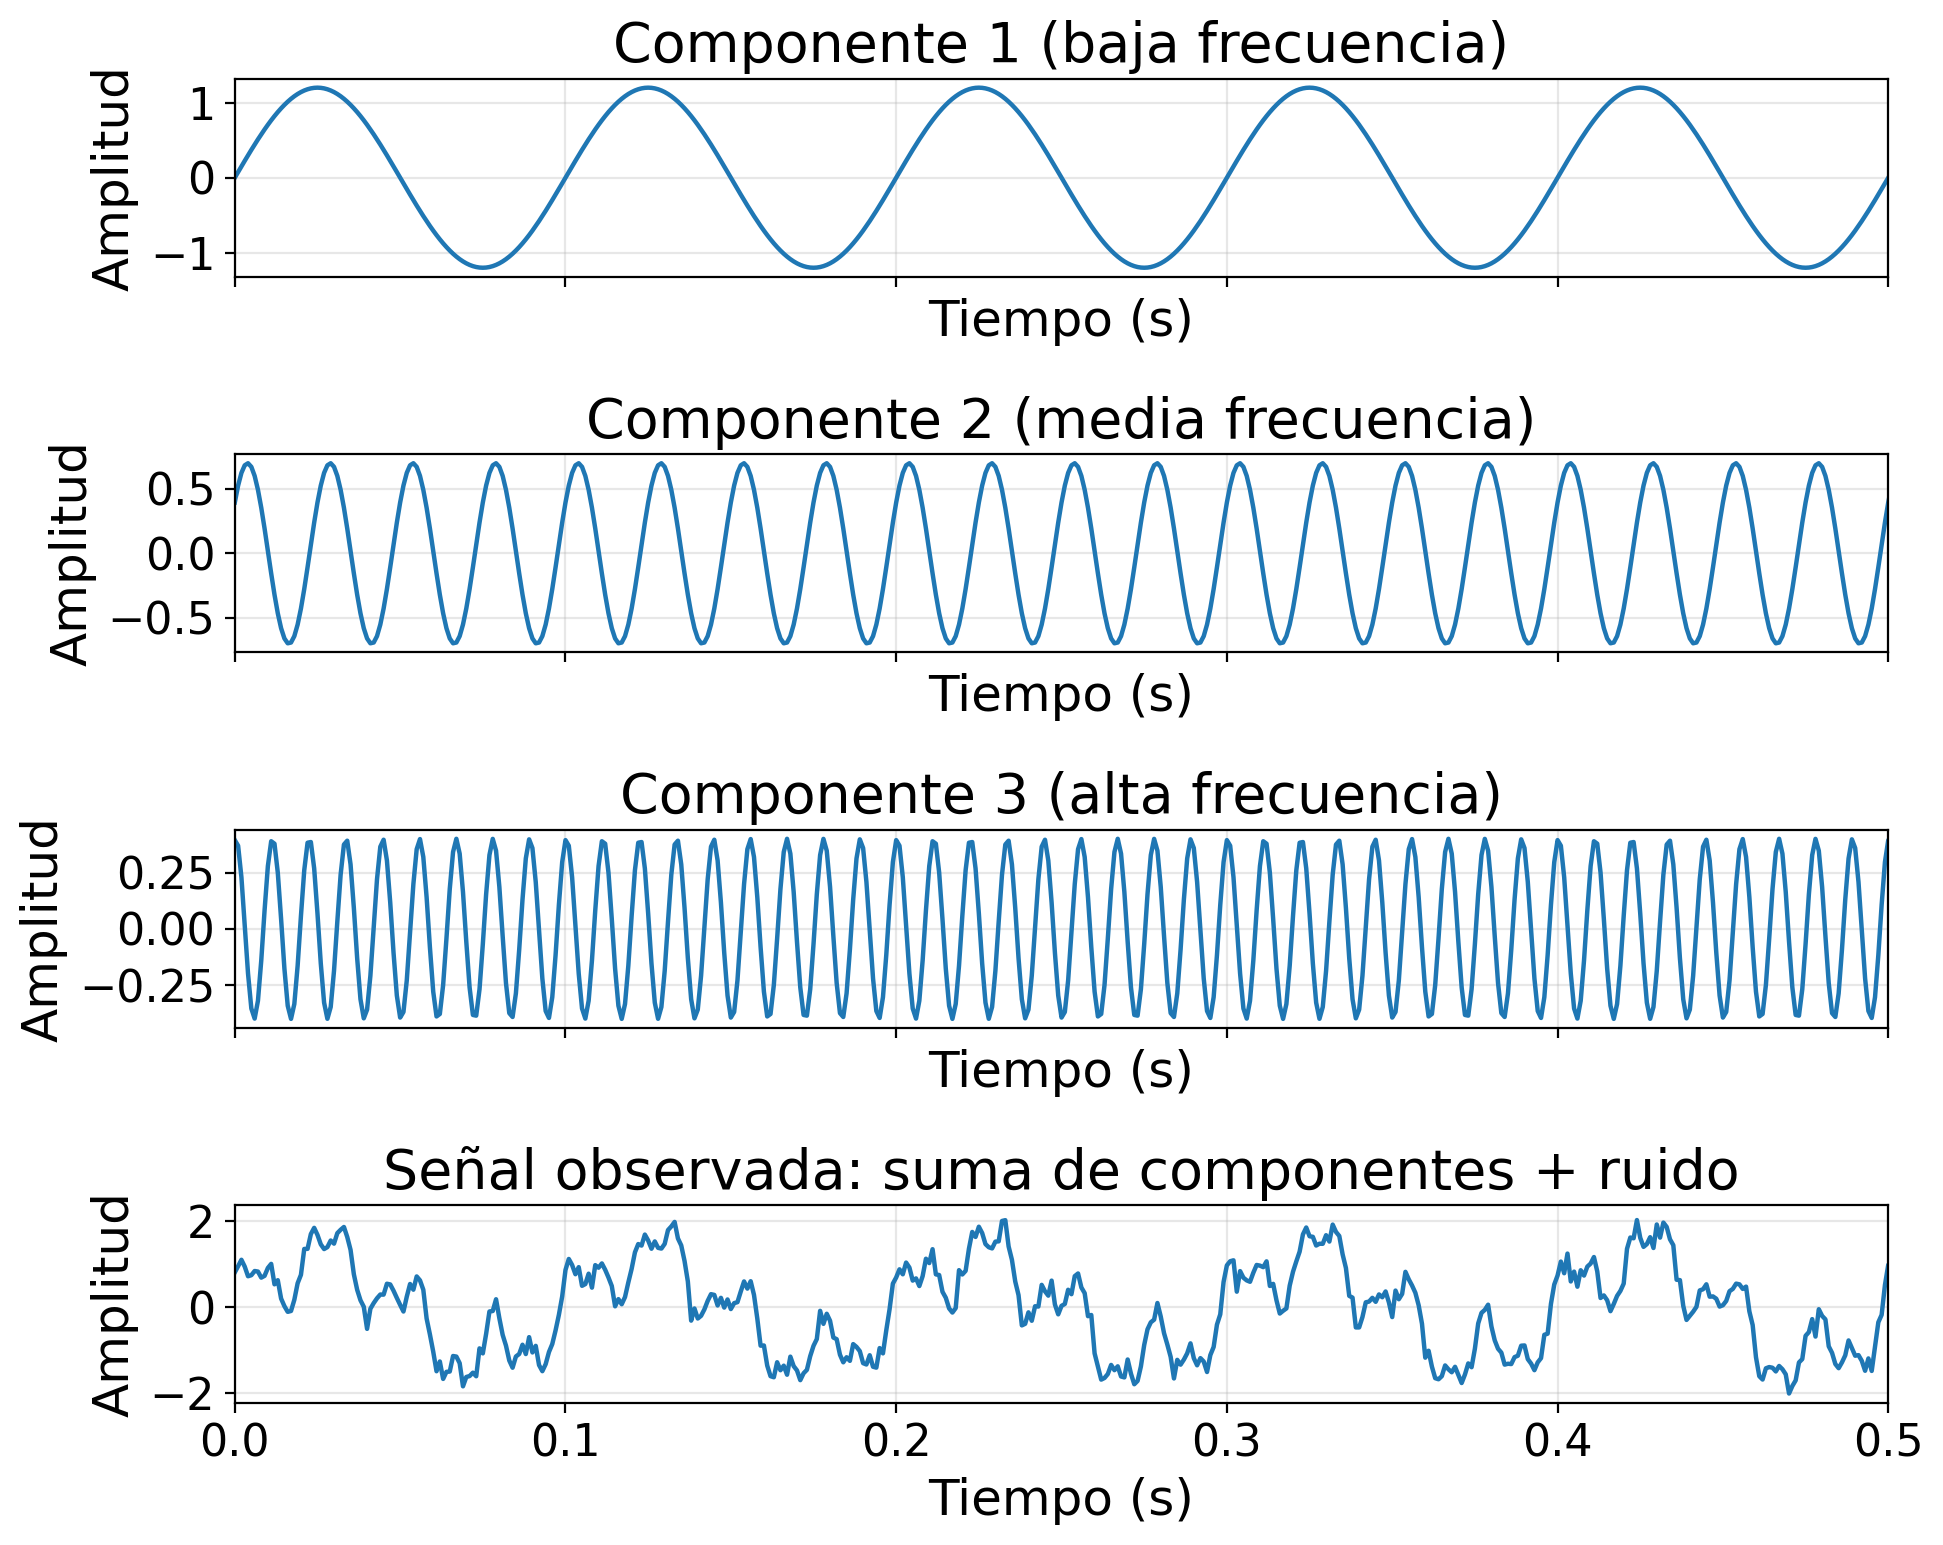

In [22]:
# Parámetros
fs = 1000  # Hz
T = 1.0    # s
t = np.arange(0, T, 1/fs)

# Componentes sinusoidales
f1, f2, f3 = 10, 40, 90
x1 = 1.2*np.sin(2*np.pi*f1*t)
x2 = 0.7*np.sin(2*np.pi*f2*t + 0.6)
x3 = 0.4*np.sin(2*np.pi*f3*t + 1.4)

# Señal compuesta + ruido 
rng = np.random.default_rng(0)
noise = 0.15 * rng.standard_normal(len(t))
x = x1 + x2 + x3 + noise

# Gráfica
fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
axs[0].plot(t, x1); style_axes(axs[0], "Componente 1 (baja frecuencia)", "Tiempo (s)", "Amplitud")
axs[1].plot(t, x2); style_axes(axs[1], "Componente 2 (media frecuencia)", "Tiempo (s)", "Amplitud")
axs[2].plot(t, x3); style_axes(axs[2], "Componente 3 (alta frecuencia)", "Tiempo (s)", "Amplitud")
axs[3].plot(t, x);  style_axes(axs[3], "Señal observada: suma de componentes + ruido", "Tiempo (s)", "Amplitud")

axs[-1].set_xlim(0, 0.5)  
plt.tight_layout()
plt.show()

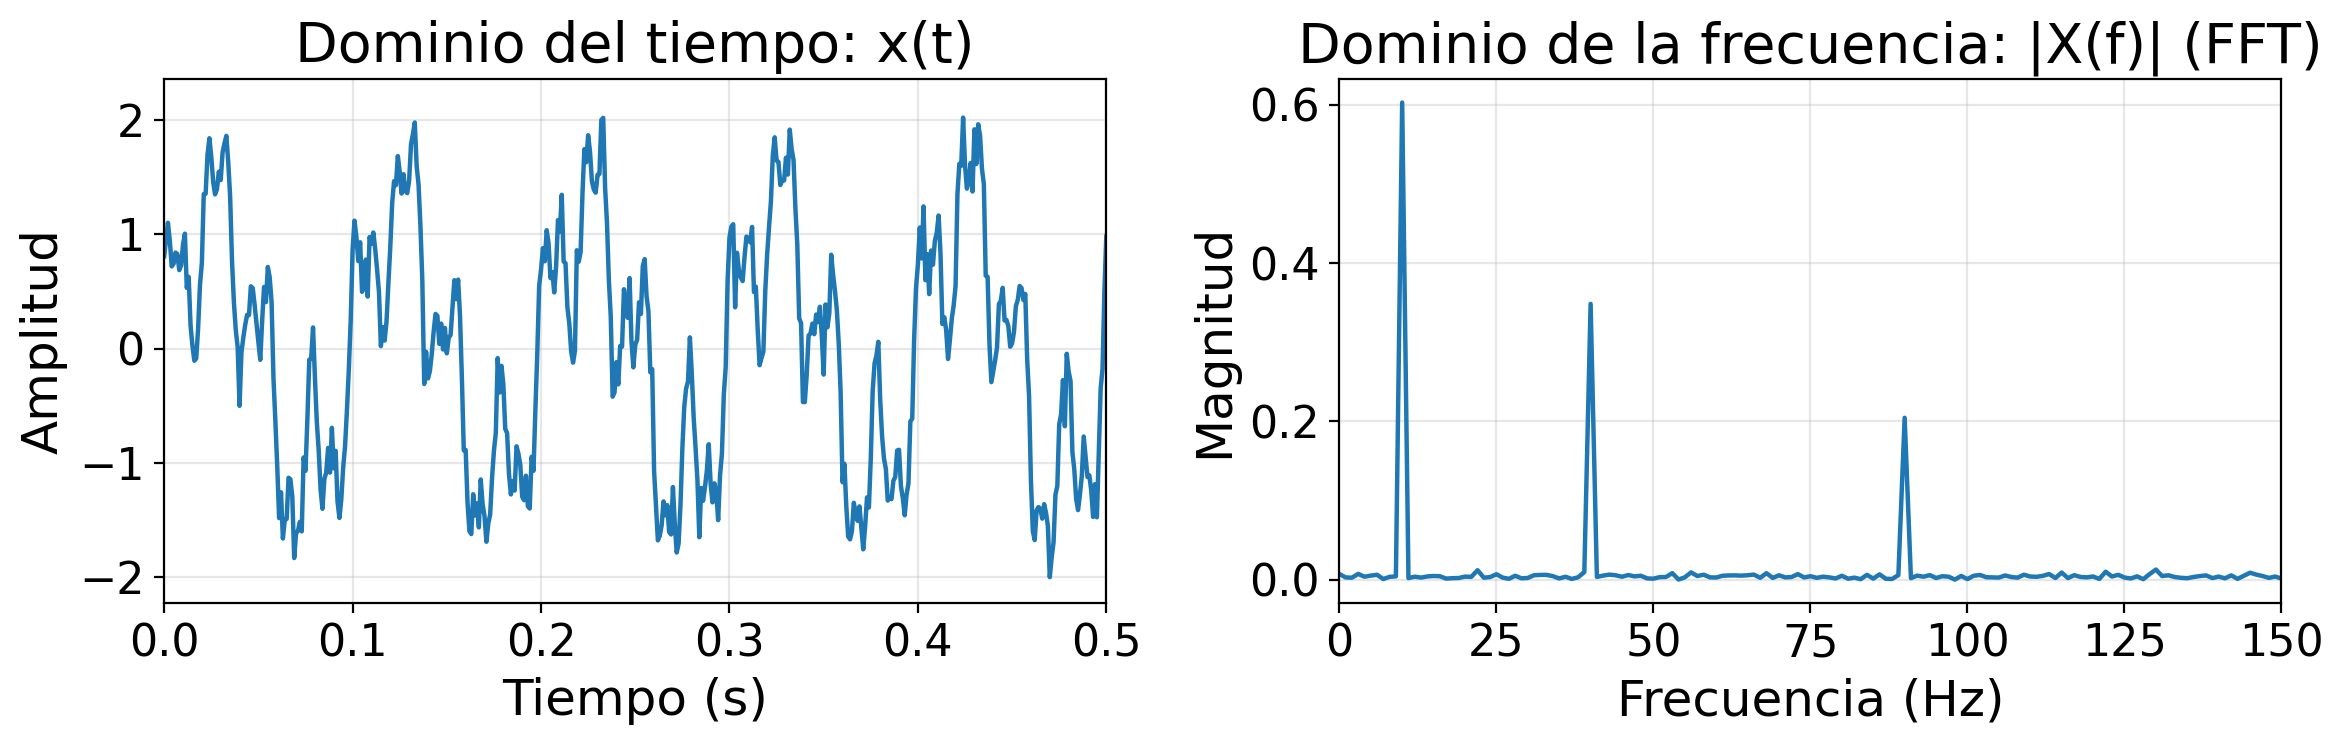

In [23]:
f, mag, pow_ = fft_spectrum(x, fs)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(t, x)
style_axes(axs[0], "Dominio del tiempo: x(t)", "Tiempo (s)", "Amplitud")
axs[0].set_xlim(0, 0.5)

axs[1].plot(f, mag)
style_axes(axs[1], "Dominio de la frecuencia: |X(f)| (FFT)", "Frecuencia (Hz)", "Magnitud")
axs[1].set_xlim(0, 150)

plt.tight_layout()
plt.show()

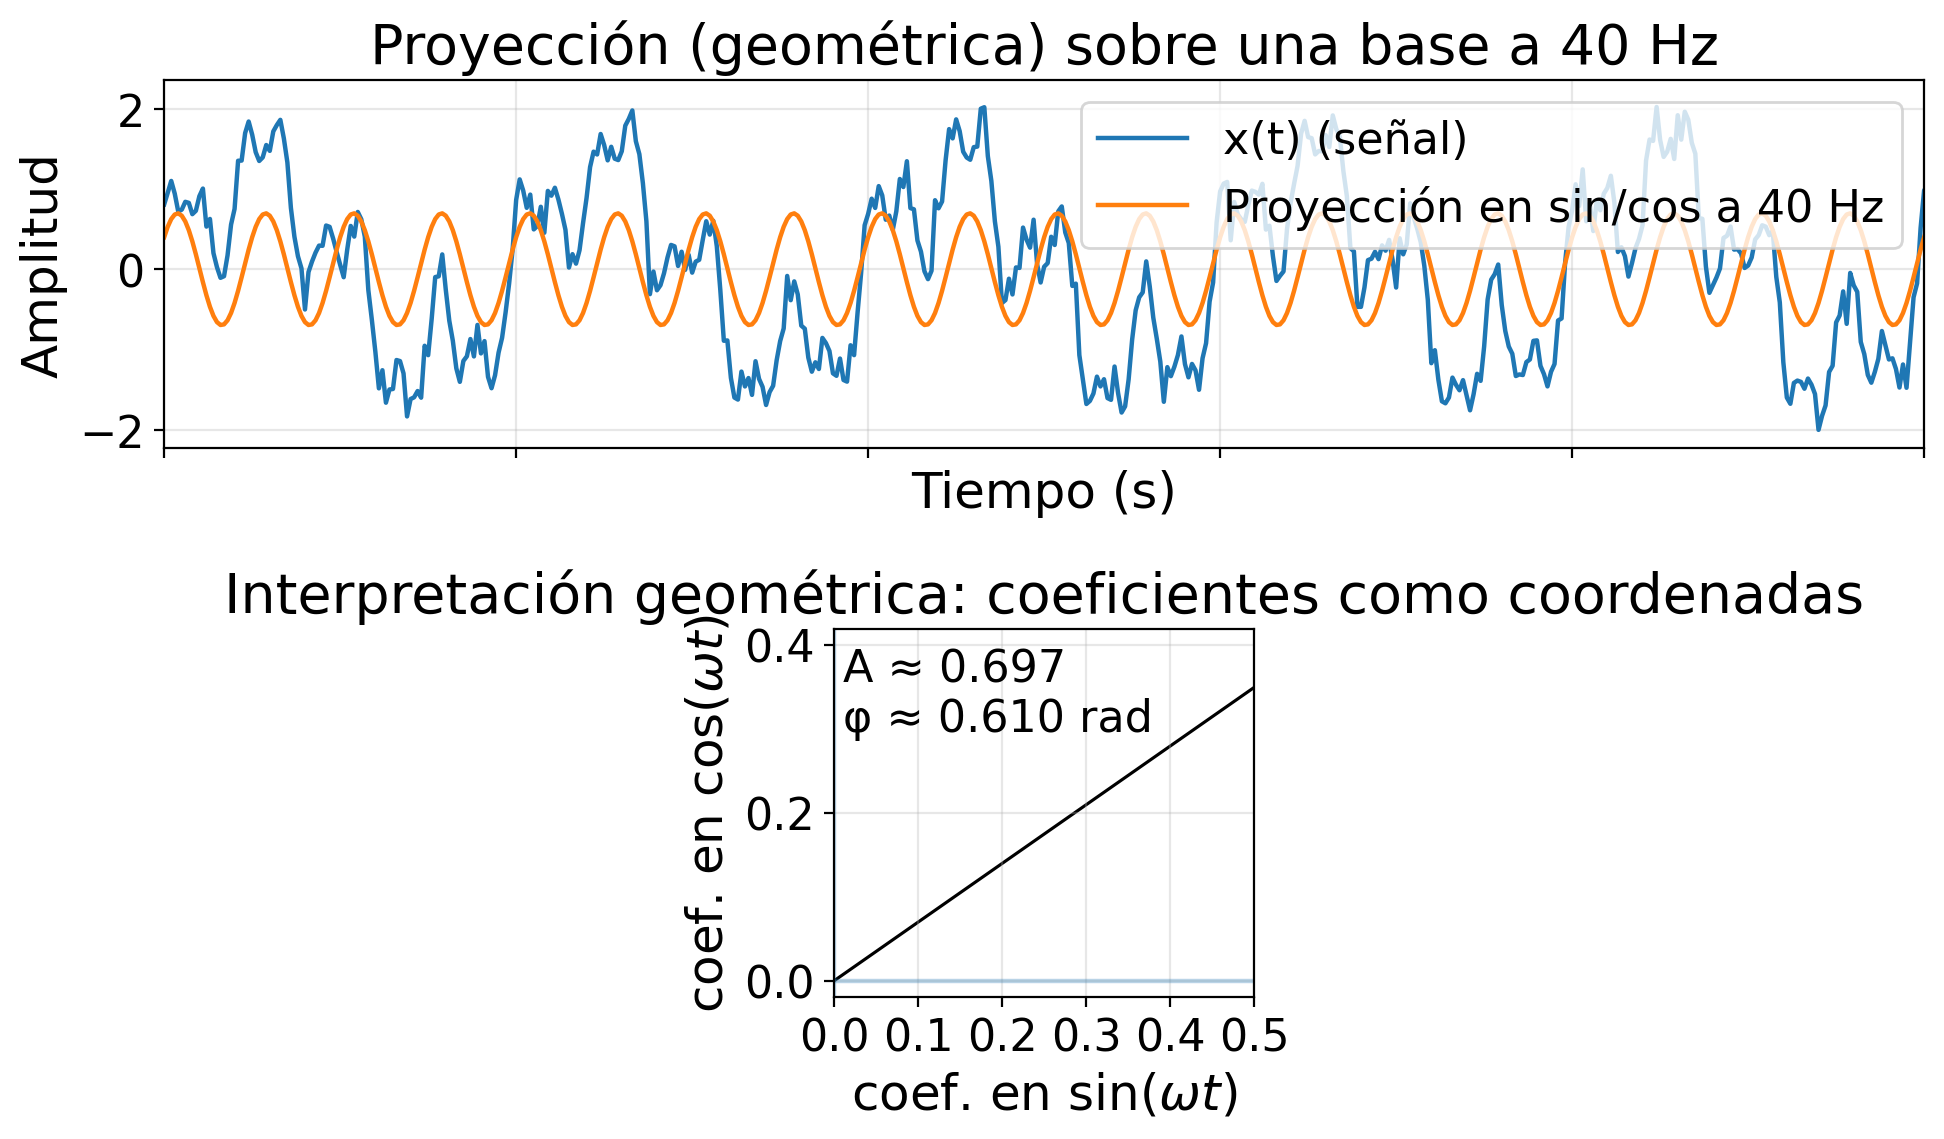

In [24]:
# Frecuencia elegida por interés 
f0 = 40  # Hz
w0 = 2*np.pi*f0

# Bases ortogonales (aprox) en la ventana de observación
sin0 = np.sin(w0*t)
cos0 = np.cos(w0*t)

# Coeficientes de proyección 

# Escalamos con 2/N para aproximar amplitudes
N = len(t)
a_sin = (2/N) * np.dot(x, sin0)
a_cos = (2/N) * np.dot(x, cos0)

A = np.sqrt(a_sin**2 + a_cos**2)            # amplitud equivalente
phi = np.arctan2(a_cos, a_sin)              # fase 

# Reconstrucción SOLO de la componente a f0 usando esos coeficientes
x_proj = a_sin*sin0 + a_cos*cos0

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(t, x, label="x(t) (señal)")
axs[0].plot(t, x_proj, label=f"Proyección en sin/cos a {f0} Hz")
style_axes(axs[0], f"Proyección (geométrica) sobre una base a {f0} Hz", "Tiempo (s)", "Amplitud")
axs[0].set_xlim(0, 0.5)
axs[0].legend()

# Diagrama “geométrico” simple: vector de coeficientes (a_sin, a_cos)
axs[1].quiver(0, 0, a_sin, a_cos, angles='xy', scale_units='xy', scale=1)
axs[1].scatter([a_sin], [a_cos])
axs[1].axhline(0, alpha=0.3); axs[1].axvline(0, alpha=0.3)
axs[1].set_aspect('equal', adjustable='box')
style_axes(axs[1], "Interpretación geométrica: coeficientes como coordenadas", r"coef. en $\sin(\omega t)$", r"coef. en $\cos(\omega t)$")

# Un poco de texto en la gráfica
axs[1].text(0.02, 0.95,
            f"A ≈ {A:.3f}\nφ ≈ {phi:.3f} rad",
            transform=axs[1].transAxes, va='top')

plt.tight_layout()
plt.show()

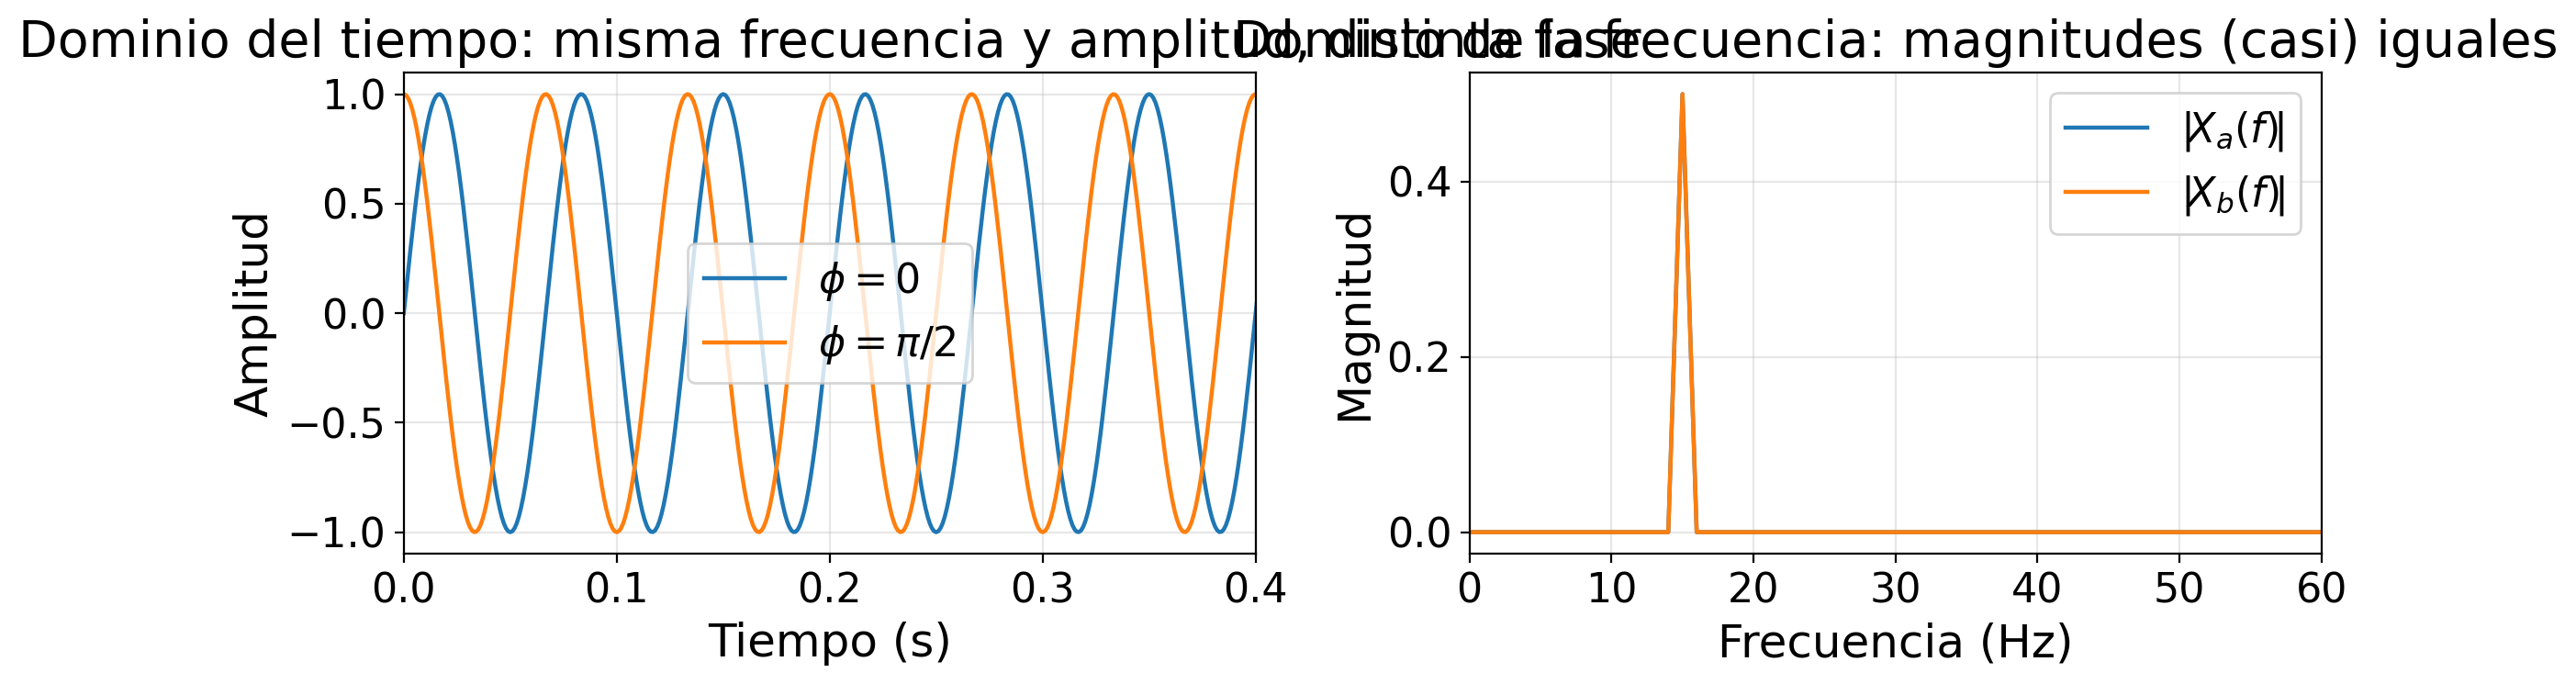

In [25]:
fs = 1000
T = 1.0
t = np.arange(0, T, 1/fs)

f0 = 15
A0 = 1.0
phi1 = 0.0
phi2 = np.pi/2  # desfase de 90°

x_a = A0*np.sin(2*np.pi*f0*t + phi1)
x_b = A0*np.sin(2*np.pi*f0*t + phi2)

fa, maga, _ = fft_spectrum(x_a, fs)
fb, magb, _ = fft_spectrum(x_b, fs)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(t, x_a, label=r"$\phi=0$")
axs[0].plot(t, x_b, label=r"$\phi=\pi/2$")
style_axes(axs[0], "Dominio del tiempo: misma frecuencia y amplitud, distinta fase", "Tiempo (s)", "Amplitud")
axs[0].set_xlim(0, 0.4)
axs[0].legend()

axs[1].plot(fa, maga, label=r"$|\!X_a(f)\!|$")
axs[1].plot(fb, magb, label=r"$|\!X_b(f)\!|$")
style_axes(axs[1], "Dominio de la frecuencia: magnitudes (casi) iguales", "Frecuencia (Hz)", "Magnitud")
axs[1].set_xlim(0, 60)
axs[1].legend()

plt.tight_layout()
plt.show()

### Fourier: continuo, discreto, FFT, STFT y transformada de Hilbert

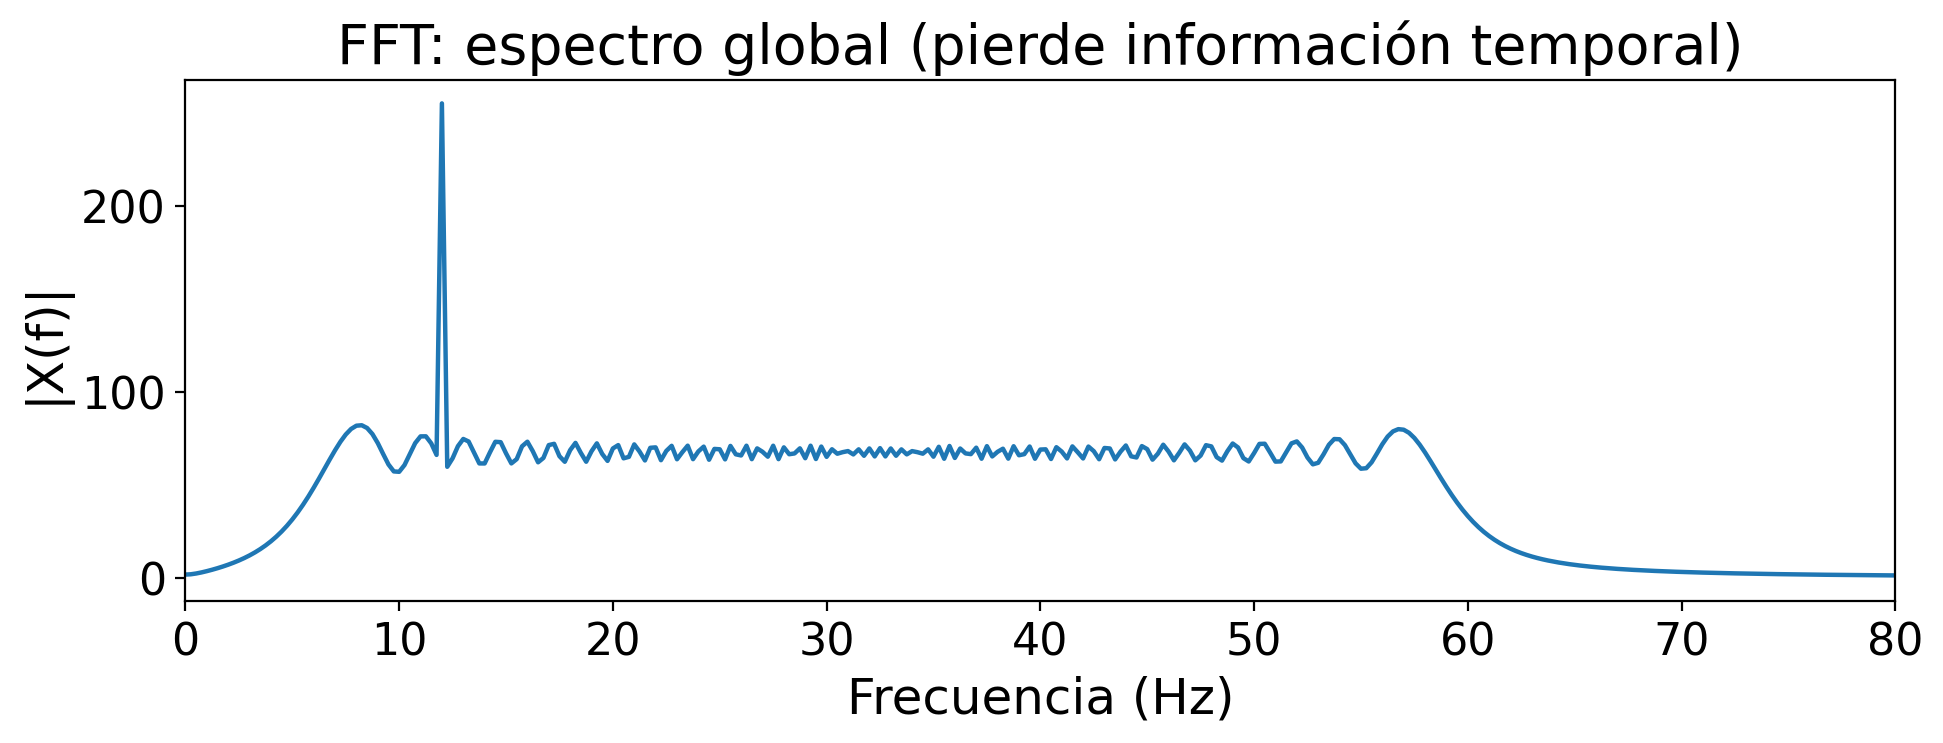

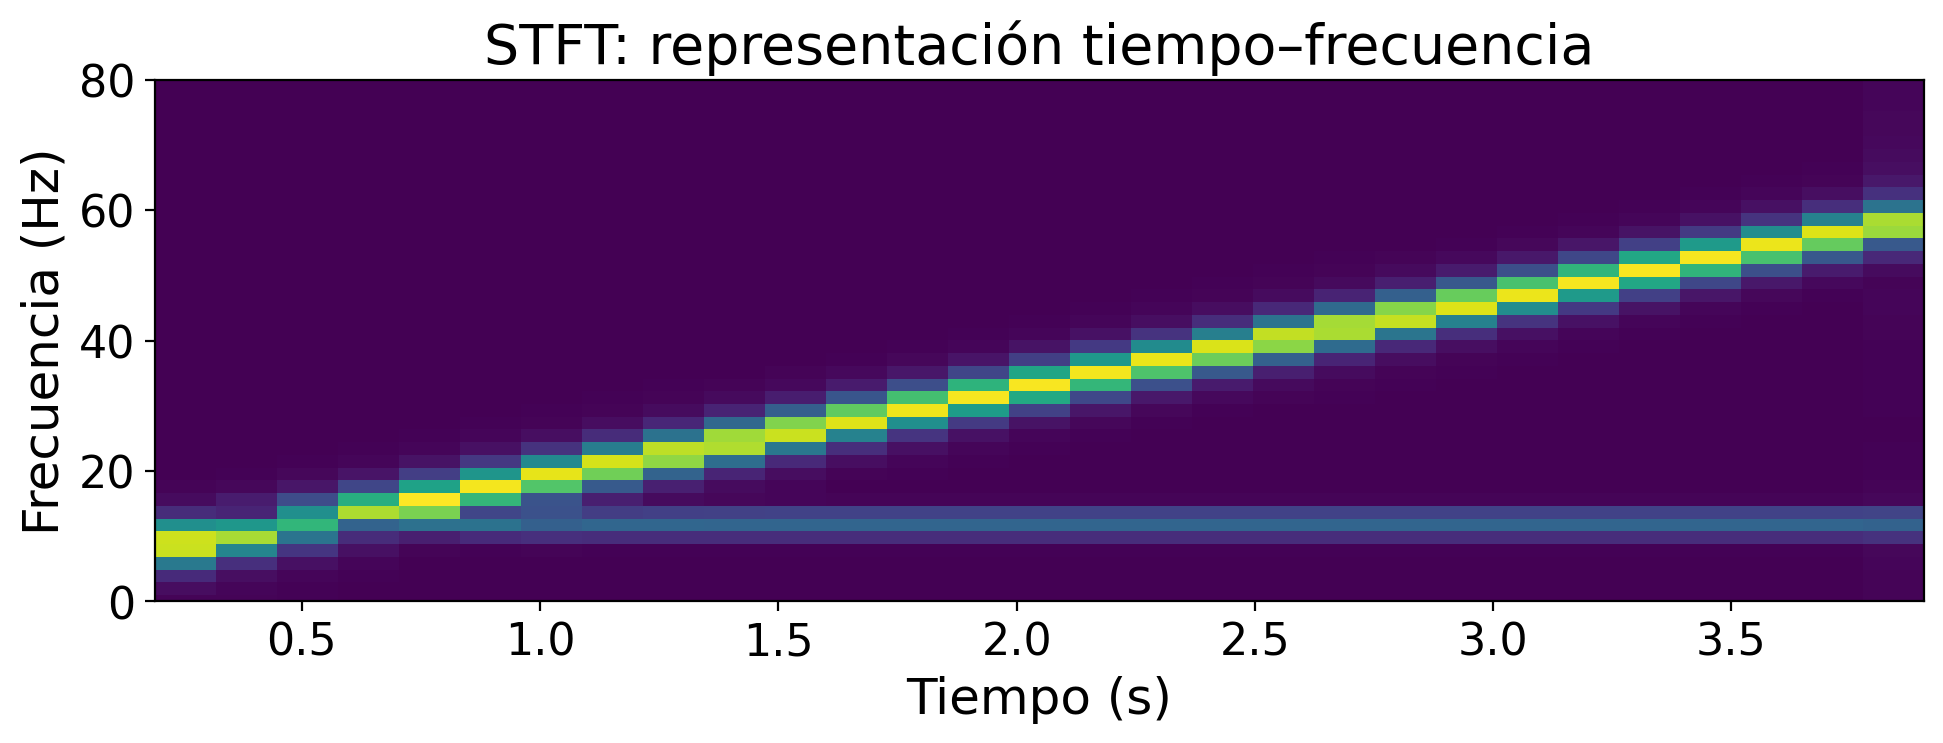

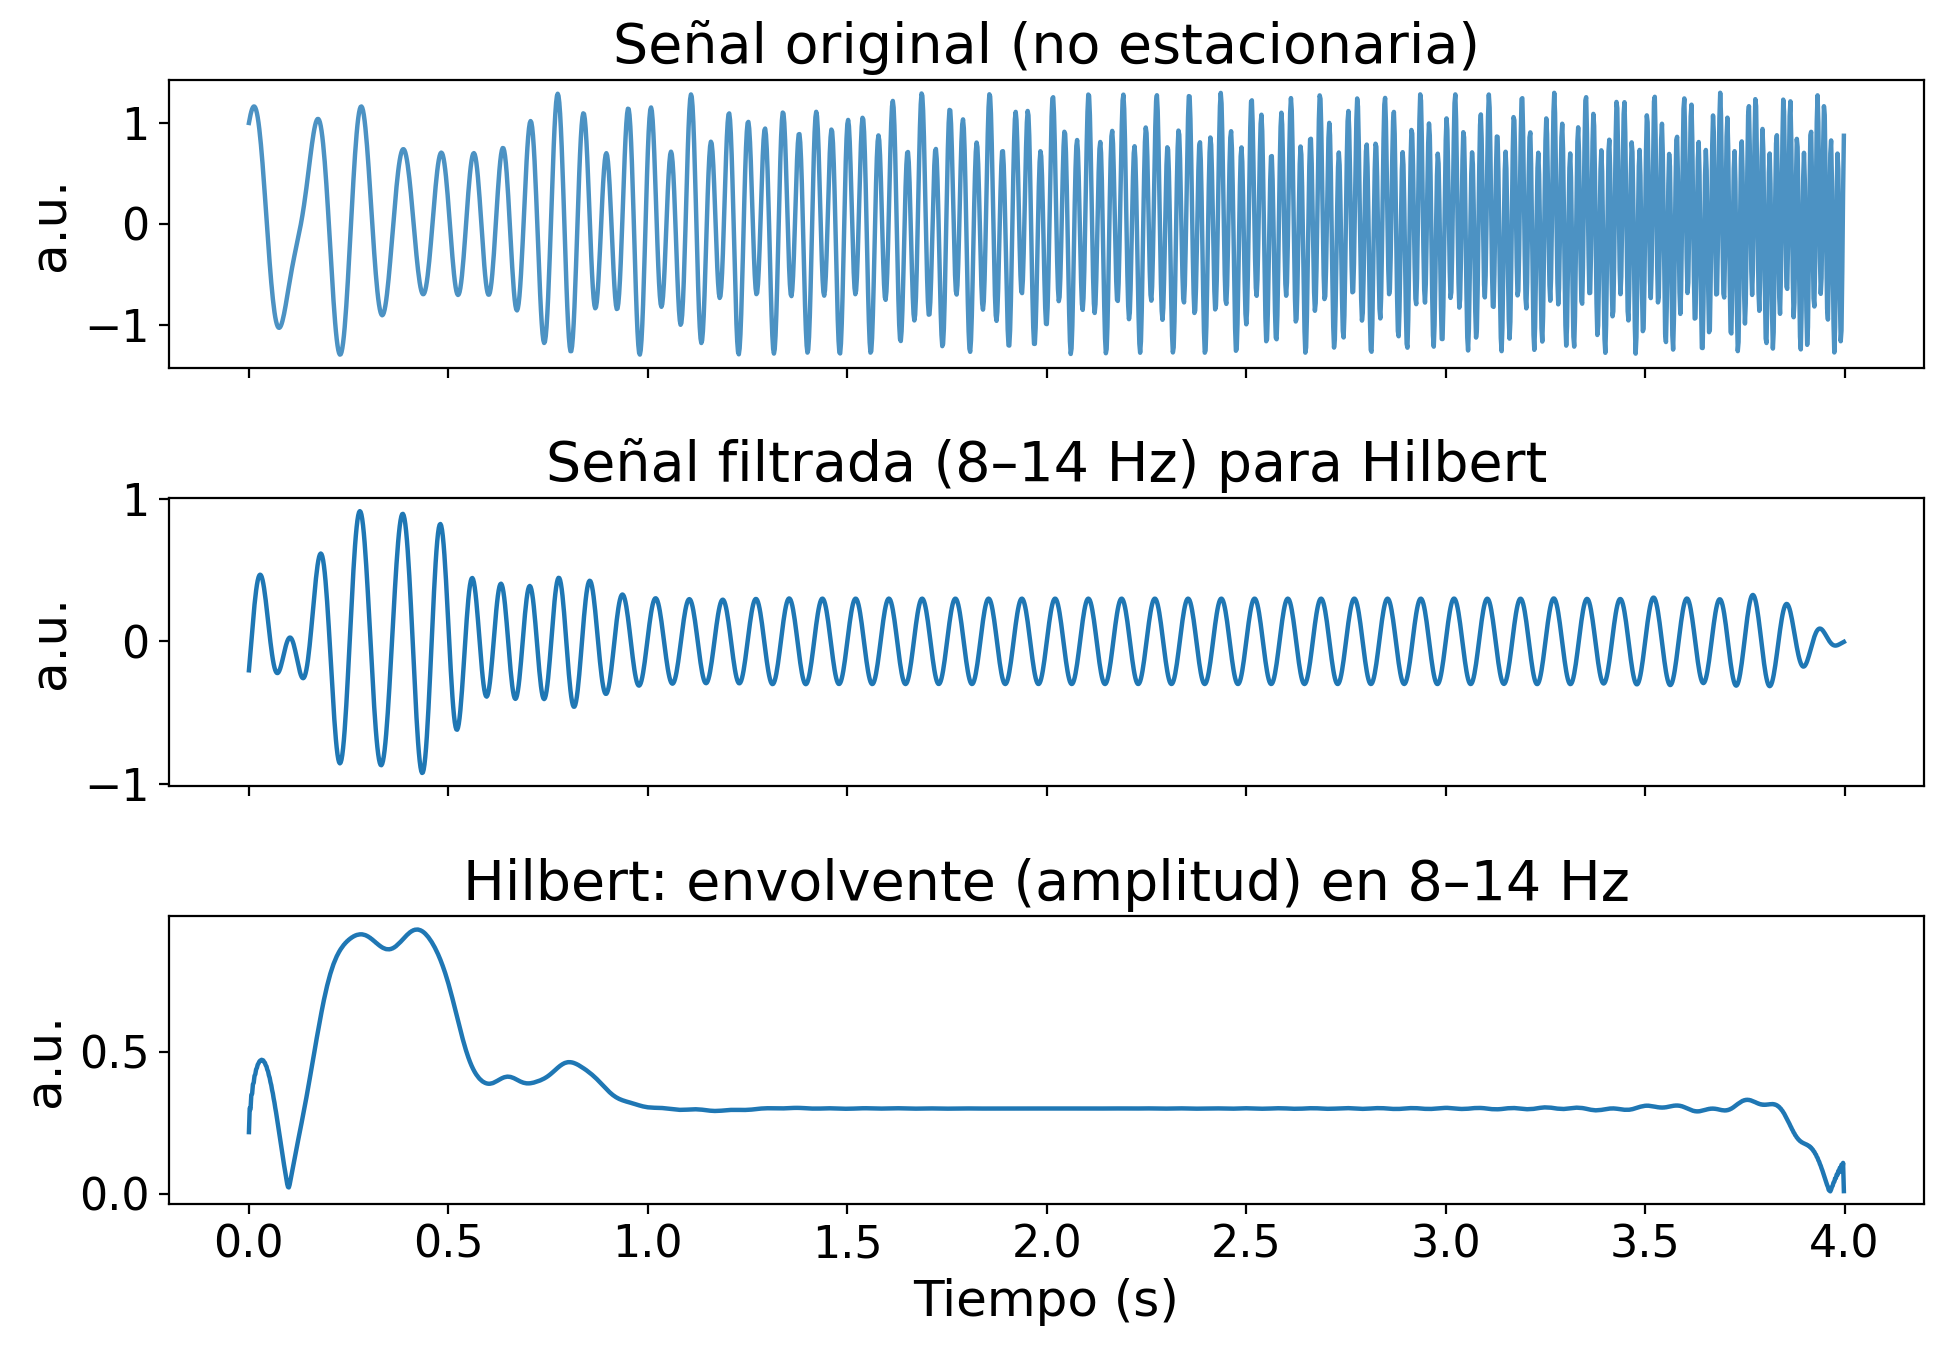

In [26]:
# Comparación: DFT/FFT , STFT + Hilbert 
fs = 500
t = np.arange(0, 4.0, 1/fs)

# Señal no estacionaria: cambia su frecuencia con el tiempo
x = chirp(t, f0=5, f1=60, t1=t[-1], method="linear") + 0.3*np.sin(2*np.pi*12*t)

# 1) FFT 
f = np.fft.rfftfreq(len(t), d=1/fs)
X = np.abs(np.fft.rfft(x))

plt.figure(figsize=(10,4))
plt.plot(f, X)
plt.title("FFT: espectro global (pierde información temporal)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("|X(f)|")
plt.xlim(0, 80)
plt.tight_layout()

# 2) STFT
f_stft, t_stft, Zxx = stft(x, fs=fs, window="hann", nperseg=256, noverlap=192, boundary=None)
S = np.abs(Zxx)

plt.figure(figsize=(10,4))
plt.pcolormesh(t_stft, f_stft, S, shading="auto")
plt.title("STFT: representación tiempo–frecuencia")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.ylim(0, 80)
plt.tight_layout()

# 3) Hilbert
# Band-pass para centrarnos en una banda
x_alpha = bandpass(x, fs, 8, 14)
xa = hilbert(x_alpha)
amp = np.abs(xa)
phase = np.unwrap(np.angle(xa))

fig, axs = plt.subplots(3, 1, figsize=(10,7), sharex=True)
axs[0].plot(t, x, alpha=0.8)
axs[0].set_title("Señal original (no estacionaria)")
axs[0].set_ylabel("a.u.")
axs[1].plot(t, x_alpha)
axs[1].set_title("Señal filtrada (8–14 Hz) para Hilbert")
axs[1].set_ylabel("a.u.")
axs[2].plot(t, amp, label="Amplitud instantánea")
axs[2].set_title("Hilbert: envolvente (amplitud) en 8–14 Hz")
axs[2].set_xlabel("Tiempo (s)")
axs[2].set_ylabel("a.u.")
plt.tight_layout()


---

## Mitigación de Errores en análisis de oscilaciones

En el texto seccion 4.8 se ve las implicaciones de la fuga espectral y como soluciónarlo. Aquí mostraremos un código simple que resalta la fuga y dejaremos ejercicios al final de la seccion.

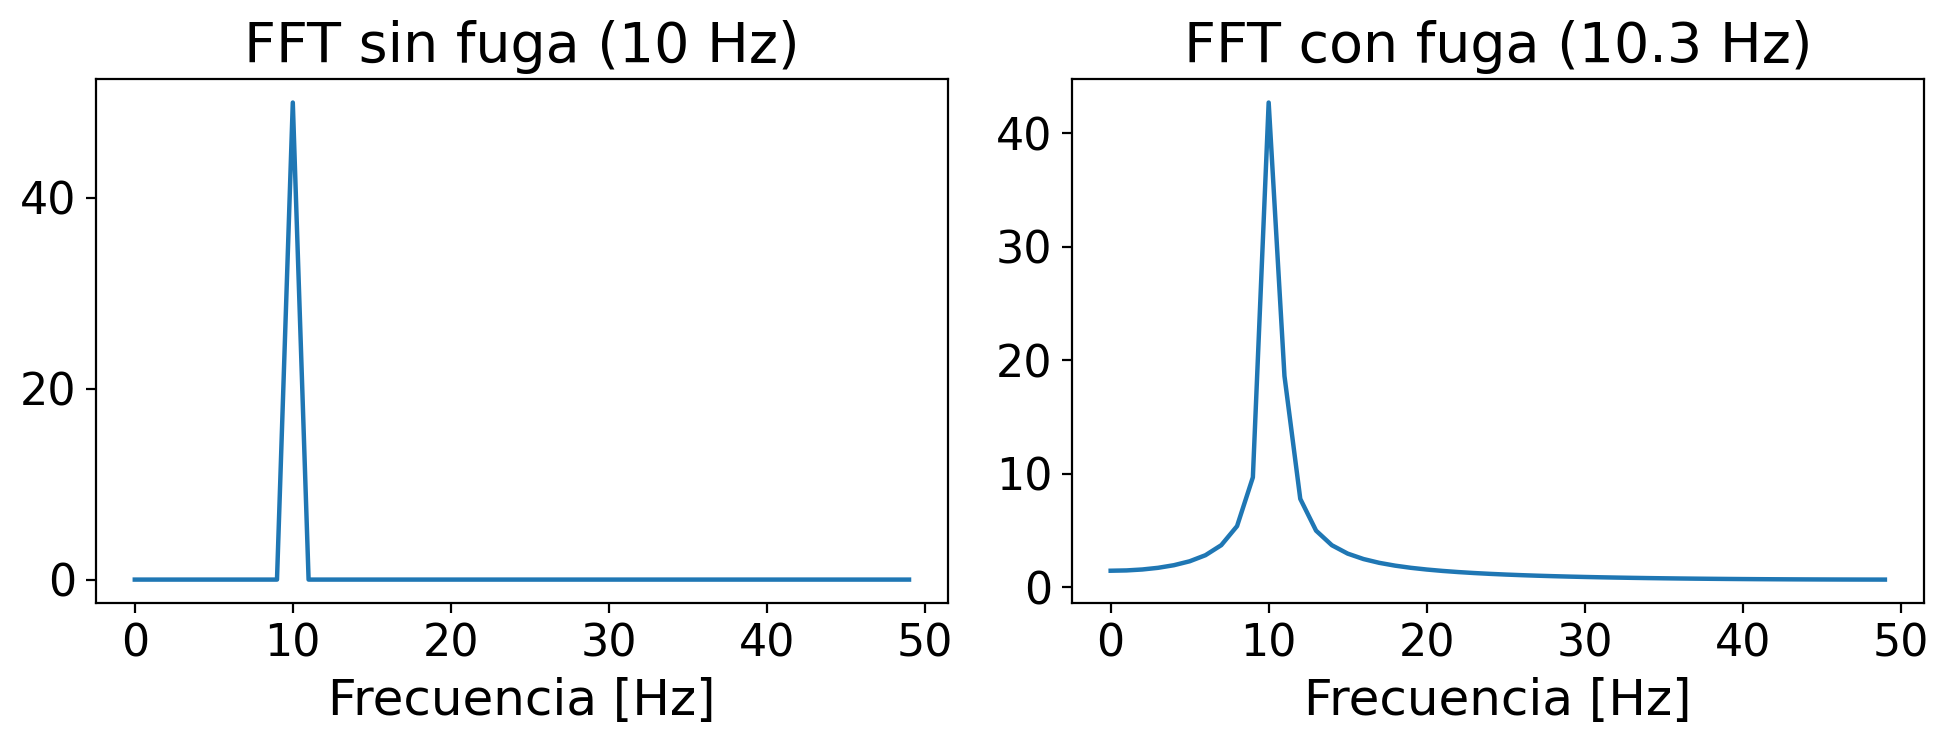

In [29]:
# Ejemplo: Fuga espectral 
fs = 100
t = np.arange(0, 1, 1/fs)

signal_clean = np.sin(2*np.pi*10*t)     # 10 Hz  (bins de tamaño 10)
signal_leak  = np.sin(2*np.pi*10.3*t)   # 10.3 Hz 

fft_clean = np.abs(np.fft.fft(signal_clean))
fft_leak = np.abs(np.fft.fft(signal_leak))
freqs = np.fft.fftfreq(len(t), 1/fs)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(freqs[:len(freqs)//2], fft_clean[:len(freqs)//2])
plt.title("FFT sin fuga (10 Hz)") #Toda la energía de centra en el bin
plt.xlabel("Frecuencia [Hz]")# La energía se dispersa

plt.subplot(1,2,2)
plt.plot(freqs[:len(freqs)//2], fft_leak[:len(freqs)//2])
plt.title("FFT con fuga (10.3 Hz)")
plt.xlabel("Frecuencia [Hz]")
plt.tight_layout()
plt.show()

Ahora veremos algunos métodos para reducción

### Ventanas

> **Ejemplos**

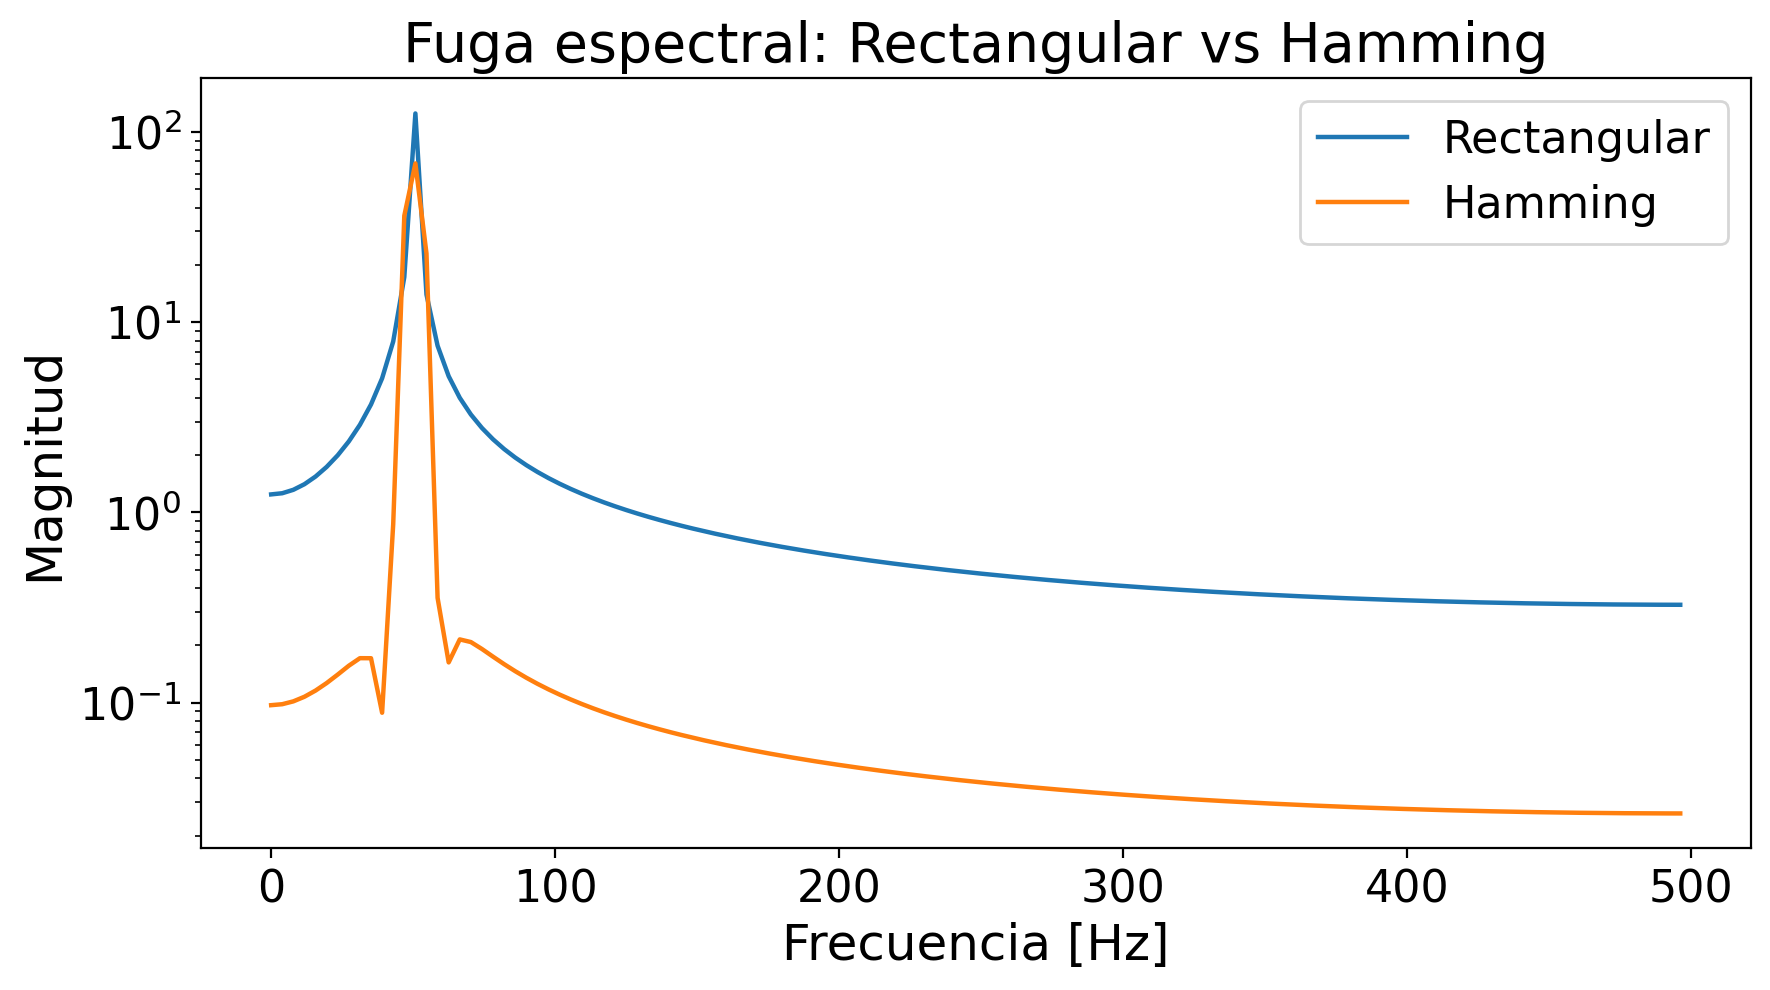

In [31]:
# Parámetros
fs = 1000   # frecuencia de muestreo
N = 256     # número de muestras

t = np.arange(N) / fs

# Señal: seno de 50.3 Hz 
x = np.sin(2 * np.pi * 50.3 * t)

# Ventanas
rect = np.ones(N) # rectangular
hamming = get_window("hamming", N)

# Aplicar ventanas
x_rect = x * rect
x_hamming = x * hamming

# Espectros
X_rect = np.abs(np.fft.fft(x_rect))[:N//2]
X_hamming = np.abs(np.fft.fft(x_hamming))[:N//2]
freqs = np.fft.fftfreq(N, 1/fs)[:N//2]

plt.figure(figsize=(10,5))
plt.semilogy(freqs, X_rect, label="Rectangular")
plt.semilogy(freqs, X_hamming, label="Hamming")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Fuga espectral: Rectangular vs Hamming")
plt.legend()
plt.show()


### Tapers

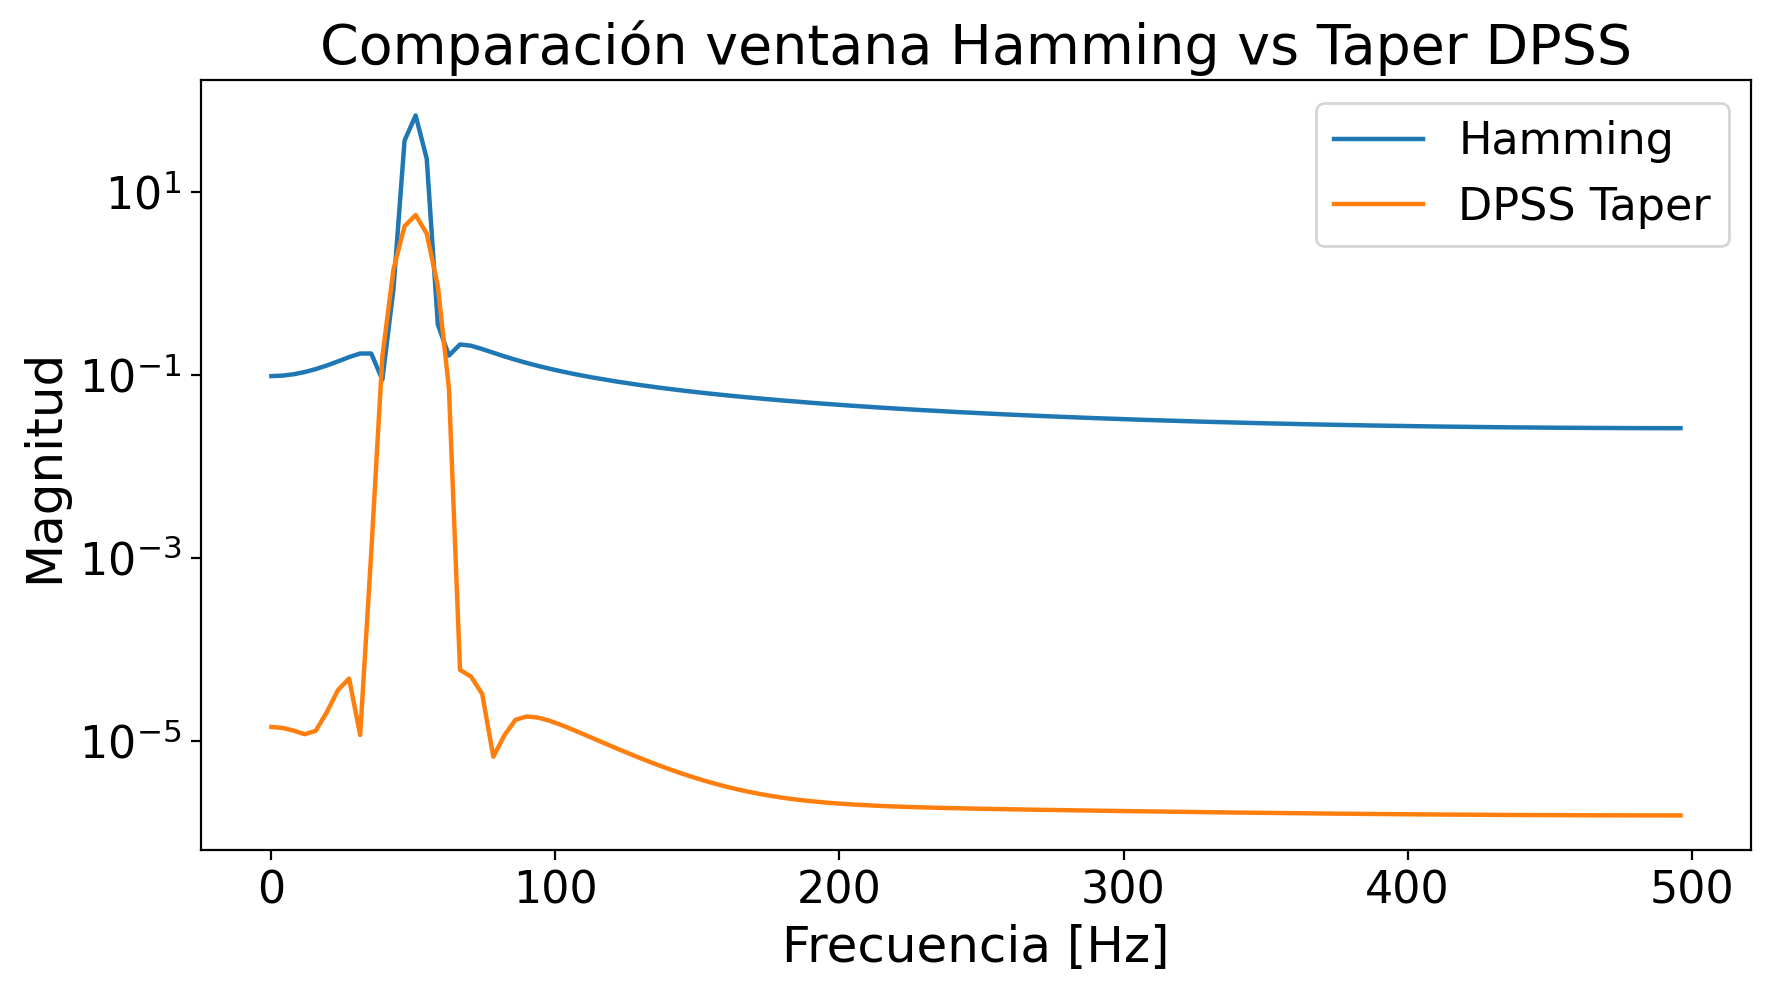

In [32]:
# DPSS
NW = 4  # ancho de banda normalizado
taper = dpss(N, NW, Kmax=1)[0]  # primer taper

# Señal con taper
x_taper = x * taper
X_taper = np.abs(np.fft.fft(x_taper))[:N//2]

plt.figure(figsize=(10,5))
plt.semilogy(freqs, X_hamming, label="Hamming")
plt.semilogy(freqs, X_taper, label="DPSS Taper")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación ventana Hamming vs Taper DPSS")
plt.legend()
plt.show()


> **Nota:** Este bloque como el anterior es para ver la diferencia entre una ventana común y el DPSS (el cual se explica en el apendice del texto)

### Multitapers (Thomson)

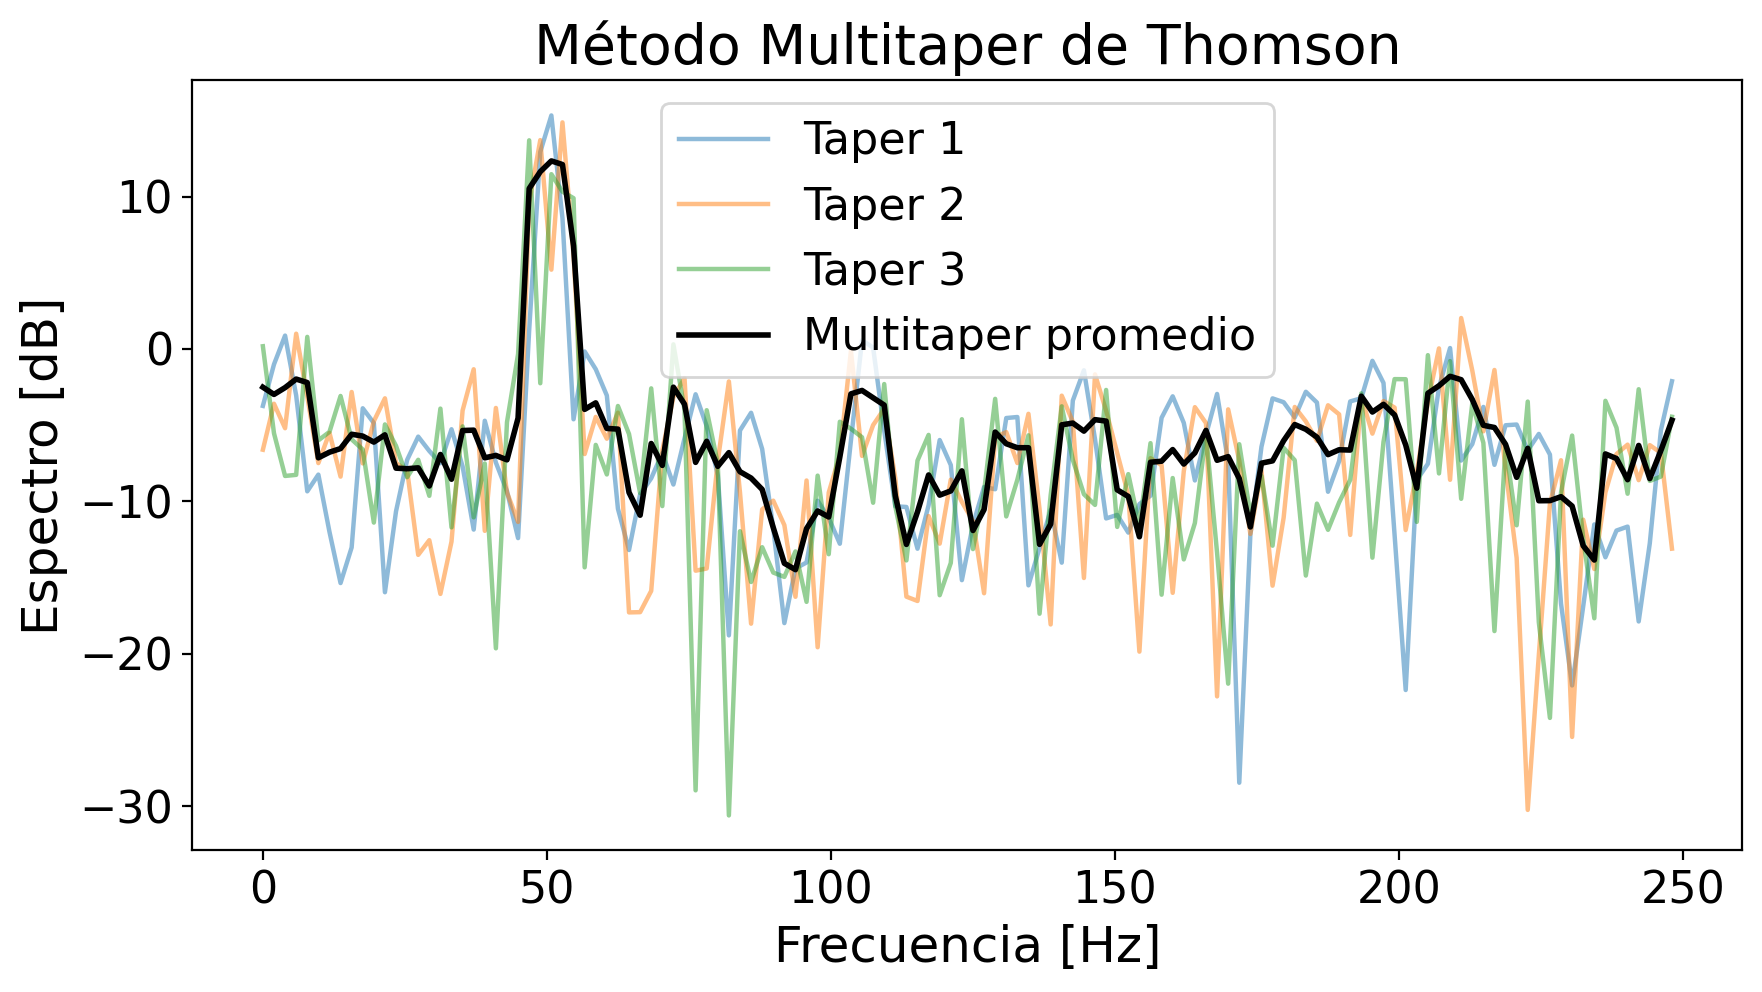

In [33]:
# Parámetros
fs = 500
N = 256
t = np.arange(N)/fs
x = np.sin(2*np.pi*50.3*t) + 0.5*np.random.randn(N)  # señal con ruido

# Generar 3 DPSS tapers
NW = 3
K = 3
tapers = dpss(N, NW, Kmax=K)

# Calcular espectros para cada taper
freqs = np.fft.fftfreq(N, 1/fs)[:N//2]
spectra = []
for k in range(K):
    x_taper = x * tapers[k]
    Xk = np.fft.fft(x_taper)[:N//2]
    spectra.append(np.abs(Xk)**2)

# Promediar
S_mt = np.mean(spectra, axis=0)

# Graficar
plt.figure(figsize=(10,5))
for k, Sk in enumerate(spectra):
    plt.plot(freqs, 10*np.log10(Sk), alpha=0.5, label=f"Taper {k+1}")
plt.plot(freqs, 10*np.log10(S_mt), 'k', linewidth=2, label="Multitaper promedio")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Espectro [dB]")
plt.title("Método Multitaper de Thomson")
plt.legend()
plt.show()


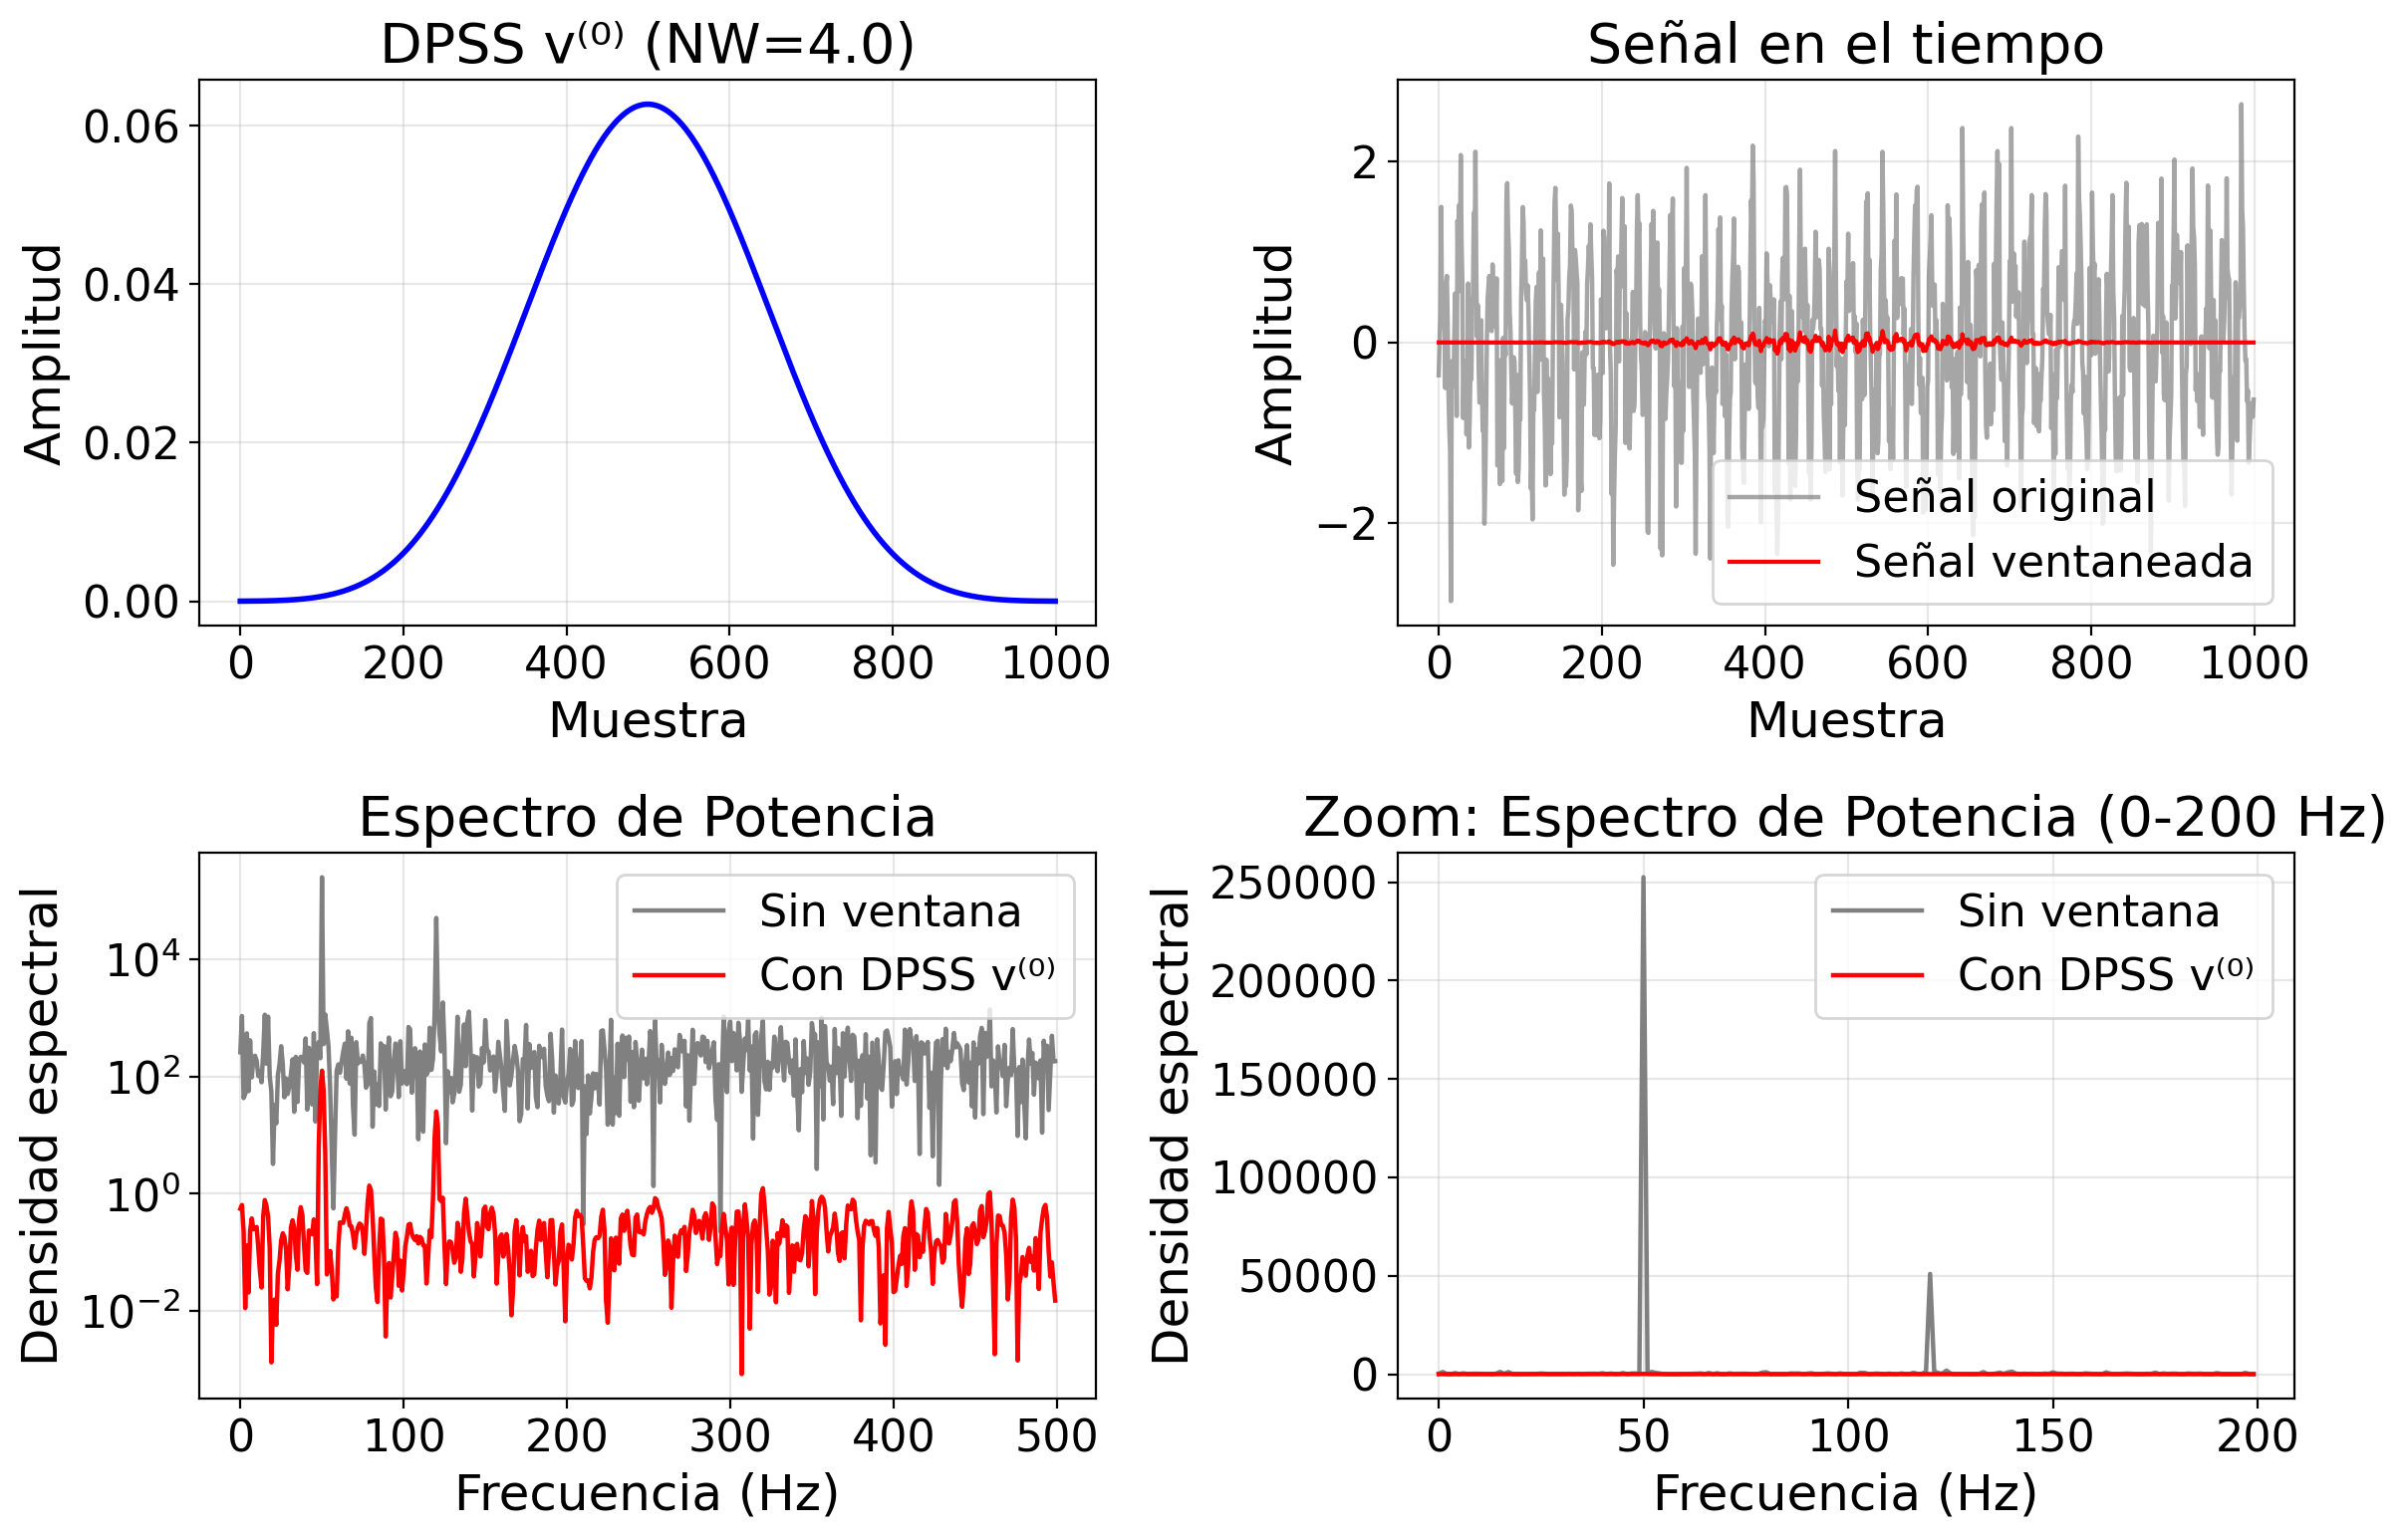

In [34]:
# Parámetros
N = 1000        # Longitud de la señal y del taper
NW = 4.0        # Producto tiempo-ancho de banda
n_tapers = 1    # Primer taper

# Generar el primer DPSS
tapers = windows.dpss(N, NW, n_tapers)
v0 = tapers[0]  # 1er DPSS

# Generar una señal de ejemplo
t = np.linspace(0, 1, N)
signal = (np.sin(2 * np.pi * 50 * t) + 
          0.5 * np.sin(2 * np.pi * 120 * t) +
          np.random.randn(N) * 0.5)

# Aplicar el taper a la señal
signal_tapered = signal * v0

# Calcular el periodograma (estimación espectral)
freqs = np.fft.rfftfreq(N, d=1/N)
psd_tapered = np.abs(np.fft.rfft(signal_tapered))**2
psd_original = np.abs(np.fft.rfft(signal))**2

# Visualización
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(v0, 'b-', linewidth=2)
plt.title(f'DPSS v⁽⁰⁾ (NW={NW})')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(signal, 'gray', alpha=0.7, label='Señal original')
plt.plot(signal_tapered, 'r-', linewidth=1.5, label='Señal ventaneada')
plt.title('Señal en el tiempo')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.semilogy(freqs[:500], psd_original[:500], 'gray', label='Sin ventana')
plt.semilogy(freqs[:500], psd_tapered[:500], 'r-', label='Con DPSS v⁽⁰⁾')
plt.title('Espectro de Potencia')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(freqs[:200], psd_original[:200], 'gray', label='Sin ventana')
plt.plot(freqs[:200], psd_tapered[:200], 'r-', label='Con DPSS v⁽⁰⁾')
plt.title('Zoom: Espectro de Potencia (0-200 Hz)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


> **Nota:** En este bloque de código vemos como el uso de un DPSS (el vector propio V^{0}) nos cambia la señal original.


Usando 7 tapers para NW=4.0
Autovalores: [1.         0.99999997 0.99999879 0.99996756 0.99941019 0.99250534
 0.93665556]


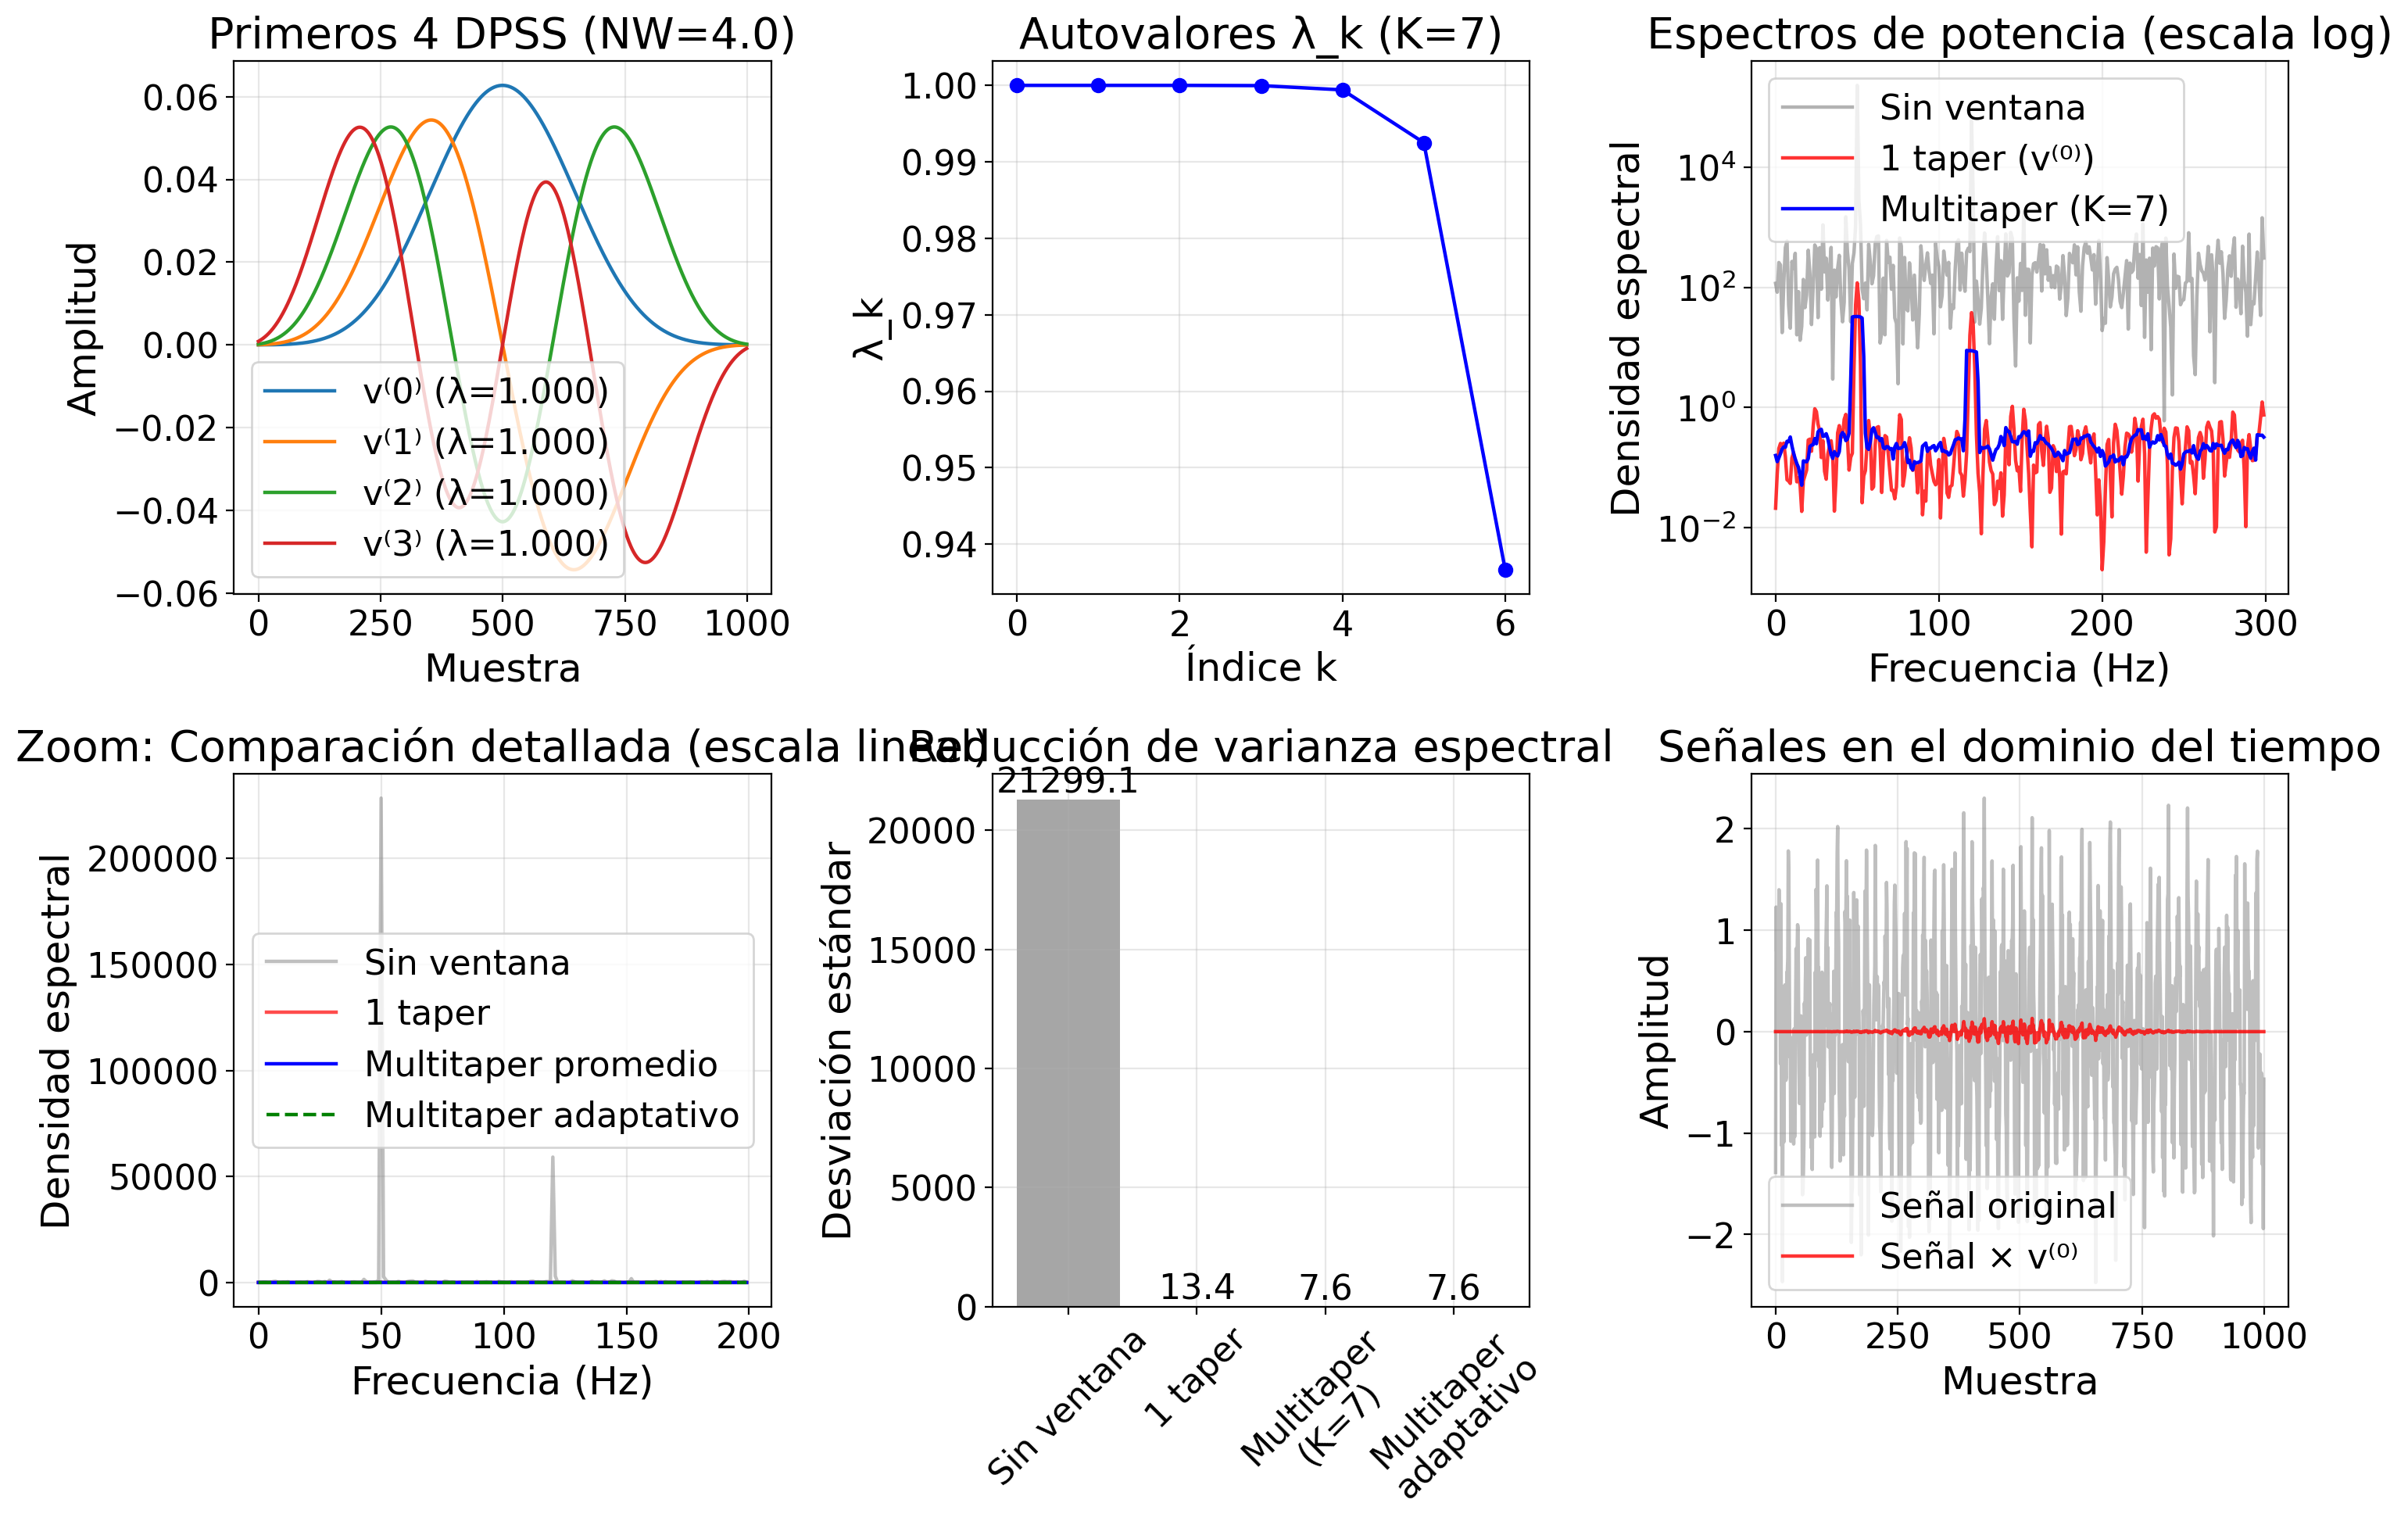


=== RESULTADOS ===
Parámetros: N=1000, NW=4.0, K=7

Autovalores:
  λ_0 = 1.000000
  λ_1 = 1.000000
  λ_2 = 0.999999
  λ_3 = 0.999968
  λ_4 = 0.999410
  λ_5 = 0.992505
  λ_6 = 0.936656

Varianza relativa (respecto a sin ventana):
  - 1 taper (v⁽⁰⁾): 0.001
  - Multitaper promedio: 0.000
  - Multitaper adaptativo: 0.000

Reducción de varianza:
  - 1 taper: 99.9%
  - Multitaper: 100.0%


In [35]:

# Parámetros
N = 1000        # Longitud de la señal y del taper
NW = 4.0        # Producto tiempo-ancho de banda

# Generar una señal de ejemplo 
t = np.linspace(0, 1, N)
signal = (np.sin(2 * np.pi * 50 * t) + 
          0.5 * np.sin(2 * np.pi * 120 * t) +
          np.random.randn(N) * 0.5)

# Calcular frecuencias para FFT
freqs = np.fft.rfftfreq(N, d=1/N)
psd_original = np.abs(np.fft.rfft(signal))**2

# Primer DPSS
tapers_single = windows.dpss(N, NW, 1)
v0 = tapers_single[0]  # Primer DPSS

# Aplicar el taper a la señal
signal_tapered = signal * v0
psd_tapered = np.abs(np.fft.rfft(signal_tapered))**2

# Generar múltiples DPSS 
K = int(2 * NW - 1)  # Número de tapers a usar
tapers, eigenvalues = windows.dpss(N, NW, K, return_ratios=True)

print(f"Usando {K} tapers para NW={NW}")
print(f"Autovalores: {eigenvalues}")

# Método 1: Promedio simple
psd_multitaper = np.zeros(len(freqs))
for i in range(K):
    signal_tapered_i = signal * tapers[i]
    psd_i = np.abs(np.fft.rfft(signal_tapered_i))**2
    psd_multitaper += psd_i / K

# Método 2: Pesos adaptativos
psd_adaptive = np.zeros(len(freqs))
for i in range(K):
    signal_tapered_i = signal * tapers[i]
    psd_i = np.abs(np.fft.rfft(signal_tapered_i))**2
    psd_adaptive += eigenvalues[i] * psd_i
psd_adaptive /= np.sum(eigenvalues)  # Normalizar

#==========
# Visualización 
plt.figure(figsize=(15, 10))

# 1. Mostrar los tapers
plt.subplot(2, 3, 1)
for i in range(min(4, K)):
    plt.plot(tapers[i], label=f'v⁽{i}⁾ (λ={eigenvalues[i]:.3f})')
plt.title(f'Primeros {min(4, K)} DPSS (NW={NW})')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Autovalores
plt.subplot(2, 3, 2)
plt.plot(range(K), eigenvalues, 'bo-')
plt.title(f'Autovalores λ_k (K={K})')
plt.xlabel('Índice k')
plt.ylabel('λ_k')
plt.grid(True, alpha=0.3)

# 3. Comparación de espectros (escala logarítmica)
plt.subplot(2, 3, 3)
plt.semilogy(freqs[:300], psd_original[:300], 'gray', alpha=0.6, label='Sin ventana')
plt.semilogy(freqs[:300], psd_tapered[:300], 'r-', alpha=0.8, label='1 taper (v⁽⁰⁾)')
plt.semilogy(freqs[:300], psd_multitaper[:300], 'b-', label=f'Multitaper (K={K})')
plt.title('Espectros de potencia (escala log)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Comparación detallada (escala lineal)
plt.subplot(2, 3, 4)
plt.plot(freqs[:200], psd_original[:200], 'gray', alpha=0.5, label='Sin ventana')
plt.plot(freqs[:200], psd_tapered[:200], 'r-', alpha=0.7, label='1 taper')
plt.plot(freqs[:200], psd_multitaper[:200], 'b-', label='Multitaper promedio')
plt.plot(freqs[:200], psd_adaptive[:200], 'g--', label='Multitaper adaptativo')
plt.title('Zoom: Comparación detallada (escala lineal)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Reducción de varianza
plt.subplot(2, 3, 5)
freq_range = (40, 160)  # Rango alrededor de los tonos
idx_range = np.where((freqs >= freq_range[0]) & (freqs <= freq_range[1]))[0]

std_original = np.std(psd_original[idx_range])
std_tapered = np.std(psd_tapered[idx_range])
std_multitaper = np.std(psd_multitaper[idx_range])
std_adaptive = np.std(psd_adaptive[idx_range])

methods = ['Sin ventana', '1 taper', f'Multitaper\n(K={K})', 'Multitaper\nadaptativo']
std_values = [std_original, std_tapered, std_multitaper, std_adaptive]

bars = plt.bar(methods, std_values, alpha=0.7, 
               color=['gray', 'red', 'blue', 'green'])
plt.title('Reducción de varianza espectral')
plt.ylabel('Desviación estándar')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Añadir valores en las barras
for bar, value in zip(bars, std_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{value:.1f}', ha='center', va='bottom')

# 6. Señales en el tiempo
plt.subplot(2, 3, 6)
plt.plot(signal, 'gray', alpha=0.5, label='Señal original')
plt.plot(signal * tapers[0], 'r-', alpha=0.8, label='Señal × v⁽⁰⁾')
plt.title('Señales en el dominio del tiempo')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===========
# Resultados númericos
print(f"\n=== RESULTADOS ===")
print(f"Parámetros: N={N}, NW={NW}, K={K}")
print(f"\nAutovalores:")
for i in range(K):
    print(f"  λ_{i} = {eigenvalues[i]:.6f}")

print(f"\nVarianza relativa (respecto a sin ventana):")
print(f"  - 1 taper (v⁽⁰⁾): {std_tapered/std_original:.3f}")
print(f"  - Multitaper promedio: {std_multitaper/std_original:.3f}")
print(f"  - Multitaper adaptativo: {std_adaptive/std_original:.3f}")

print(f"\nReducción de varianza:")
print(f"  - 1 taper: {(1 - std_tapered/std_original)*100:.1f}%")
print(f"  - Multitaper: {(1 - std_multitaper/std_original)*100:.1f}%")


> **Nota:** Este bloque de código vemos el uso de varios DPSS


### Wavelets

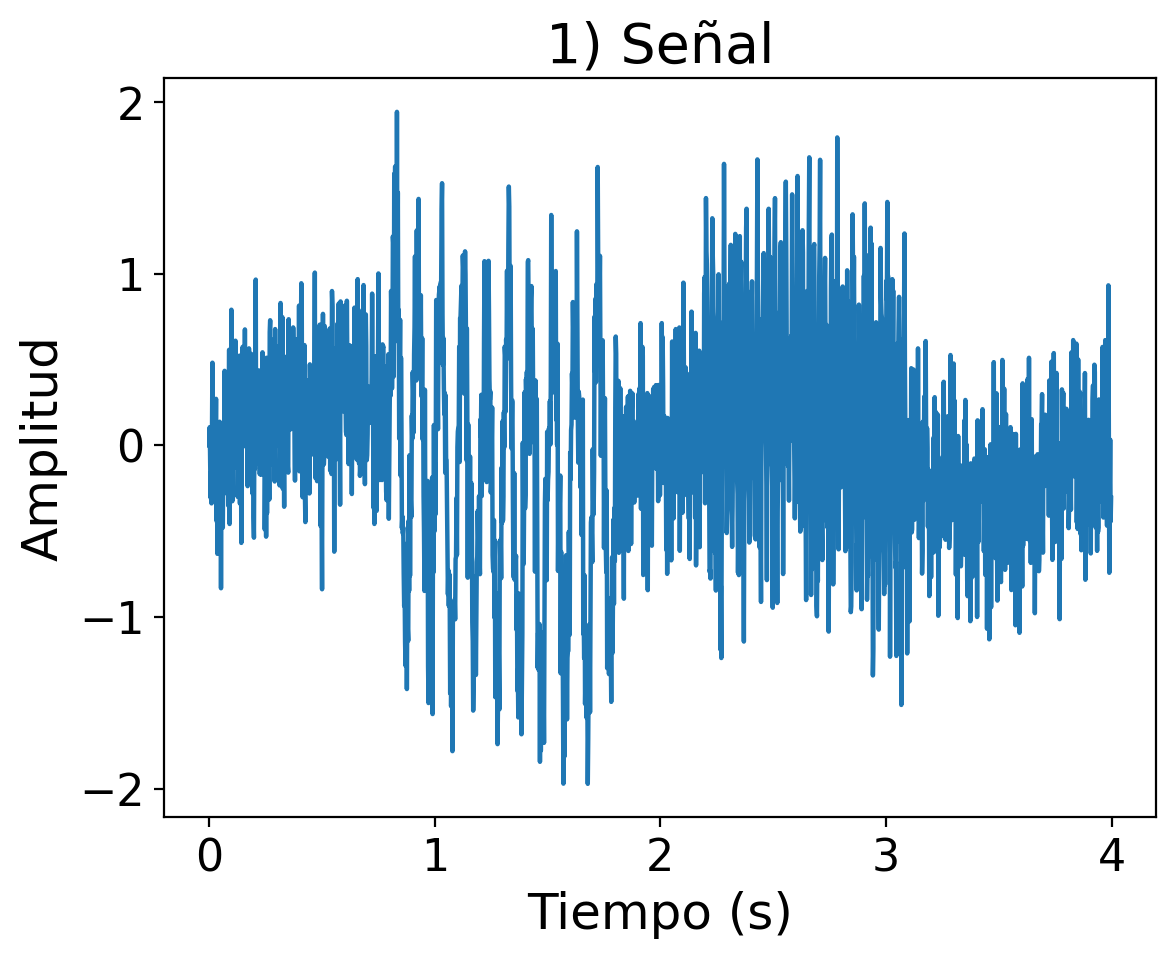

In [36]:
# Para reproducibilidad
rng = np.random.default_rng(7)

# Parámetros base 
fs = 500          # Frecuencia de muestreo (Hz)
T = 4.0           # Duración (s)
t = np.arange(0, T, 1/fs)

# Señal y Bursts 
burst_alpha = np.sin(2*np.pi*10*t) * ((t > 0.8) & (t < 1.8))          # 10 Hz
burst_gamma = 0.8*np.sin(2*np.pi*40*t) * ((t > 2.2) & (t < 3.1))      # 40 Hz

# Tendencia lenta 
drift = 0.3*np.sin(2*np.pi*0.5*t)

# Ruido blanco
noise = 0.35*rng.standard_normal(t.size)

x = burst_alpha + burst_gamma + drift + noise

plt.figure()
plt.plot(t, x)
plt.title("1) Señal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

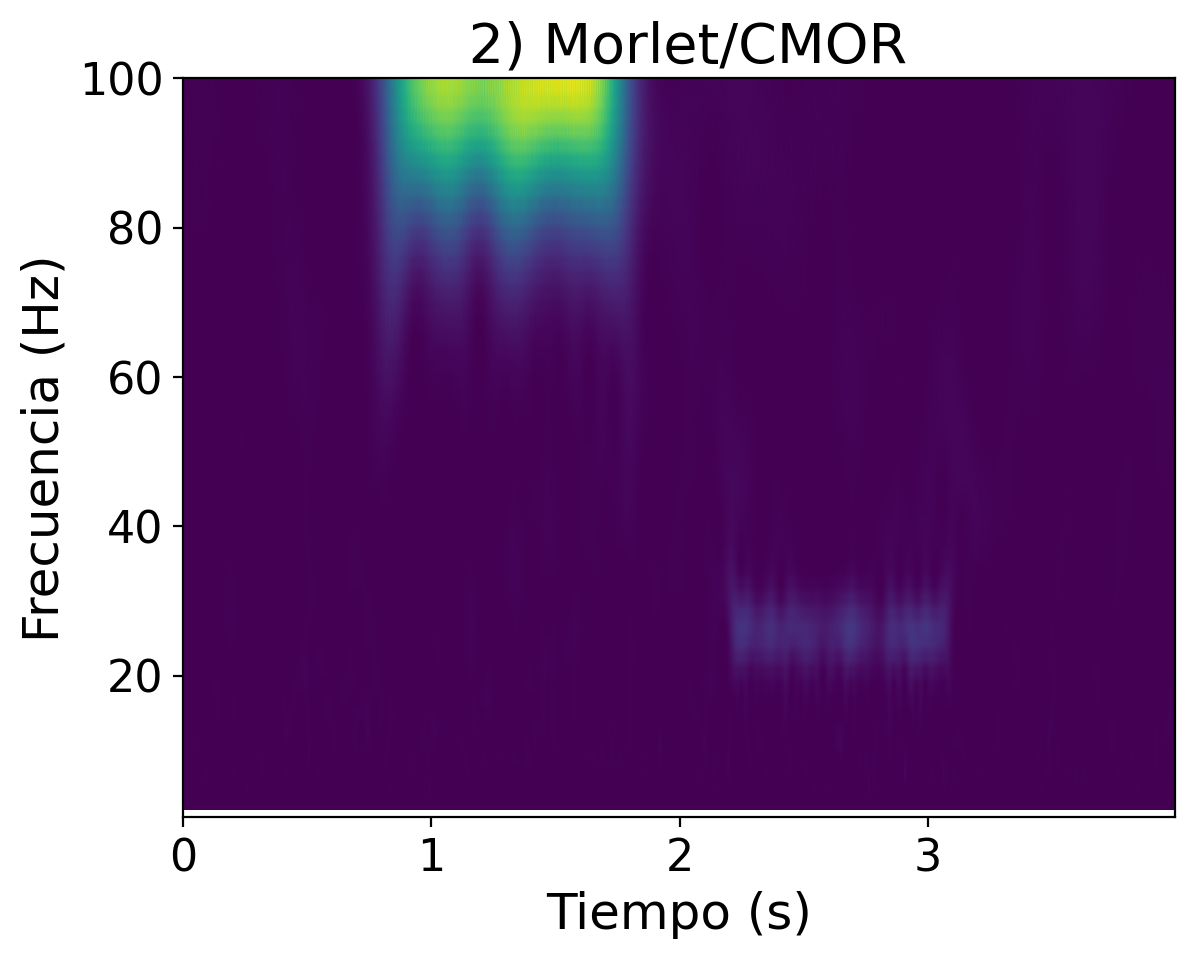

In [37]:
import pywt

wavelet_cwt = 'cmor1.5-1.0'

scales = np.arange(1, 256)  # ajusta según fs / rango de frecuencias deseado
coeffs, freqs = pywt.cwt(x, scales, wavelet_cwt, sampling_period=1/fs)

power = np.abs(coeffs)**2

plt.figure()
plt.imshow(
    power,
    extent=[t.min(), t.max(), freqs.max(), freqs.min()],
    aspect='auto'
)
plt.title(" 2) Morlet/CMOR")
plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia (Hz)")
plt.ylim(1, 100)
plt.show()

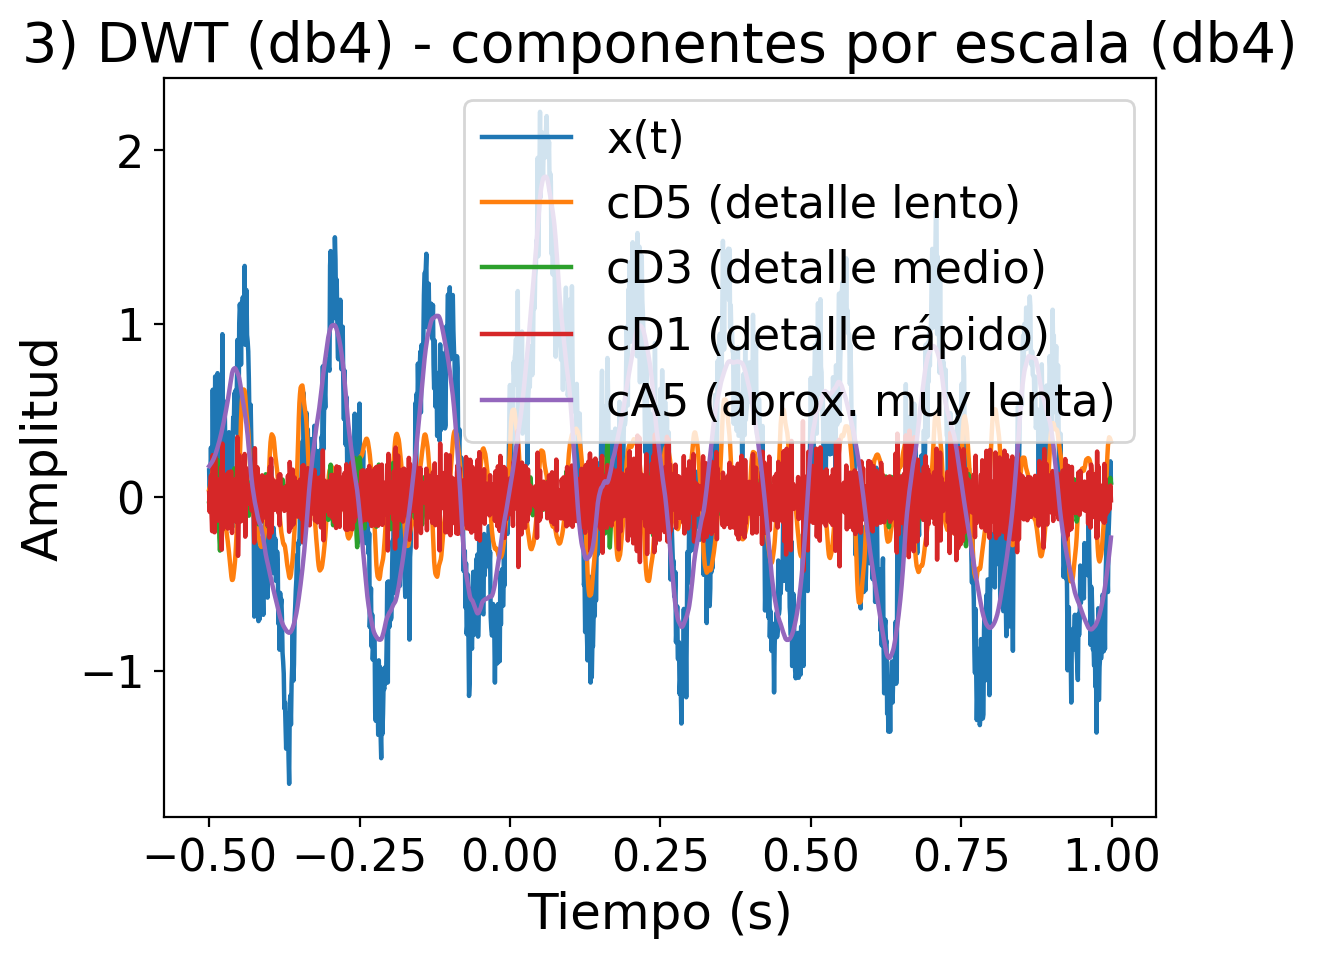

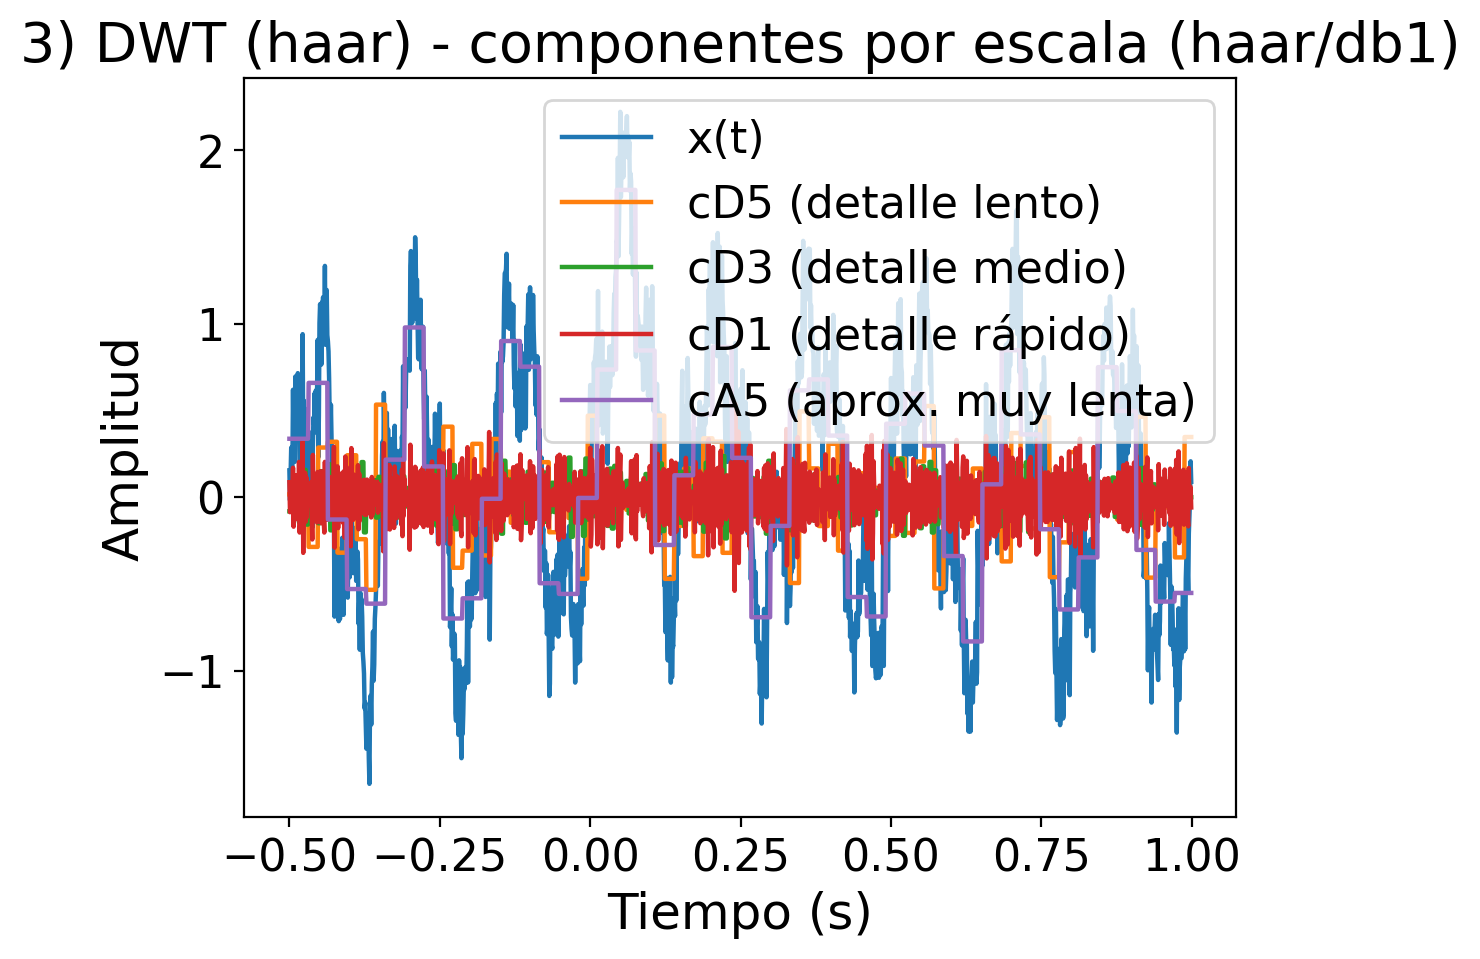

In [42]:
def reconstruct_component(coeffs, wavelet, keep='A', level_to_keep=None):

    # coeficientes = [cA_L, cD_L, cD_{L-1}, ..., cD_1]
    L = len(coeffs) - 1  # nivel total
    new_coeffs = []
    
    for i, c in enumerate(coeffs):
        if i == 0:
            # cA_L
            if keep == 'A' and level_to_keep == L:
                new_coeffs.append(c)
            else:
                new_coeffs.append(np.zeros_like(c))
        else:
            # i=1 es cD_L, i=2 es cD_{L-1}, ...
            current_level = L - (i - 1)
            if keep == 'D' and level_to_keep == current_level:
                new_coeffs.append(c)
            else:
                new_coeffs.append(np.zeros_like(c))
    
    rec = pywt.waverec(new_coeffs, wavelet)
    return rec

def plot_dwt_bands(x, t, wavelet='db4', level=5, title=""):
    coeffs = pywt.wavedec(x, wavelet, level=level)
    L = level
    
    # Reconstruimos algunos detalles representativos
    d1 = reconstruct_component(coeffs, wavelet, keep='D', level_to_keep=1)
    d3 = reconstruct_component(coeffs, wavelet, keep='D', level_to_keep=3)
    d5 = reconstruct_component(coeffs, wavelet, keep='D', level_to_keep=5)
    a5 = reconstruct_component(coeffs, wavelet, keep='A', level_to_keep=5)

    plt.figure()
    plt.plot(t, x, label="x(t)")
    plt.plot(t, d5[:len(t)], label="cD5 (detalle lento)")
    plt.plot(t, d3[:len(t)], label="cD3 (detalle medio)")
    plt.plot(t, d1[:len(t)], label="cD1 (detalle rápido)")
    plt.plot(t, a5[:len(t)], label="cA5 (aprox. muy lenta)")
    plt.title(f"3) DWT ({wavelet}) - componentes por escala " + title)
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.show()

# db4
plot_dwt_bands(x, t, wavelet='db4', level=5, title="(db4)")

# haar (db1)
plot_dwt_bands(x, t, wavelet='haar', level=5, title="(haar/db1)")

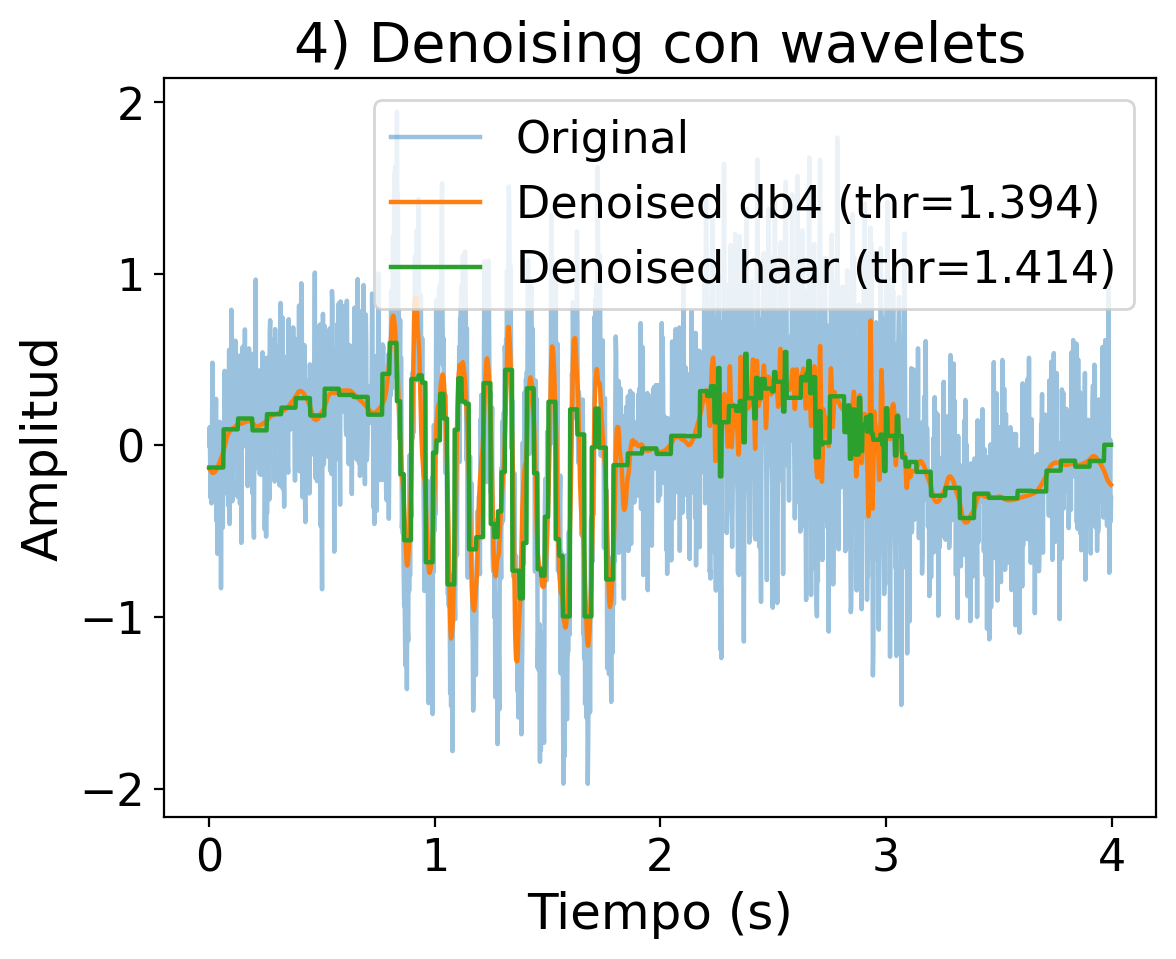

In [39]:
def wavelet_denoise(signal, wavelet='db4', level=5, threshold_scale=1.0, mode='soft'):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    cA, cDs = coeffs[0], coeffs[1:]

    # Estimación robusta 
    sigma = np.median(np.abs(cDs[-1])) / 0.6745
    
    # Umbral universal 
    thr = threshold_scale * sigma * np.sqrt(2*np.log(len(signal)))

    # Umbralado en detalles
    new_cDs = [pywt.threshold(c, thr, mode=mode) for c in cDs]
    new_coeffs = [cA] + new_cDs
    rec = pywt.waverec(new_coeffs, wavelet)[:len(signal)]
    return rec, thr

x_dn_db4, thr_db4 = wavelet_denoise(x, wavelet='db4', level=5, threshold_scale=1.0)
x_dn_haar, thr_haar = wavelet_denoise(x, wavelet='haar', level=5, threshold_scale=1.0)

plt.figure()
plt.plot(t, x, alpha=0.45, label="Original")
plt.plot(t, x_dn_db4, label=f"Denoised db4 (thr={thr_db4:.3f})")
plt.plot(t, x_dn_haar, label=f"Denoised haar (thr={thr_haar:.3f})")
plt.title("4) Denoising con wavelets")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

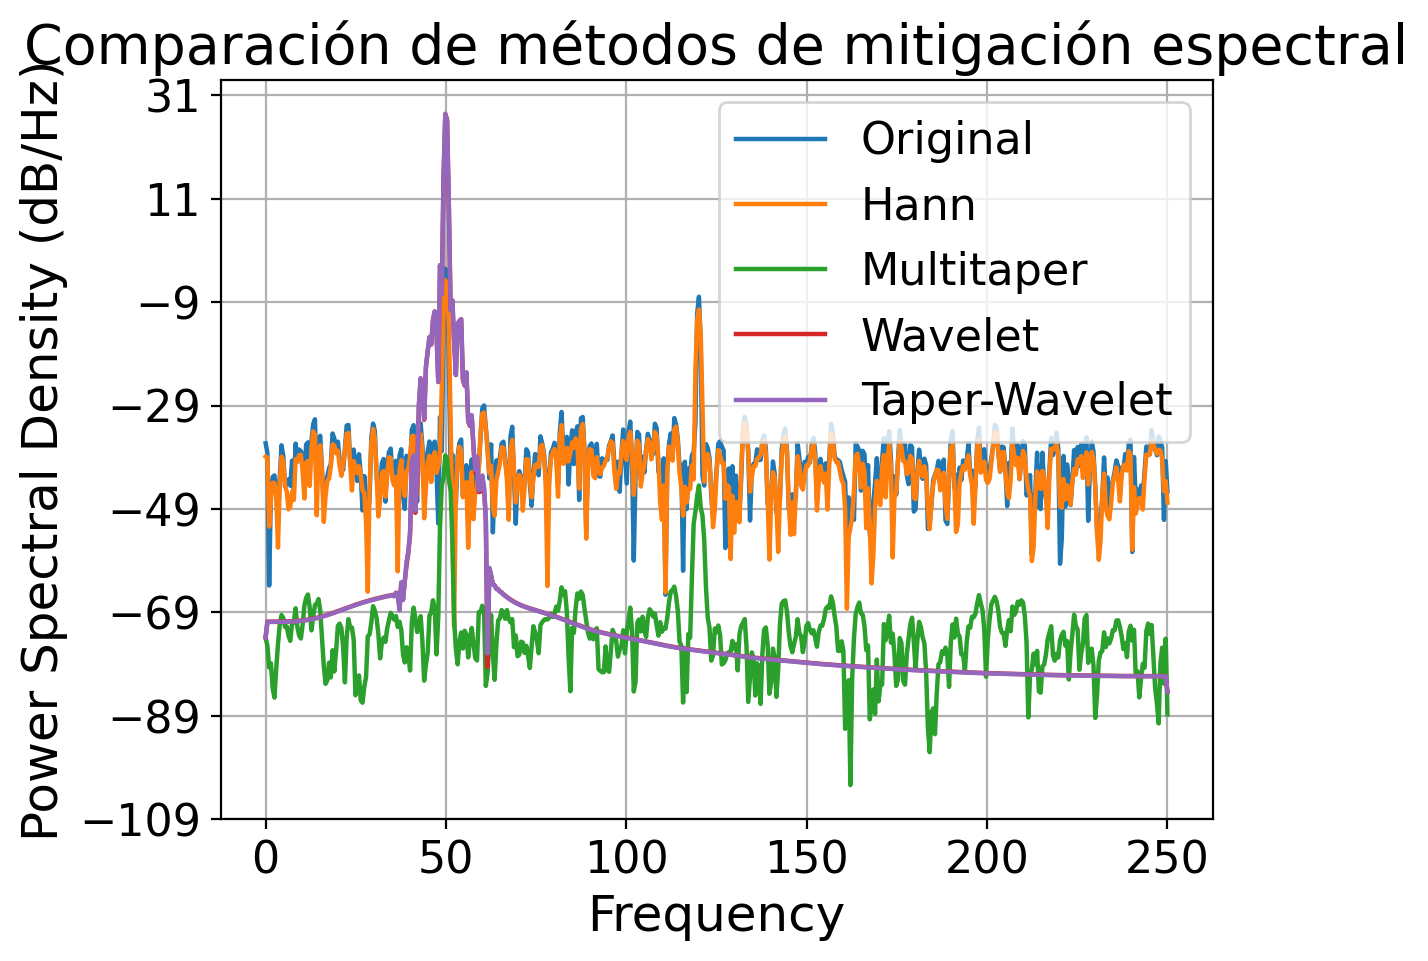

In [40]:
# Señal 
fs = 500  # Hz
t = np.arange(0, 2, 1/fs)
signal = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t) + 0.2*np.random.randn(len(t))

# Ventana clásica (Hann) 
hann_win = windows.hann(len(signal))
signal_hann = signal * hann_win

# Multitaper (DPSS) 
tapers = dpss(len(signal), NW=4, Kmax=3)  # 3 tapers
signal_mt = np.mean([signal * taper for taper in tapers], axis=0)

# Wavelet 
def morlet_wavelet(t, f0=50, sigma=0.05):
    return np.exp(2j*np.pi*f0*t) * np.exp(-t**2/(2*sigma**2))

tw = np.linspace(-1, 1, len(signal))
morlet = morlet_wavelet(tw, f0=50, sigma=0.05)
# convolución
signal_wavelet = np.convolve(signal, np.real(morlet), mode='same')

# Taper-Wavelet (Morlet * Hann)
morlet_tapered = np.real(morlet) * hann_win
signal_tw = np.convolve(signal, morlet_tapered, mode='same')

# Espectros comparativos 
f, Pxx_signal = plt.psd(signal, NFFT=1024, Fs=fs, label='Original')
f, Pxx_hann = plt.psd(signal_hann, NFFT=1024, Fs=fs, label='Hann')
f, Pxx_mt = plt.psd(signal_mt, NFFT=1024, Fs=fs, label='Multitaper')
f, Pxx_wav = plt.psd(signal_wavelet, NFFT=1024, Fs=fs, label='Wavelet')
f, Pxx_tw = plt.psd(signal_tw, NFFT=1024, Fs=fs, label='Taper-Wavelet')

plt.legend()

plt.title("Comparación de métodos de mitigación espectral")
plt.show()


> **Nota:** Este bloque de código nos muestra la comparacion de varios métodos de mitigacion


### Ejercicios de práctica: Mitigación de errores en análisis de señales

En estos ejercicios pondrás en práctica técnicas como **ventanas**, **tapers** y **wavelets** para distintos tipos de señales. 
Avanza de los más sencillos a los más completos.

---

1. **Ventanas y fugas espectrales**
   - Genera una señal senoidal de 15 Hz en 1 segundo.
   - Calcula la FFT con y sin aplicar una ventana (Hamming, Hann, Blackman).
   - Compara la dispersión del pico en el espectro.
   - ¿Cuál ventana reduce mejor la fuga espectral (*spectral leakage*)?

2. **Ventanas en análisis de audio**
   - Descarga un archivo de tu eleccion de registros de **EMG** ó **ECG**.
   - Puedes ocupar la clase ECG en el github como referencia 
   - Calcula el espectrograma con diferentes longitudes de ventana.
   - Observa cómo cambia la claridad de las vocales y consonantes.
   - ¿Qué pasa si usas ventanas muy cortas vs. muy largas?

3. **Multitaper en una señal compuesta**
   - Crea una señal con dos tonos senoidales: 40 Hz y 100 Hz, más ruido blanco.
   - Calcula la densidad espectral con Welch y con multitaper (DPSS).
   - ¿Cuál método separa mejor los dos picos?
   - ¿Qué pasa si bajas mucho la amplitud de la segunda señal?

4. **Wavelets en eventos transitorios**
   - Genera una señal con un pulso de 20 Hz entre 2 y 4 s, más ruido.
   - Analízala con:
     - STFT (ventanas cortas)
     - Wavelets de Morlet
   - ¿Qué método localiza mejor el inicio y el fin del pulso?
   - ¿Cuál da una frecuencia central más precisa?

5. **ITPC en señales simuladas**
   - Genera 50 ensayos con pulsos senoidales de 12 Hz, pero con una variación aleatoria de fase.
   - Calcula el ITPC y compáralo con el caso en el que todas las fases son iguales.
   - Explica cómo la variabilidad de fase reduce la consistencia entre ensayos.

---



## Tiempo-frecuencia

En el texto sección 4.10 se ve con detenimiento diversas tecnicas de análisis de Tiempo-Frecuencia, ahora veremos aplicaciónes de estos.

Veamos ejemplos de las normalizaciones basales


### Normalizaciones Basales


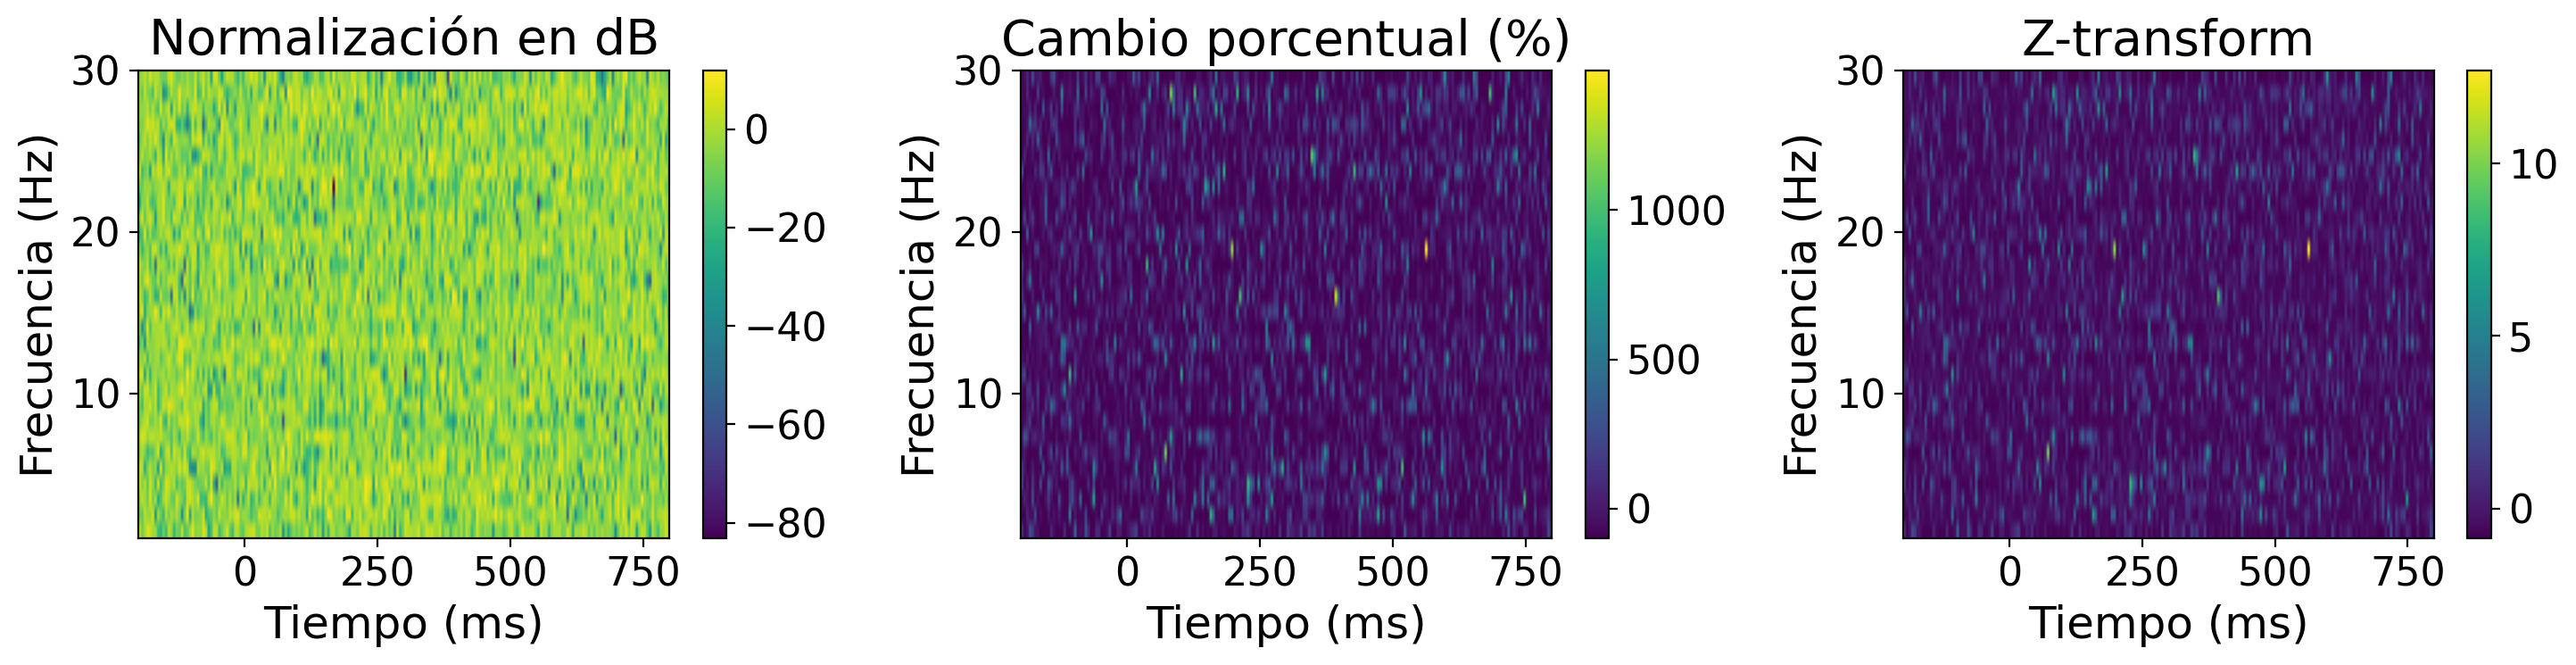

In [43]:
# Simulación de datos de potencia tiempo–frecuencia
np.random.seed(0)
frecs = 30
tiempos = 200
power = np.abs(np.random.randn(frecs, tiempos))**2 * 10  # potencia simulada

# Definimos un periodo de baseline
baseline_idx = np.arange(0, 50)
baseline = power[:, baseline_idx].mean(axis=1, keepdims=True)

# Conversión a decibeles (dB) 
power_db = 10 * np.log10(power / baseline)

# Cambio porcentual
power_pct = (power - baseline) / baseline * 100

# Trans-Z
baseline_mean = baseline
baseline_std = power[:, baseline_idx].std(axis=1, keepdims=True)
power_z = (power - baseline_mean) / baseline_std

#=========
# Graficar los tres métodos
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

im1 = axs[0].imshow(power_db, aspect='auto', origin='lower',
                    extent=[-200, 800, 1, frecs])
axs[0].set_title('Normalización en dB')
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(power_pct, aspect='auto', origin='lower',
                    extent=[-200, 800, 1, frecs])
axs[1].set_title('Cambio porcentual (%)')
plt.colorbar(im2, ax=axs[1])

im3 = axs[2].imshow(power_z, aspect='auto', origin='lower',
                    extent=[-200, 800, 1, frecs])
axs[2].set_title('Z-transform')
plt.colorbar(im3, ax=axs[2])

for ax in axs:
    ax.set_xlabel('Tiempo (ms)')
    ax.set_ylabel('Frecuencia (Hz)')

plt.tight_layout()
plt.show()

### ITPC

Veamos como se obtiene el ITPC 

ITPC para fases consistentes: 0.9547
ITPC para fases aleatorias: 0.1755


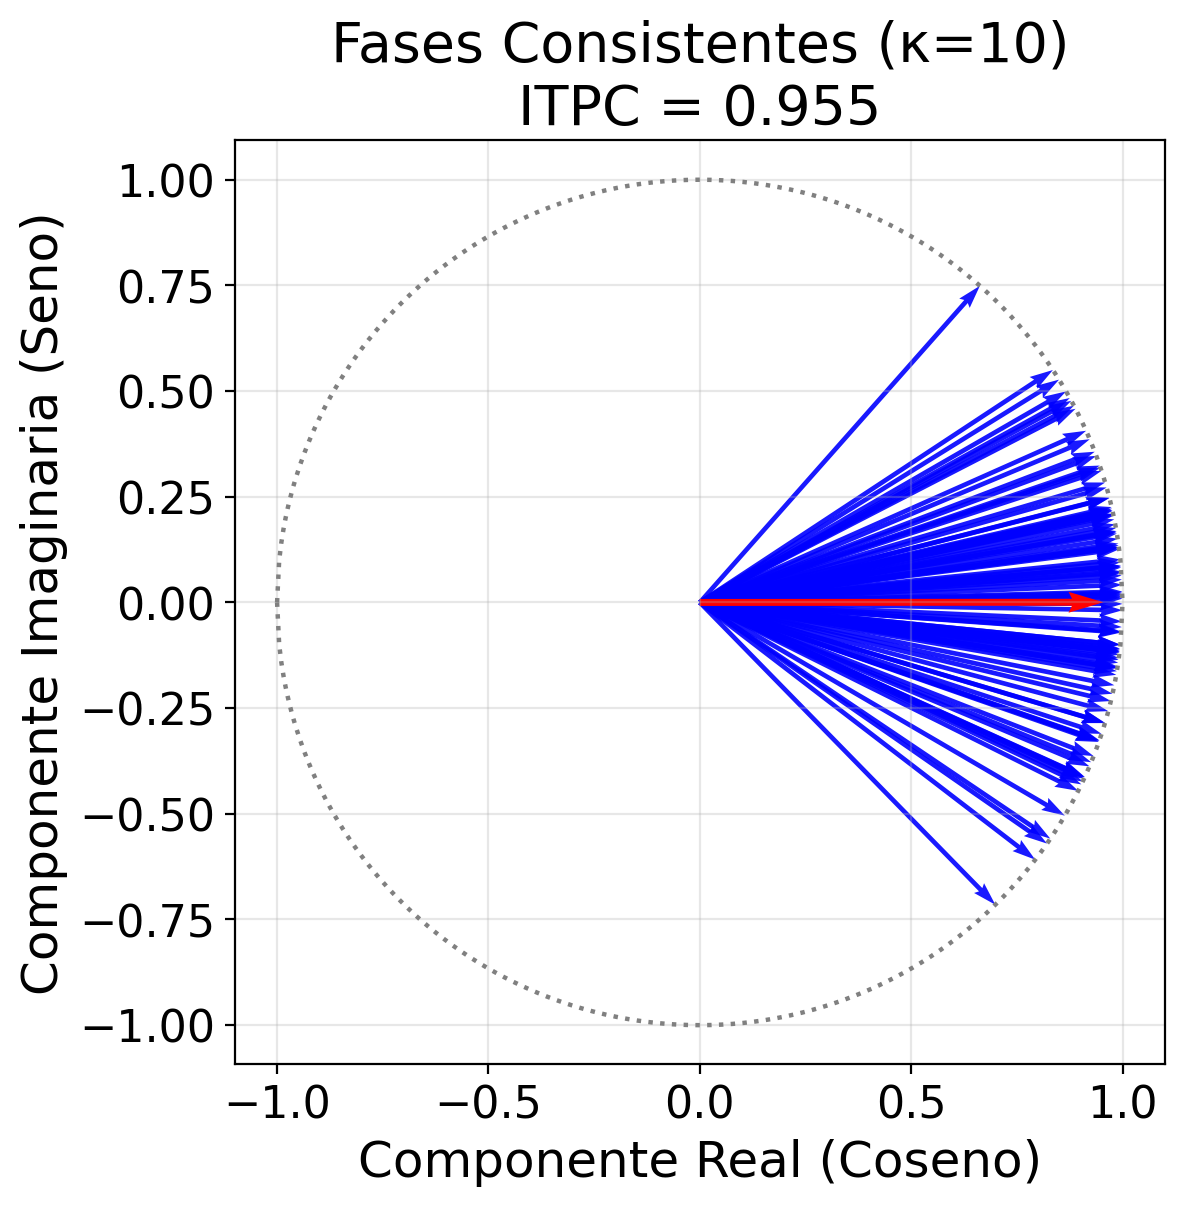

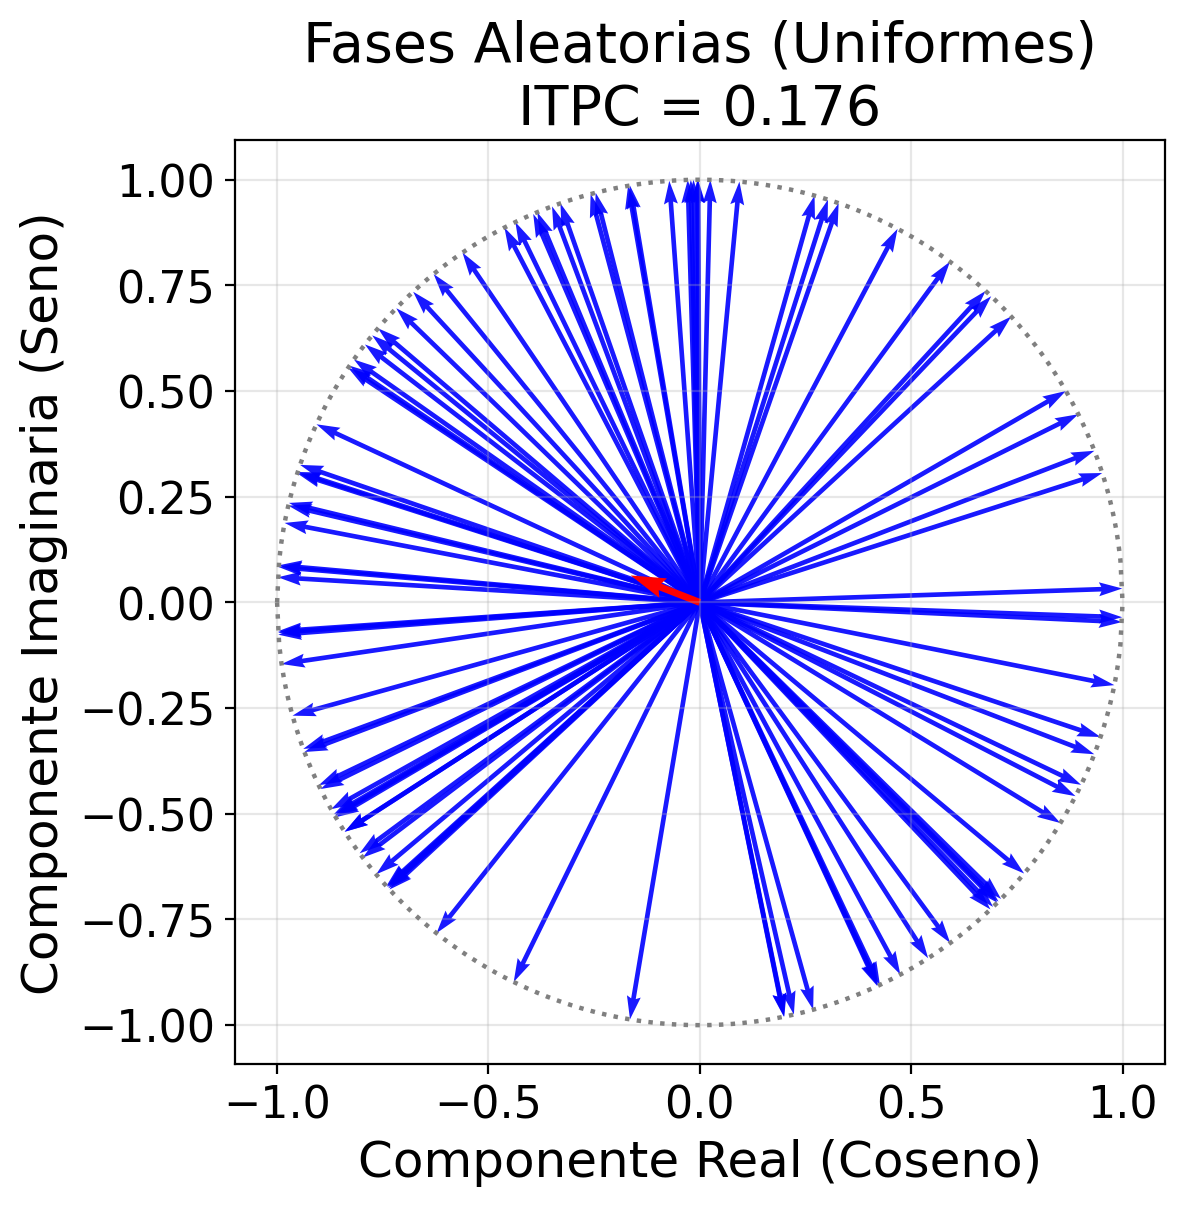

In [44]:
np.random.seed(42)  
N_trials = 100

# Caso 1: Fases altamente consistentes (ITPC ~1)
phase_concentrated = np.random.vonmises(mu=0, kappa=10, size=N_trials)

# Caso 2: Fases aleatorias (ITPC ~0)
phase_random = np.random.uniform(low=-np.pi, high=np.pi, size=N_trials)

def calculate_itpc(phases):
    
    # Convertir cada fase a un vector complejo en el círculo unitario
    vectors = np.exp(1j * phases)
    
    # Calcular el vector promedio
    mean_vector = np.mean(vectors)
    
    # La ITPC es la magnitud (longitud) de ese vector promedio
    itpc = np.abs(mean_vector)
    
    return itpc, mean_vector

# Calcular ITPC para ambos casos
itpc_high, mean_vec_high = calculate_itpc(phase_concentrated)
itpc_low, mean_vec_low = calculate_itpc(phase_random)

print(f"ITPC para fases consistentes: {itpc_high:.4f}")
print(f"ITPC para fases aleatorias: {itpc_low:.4f}")

#=========
# Visualización 
def plot_phases(phases, title, itpc_value):
    plt.figure(figsize=(6, 6))
    
    # graf cada vector de fase
    for phi in phases:
        x = np.cos(phi)
        y = np.sin(phi)
        plt.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, 
                   color='blue', alpha=0.9, width=0.005)
    
    # graf el vector promedio (ITPC)
    mean_vector = np.mean(np.exp(1j * phases))
    plt.quiver(0, 0, mean_vector.real, mean_vector.imag, angles='xy', 
               scale_units='xy', scale=1, color='red', linewidth=3)

    # Definir el rango de x
    x = np.linspace(-1, 1, 400)  # 400 puntos entre -1 y 1

    # Calcular los valores de y para la mitad superior e inferior
    y_upper = np.sqrt(1 - x**2)  # Mitad superior del círculo
    y_lower = -np.sqrt(1 - x**2) # Mitad inferior del círculo


    #==============
    # Grafica
    #plt.figure(figsize=(6, 6))
    plt.plot(x, y_upper, color='grey', linestyle='dotted' ,label='$y = \sqrt{1 - x^2}$')  # Mitad superior
    plt.plot(x, y_lower, color='grey', linestyle='dotted' ,label='$y = -\sqrt{1 - x^2}$') # Mitad inferior
    
    plt.xlim(-1.2, 1.2)
    plt.plot()
    plt.ylim(-1.2, 1.2)
    plt.gca().set_aspect('equal')
    plt.title(f'{title}\nITPC = {itpc_value:.3f}')
    plt.xlabel('Componente Real (Coseno)')
    plt.ylabel('Componente Imaginaria (Seno)')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')  # Misma escala en ambos ejes 
    #plt.legend()
    plt.show()

plot_phases(phase_concentrated, 'Fases Consistentes (κ=10)', itpc_high)
plot_phases(phase_random, 'Fases Aleatorias (Uniformes)', itpc_low)


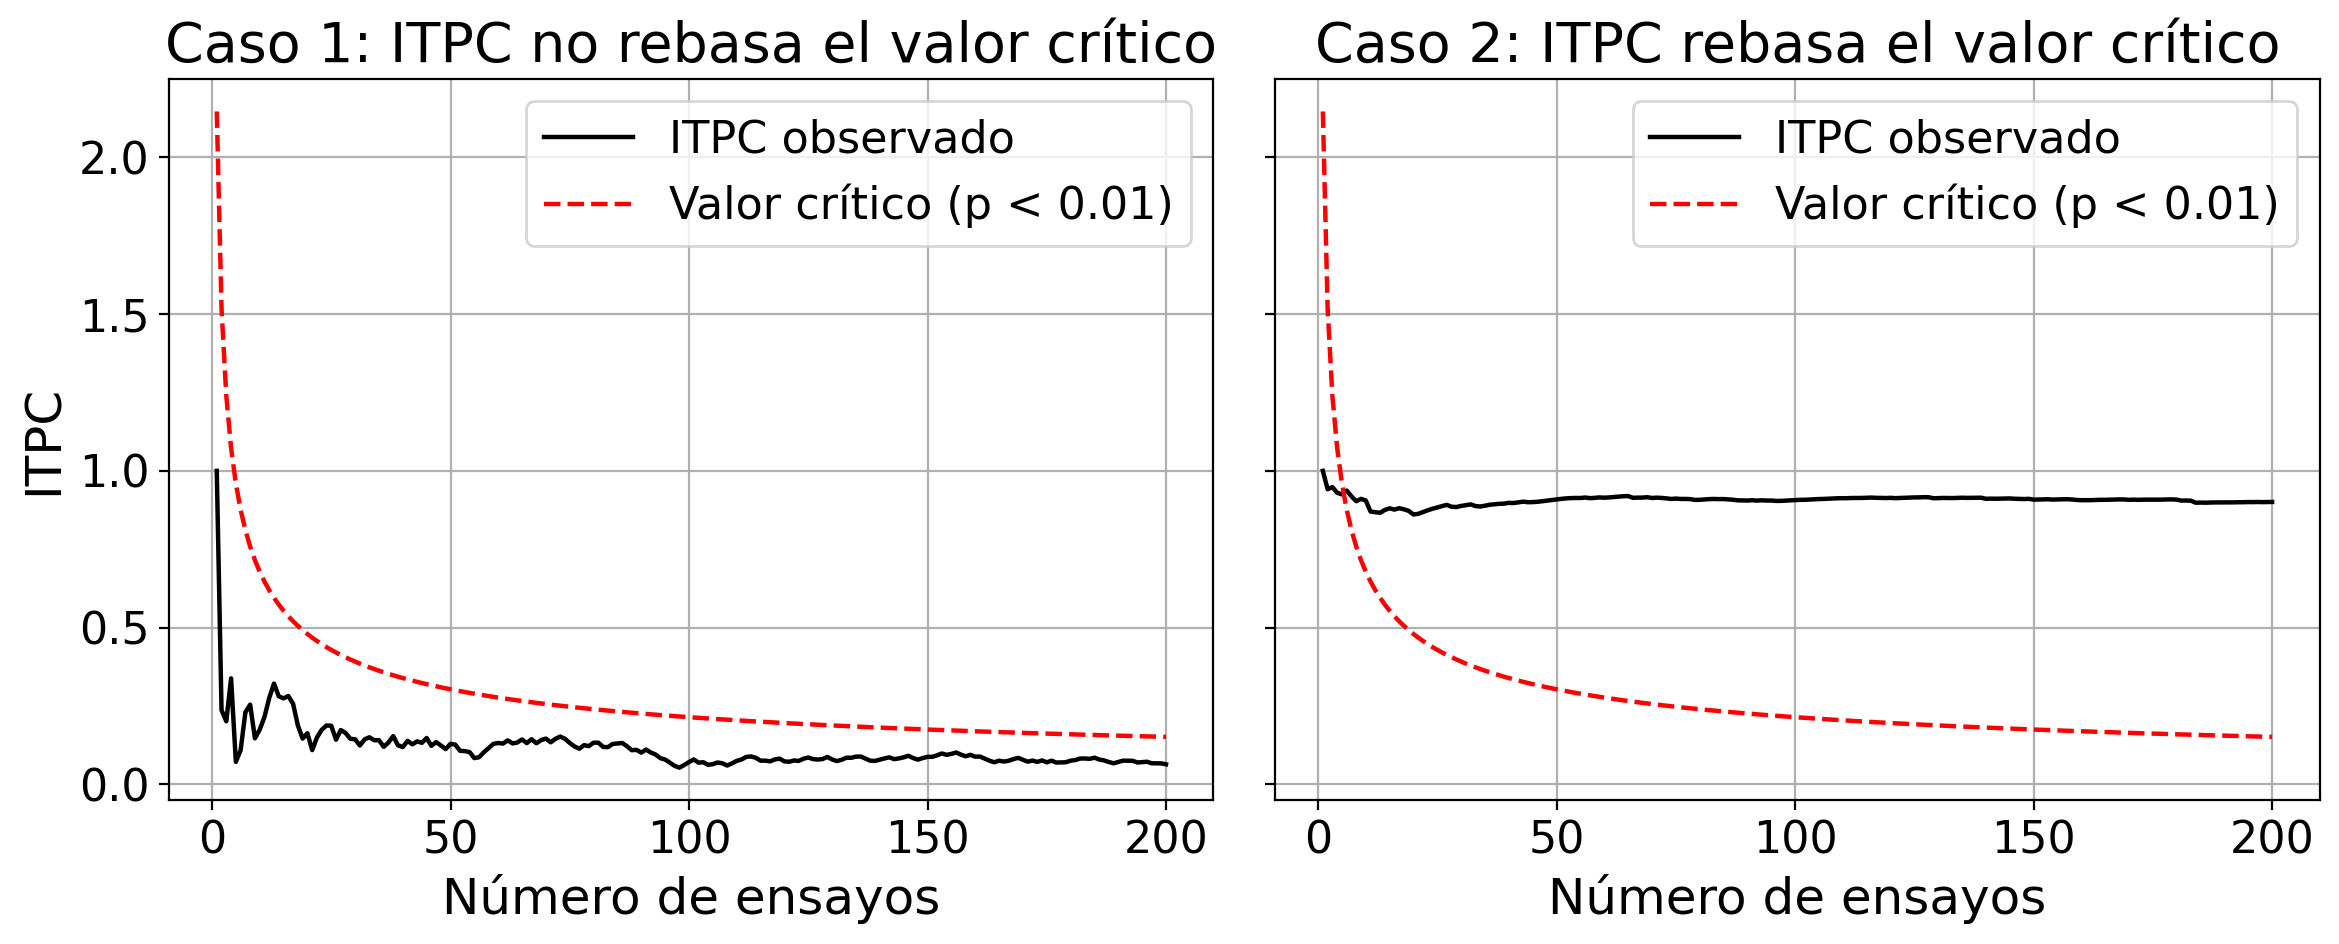

In [18]:
def compute_itpc(phases):
    """Calcula ITPC acumulado a lo largo de los trials."""
    N = len(phases)
    itpc_values = []
    for n in range(1, N + 1):
        vec = np.exp(1j * phases[:n])
        itpc = np.abs(np.mean(vec))
        itpc_values.append(itpc)
    return np.array(itpc_values)

def itpc_critical(alpha, N):
    """Umbral crítico de significancia estadística (Rayleigh approx)."""
    return np.sqrt(-np.log(alpha) / N)

# ------- Simulación de fases ---------
np.random.seed(42)   # reproducibilidad
N_trials = 200
alpha = 0.01
trials = np.arange(1, N_trials + 1)

# Caso 1: fases aleatorias (no debería rebasar)
phases_random = np.random.uniform(0, 2*np.pi, N_trials)
itpc_random = compute_itpc(phases_random)

# Caso 2: fases con cierto alineamiento (sí debería rebasar)
preferred_phase = np.pi/4
phases_locked = preferred_phase + np.random.vonmises(mu=0, kappa=5, size=N_trials)
itpc_locked = compute_itpc(phases_locked)

# Umbral crítico para cada número de ensayos
crit_line = itpc_critical(alpha, trials)

# ---------- Gráficas ----------
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Caso 1
axs[0].plot(trials, itpc_random, 'k-', label="ITPC observado")
axs[0].plot(trials, crit_line, 'r--', label="Valor crítico (p < 0.01)")
axs[0].set_title("Caso 1: ITPC no rebasa el valor crítico")
axs[0].set_xlabel("Número de ensayos")
axs[0].set_ylabel("ITPC")
axs[0].legend()
axs[0].grid(True)

# Caso 2
axs[1].plot(trials, itpc_locked, 'k-', label="ITPC observado")
axs[1].plot(trials, crit_line, 'r--', label="Valor crítico (p < 0.01)")
axs[1].set_title("Caso 2: ITPC rebasa el valor crítico")
axs[1].set_xlabel("Número de ensayos")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


> **Nota:** Este nos ayuda a complementar el entendimiento del ITPC, usando hipotesis estadisiticas (enunciadas en el texto)

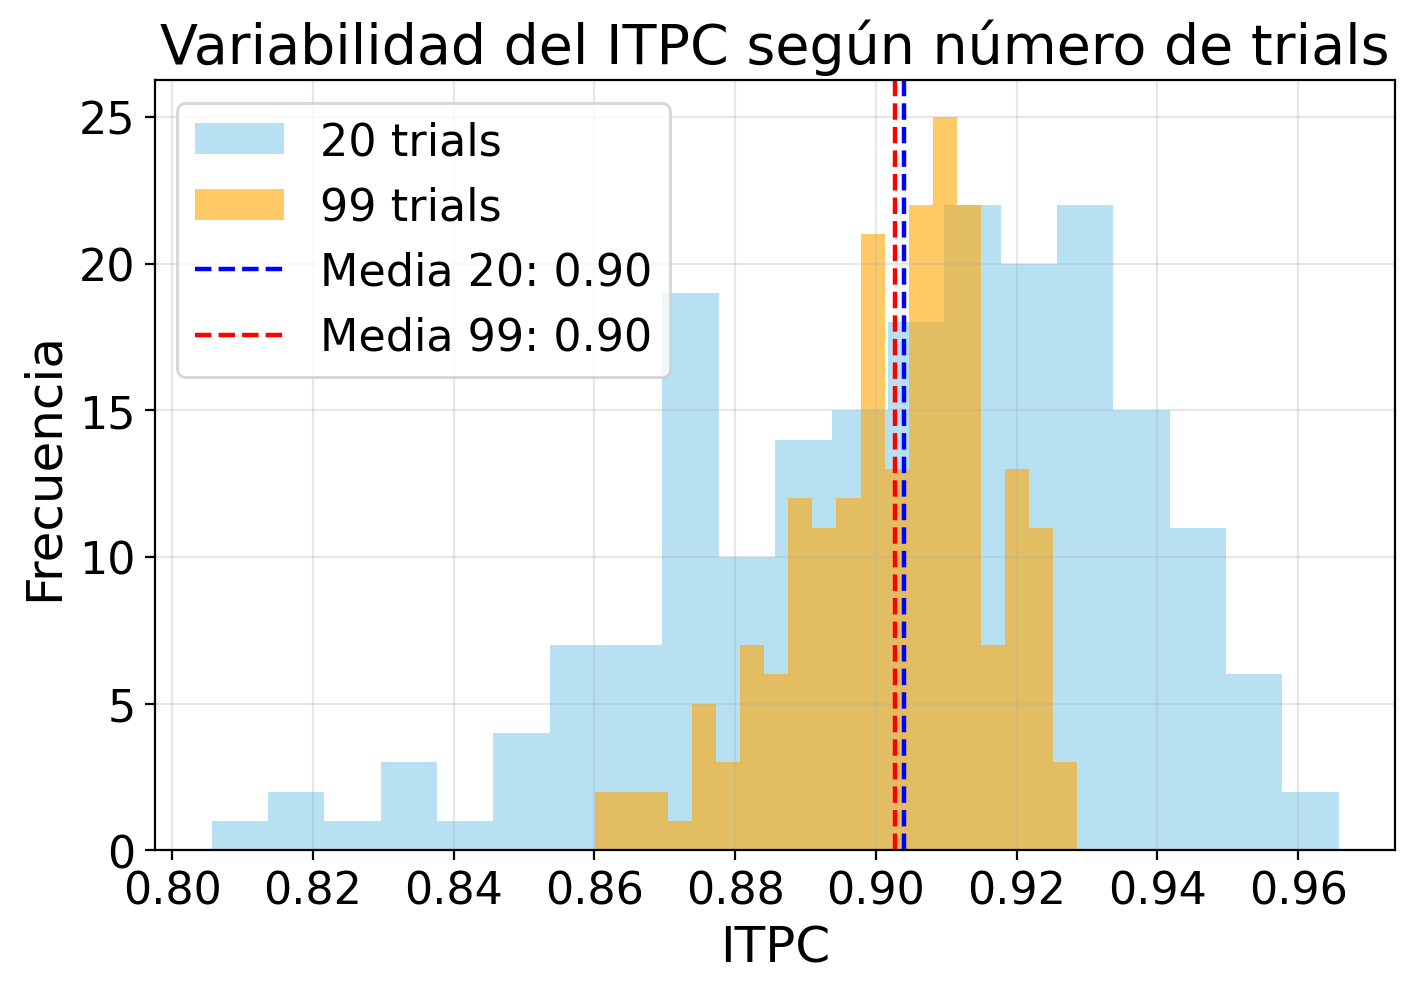

In [45]:
def compute_itpc(phases):
    return np.abs(np.mean(np.exp(1j * phases)))

# Simulación 
np.random.seed(123)
N_reps = 200  # cuántas veces repetimos el muestreo
preferred_phase = np.pi/3

# Distribución con cierto alineamiento
phases_all = preferred_phase + np.random.vonmises(mu=0, kappa=5, size=1000)

# Estimaciones con 20 trials
itpc_20 = [compute_itpc(np.random.choice(phases_all, 20, replace=False))
           for _ in range(N_reps)]

# Estimaciones con 99 trials
itpc_99 = [compute_itpc(np.random.choice(phases_all, 99, replace=False))
           for _ in range(N_reps)]

# =============
# Gráfico comparativo

plt.figure(figsize=(8,5))

plt.hist(itpc_20, bins=20, alpha=0.6, color="skyblue", label="20 trials")
plt.hist(itpc_99, bins=20, alpha=0.6, color="orange", label="99 trials")

plt.axvline(np.mean(itpc_20), color="blue", linestyle="--", label=f"Media 20: {np.mean(itpc_20):.2f}")
plt.axvline(np.mean(itpc_99), color="red", linestyle="--", label=f"Media 99: {np.mean(itpc_99):.2f}")

plt.title("Variabilidad del ITPC según número de trials")
plt.xlabel("ITPC")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


> **Nota:** Este bloque de código nos muestra la variación que hay dependiendo del número de trials


## Apéndices

### Regla de Sturges

Número de clases (Sturges): 6


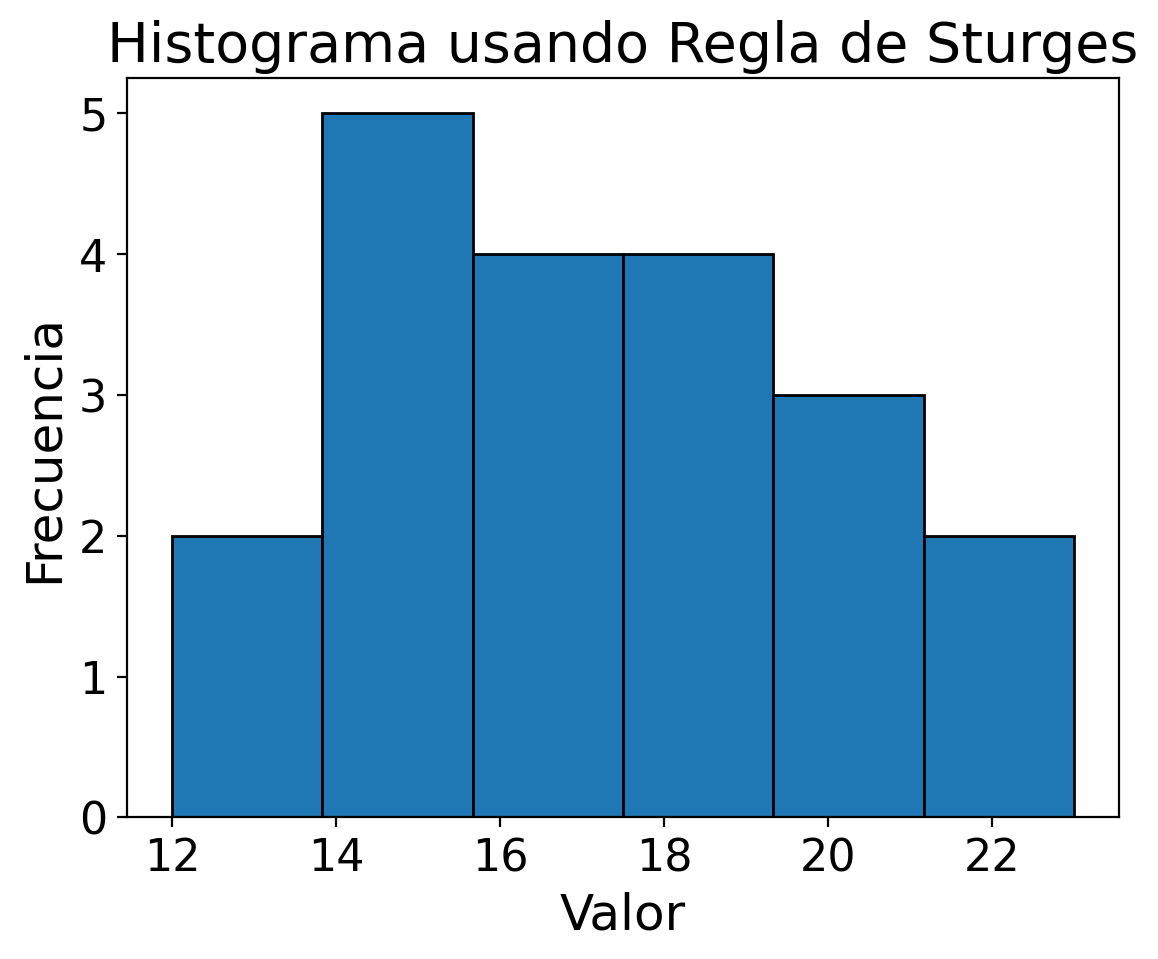

In [3]:
# Datos de ejemplo
datos = np.array([12, 15, 14, 19, 21, 18, 16, 14, 20, 23,
                  17, 13, 15, 14, 22, 18, 19, 16, 17, 21])

# 1. Tamaño de la muestra
n = len(datos)

# 2. Regla de Sturges (log base 10 equivalente)
k_sturges = math.ceil(1 + 3.322 * math.log10(n))
print(f"Número de clases (Sturges): {k_sturges}")

# 3. Construir histograma
plt.hist(datos, bins=k_sturges, edgecolor='black')
plt.title('Histograma usando Regla de Sturges')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

### Permutation Testing

Estadístico observado: -5.000
Valor p (perm): 0.001


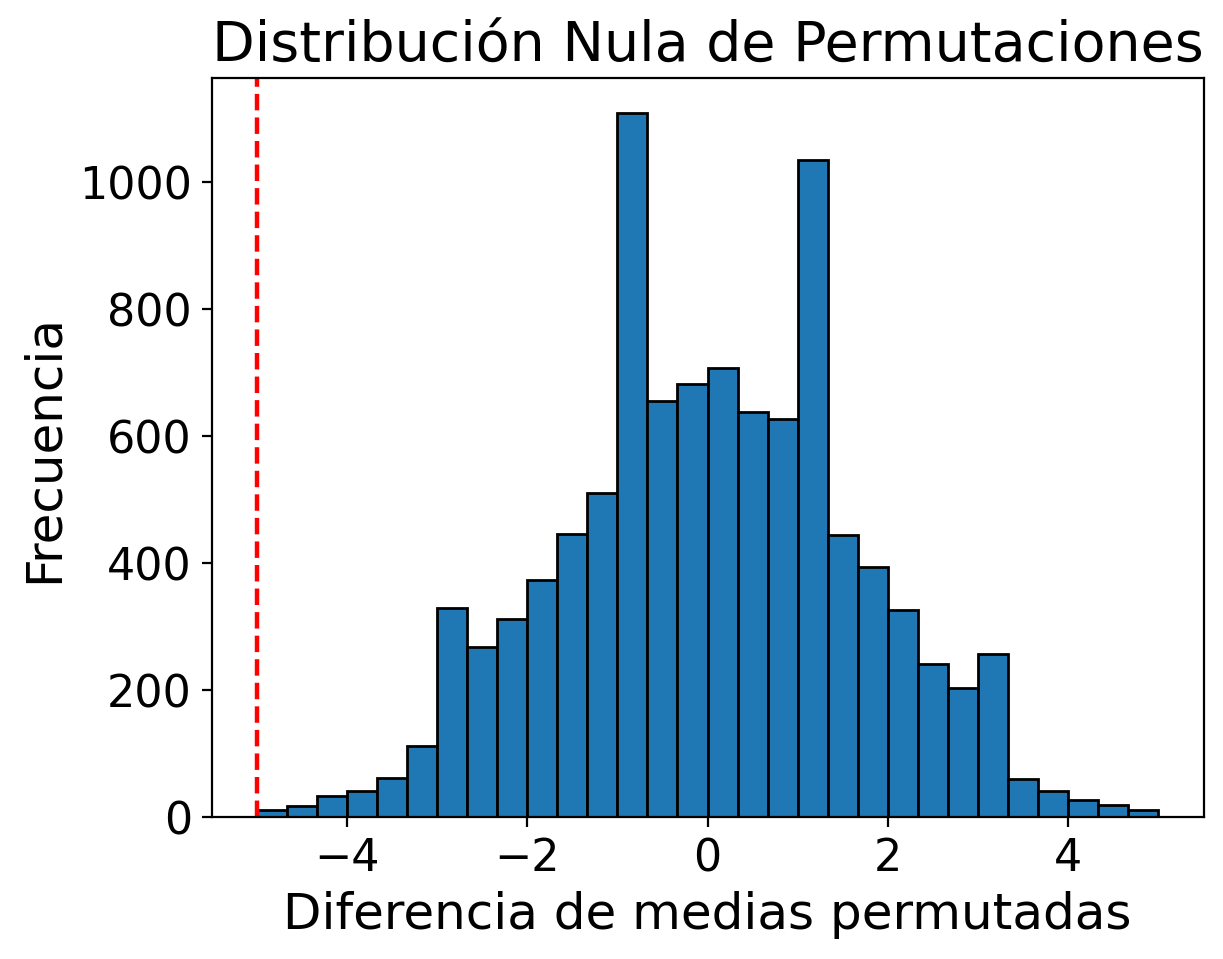

In [4]:
# Datos de ejemplo: dos grupos
x = np.array([5, 7, 8, 6, 9, 7, 10])
y = np.array([11, 13, 12, 10, 14, 12, 15])

# 1) Estadístico observado (diferencia de medias)
diff_obs = np.mean(x) - np.mean(y)

# 2) Unir datos
combined = np.concatenate([x, y])

# 3) Permutaciones
B = 10000
perm_diffs = np.zeros(B)
n_x = len(x)

for i in range(B):
    perm = np.random.permutation(combined)
    perm_x = perm[:n_x]
    perm_y = perm[n_x:]
    perm_diffs[i] = np.mean(perm_x) - np.mean(perm_y)

# 4) Valor p aproximado
p_value = np.mean(np.abs(perm_diffs) >= np.abs(diff_obs))

print(f"Estadístico observado: {diff_obs:.3f}")
print(f"Valor p (perm): {p_value:.3f}")

# 5) Histograma distribución nula
plt.hist(perm_diffs, bins=30, edgecolor='black')
plt.axvline(diff_obs, color='red', linestyle='--')
plt.title('Distribución Nula de Permutaciones')
plt.xlabel('Diferencia de medias permutadas')
plt.ylabel('Frecuencia')
plt.show()

### Metodología Gewake-Granger

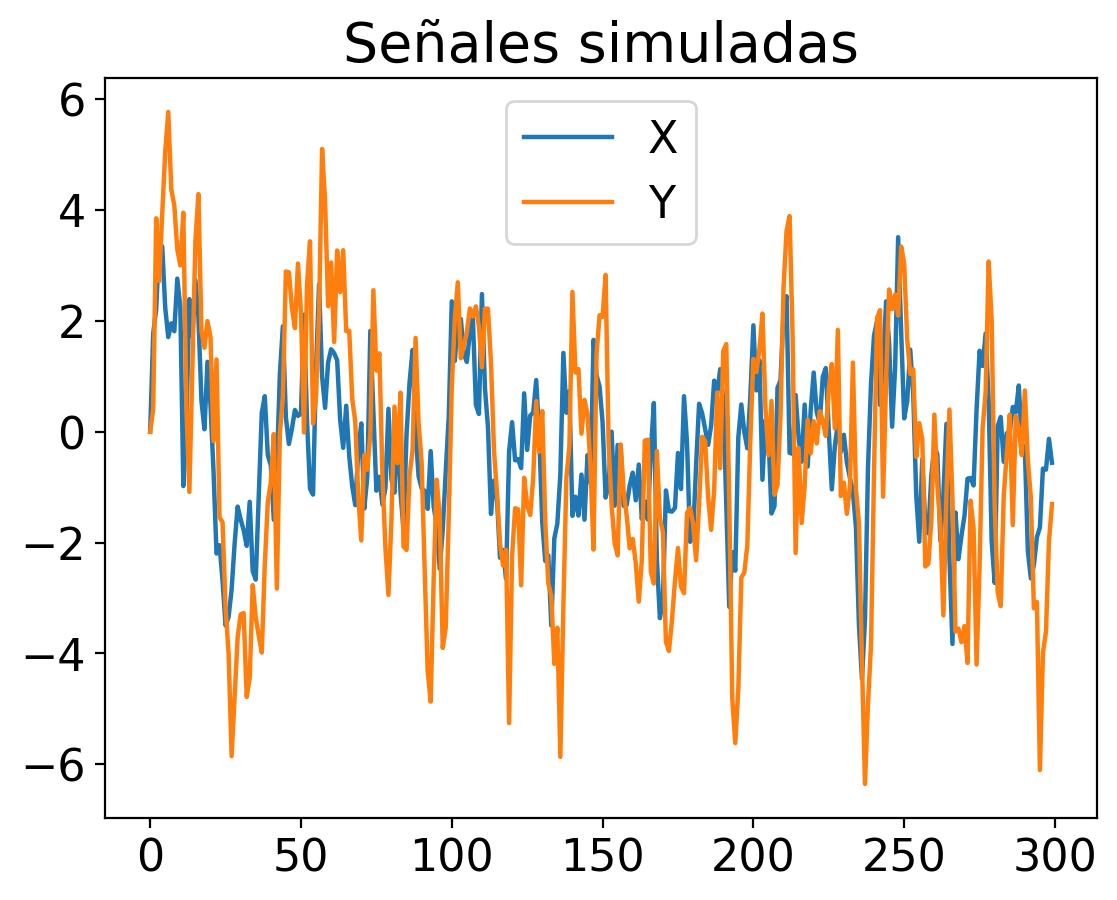

Causalidad X → Y

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=301.3121, p=0.0000  , df_denom=296, df_num=1
ssr based chi2 test:   chi2=304.3659, p=0.0000  , df=1
likelihood ratio test: chi2=209.9220, p=0.0000  , df=1
parameter F test:         F=301.3121, p=0.0000  , df_denom=296, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=148.4921, p=0.0000  , df_denom=293, df_num=2
ssr based chi2 test:   chi2=302.0522, p=0.0000  , df=2
likelihood ratio test: chi2=208.5771, p=0.0000  , df=2
parameter F test:         F=148.4921, p=0.0000  , df_denom=293, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=99.2862 , p=0.0000  , df_denom=290, df_num=3
ssr based chi2 test:   chi2=305.0484, p=0.0000  , df=3
likelihood ratio test: chi2=209.8619, p=0.0000  , df=3
parameter F test:         F=99.2862 , p=0.0000  , df_denom=290, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=75.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


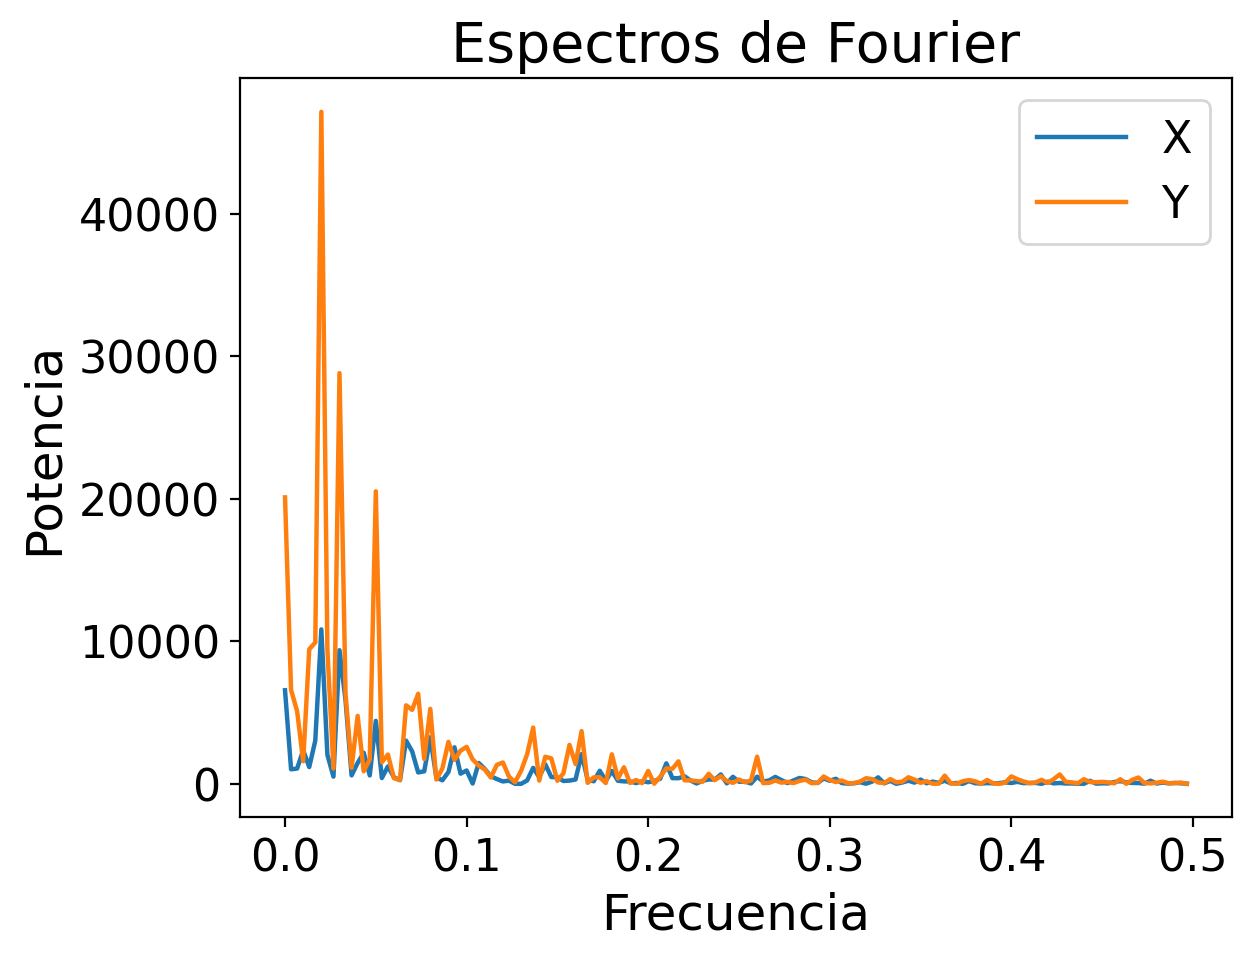

In [8]:
# Datos sintéticos con causalidad X -> Y
np.random.seed(0)
n = 300
x = np.zeros(n)
y = np.zeros(n)

for t in range(1, n):
    x[t] = 0.7*x[t-1] + np.random.normal(0, 1)
    y[t] = 0.5*y[t-1] + 0.8*x[t-1] + np.random.normal(0, 1)

data = np.column_stack([x, y])

# Visualizar
plt.plot(x, label='X')
plt.plot(y, label='Y')
plt.legend()
plt.title("Señales simuladas")
plt.show()

# Test de Granger (tiempo)
print("Causalidad X → Y")
grangercausalitytests(data[:, [1,0]], maxlag=5, verbose=True)

# Ajustar VAR
model = VAR(data)
results = model.fit(5)

# Espectro clásico (Fourier)
fx = np.abs(np.fft.fft(x))**2
fy = np.abs(np.fft.fft(y))**2
freqs = np.fft.fftfreq(len(x))

plt.plot(freqs[:len(freqs)//2], fx[:len(fx)//2], label="X")
plt.plot(freqs[:len(freqs)//2], fy[:len(fy)//2], label="Y")
plt.legend()
plt.xlabel("Frecuencia")
plt.ylabel("Potencia")
plt.title("Espectros de Fourier")
plt.show()

### Reducción de dimensiónes

####  Principal Component Analysis (PCA)

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que transforma un conjunto de variables posiblemente correlacionadas en un nuevo conjunto de variables no correlacionadas llamadas **componentes principales**.

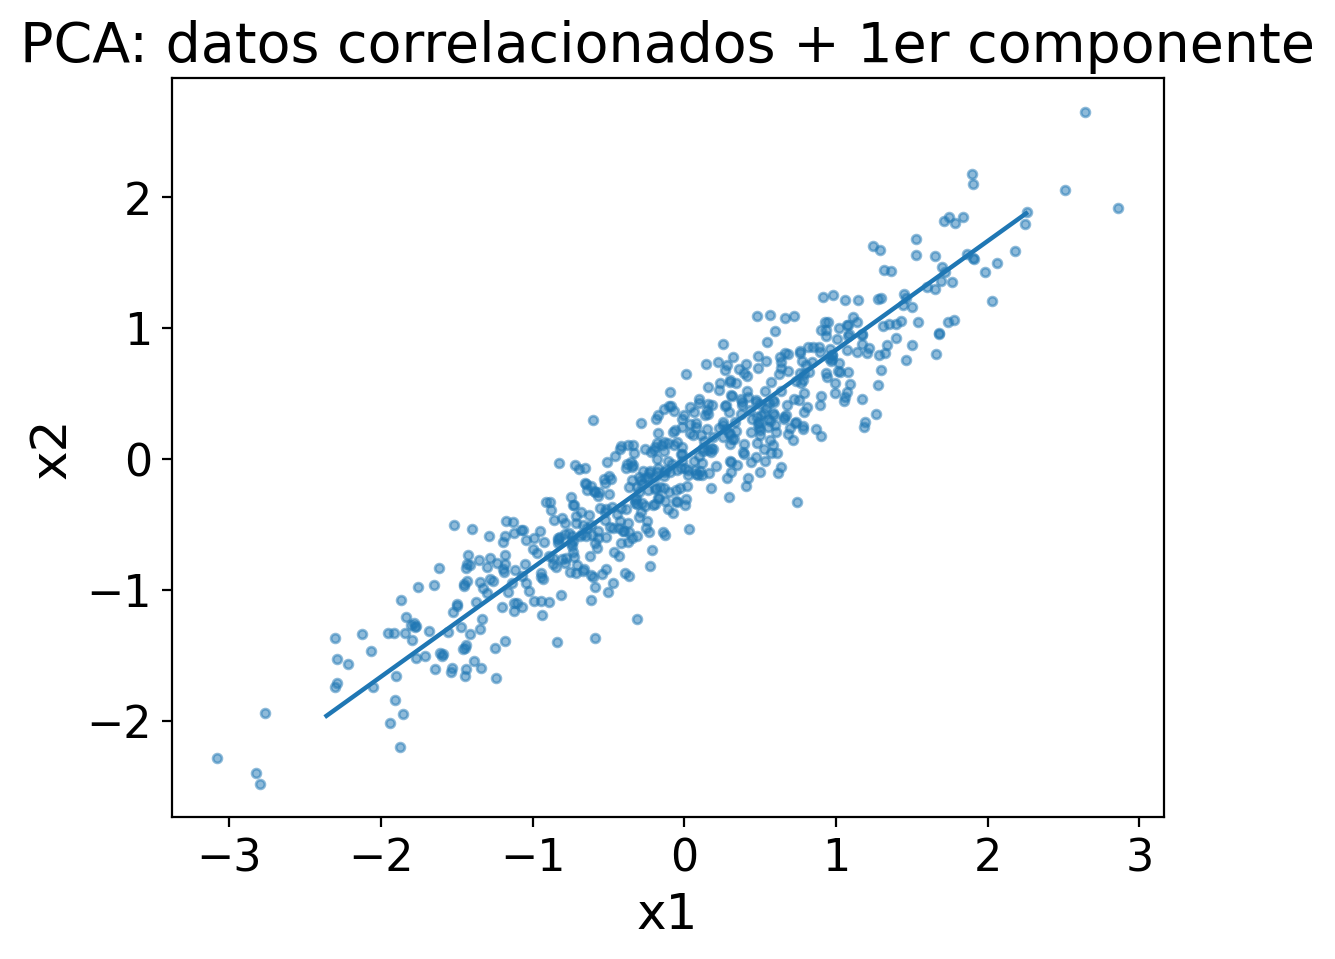

Varianza explicada por componente: [0.96848502 0.03151498]


In [19]:
# PCA (sklearn)
try:
    from sklearn.decomposition import PCA
except Exception as e:
    raise ImportError("Falta scikit-learn. Instala con: pip install scikit-learn") from e

np.random.seed(7)

# Datos 2D correlacionados
n = 600
x = np.random.normal(size=n)
y = 0.8*x + 0.3*np.random.normal(size=n)
X = np.c_[x, y]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Dirección del primer componente en el espacio original
pc1 = pca.components_[0]  # vector unitario
mu = X.mean(axis=0)

plt.figure()
plt.scatter(X[:,0], X[:,1], s=10, alpha=0.5)
# línea del PC1
scale = 3.0
plt.plot([mu[0]-scale*pc1[0], mu[0]+scale*pc1[0]],
         [mu[1]-scale*pc1[1], mu[1]+scale*pc1[1]])
plt.title("PCA: datos correlacionados + 1er componente")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

print("Varianza explicada por componente:", pca.explained_variance_ratio_)


#### Independent Component Analysis (ICA)

Mientras que el PCA busca direcciones de máxima varianza, el **Análisis de Componentes Independientes** busca descomponer la señal observada en un conjunto de fuentes estadísticamente independientes.

La idea fundamental es que los datos multicanal observados pueden modelarse como combinaciones lineales de fuentes subyacentes independientes


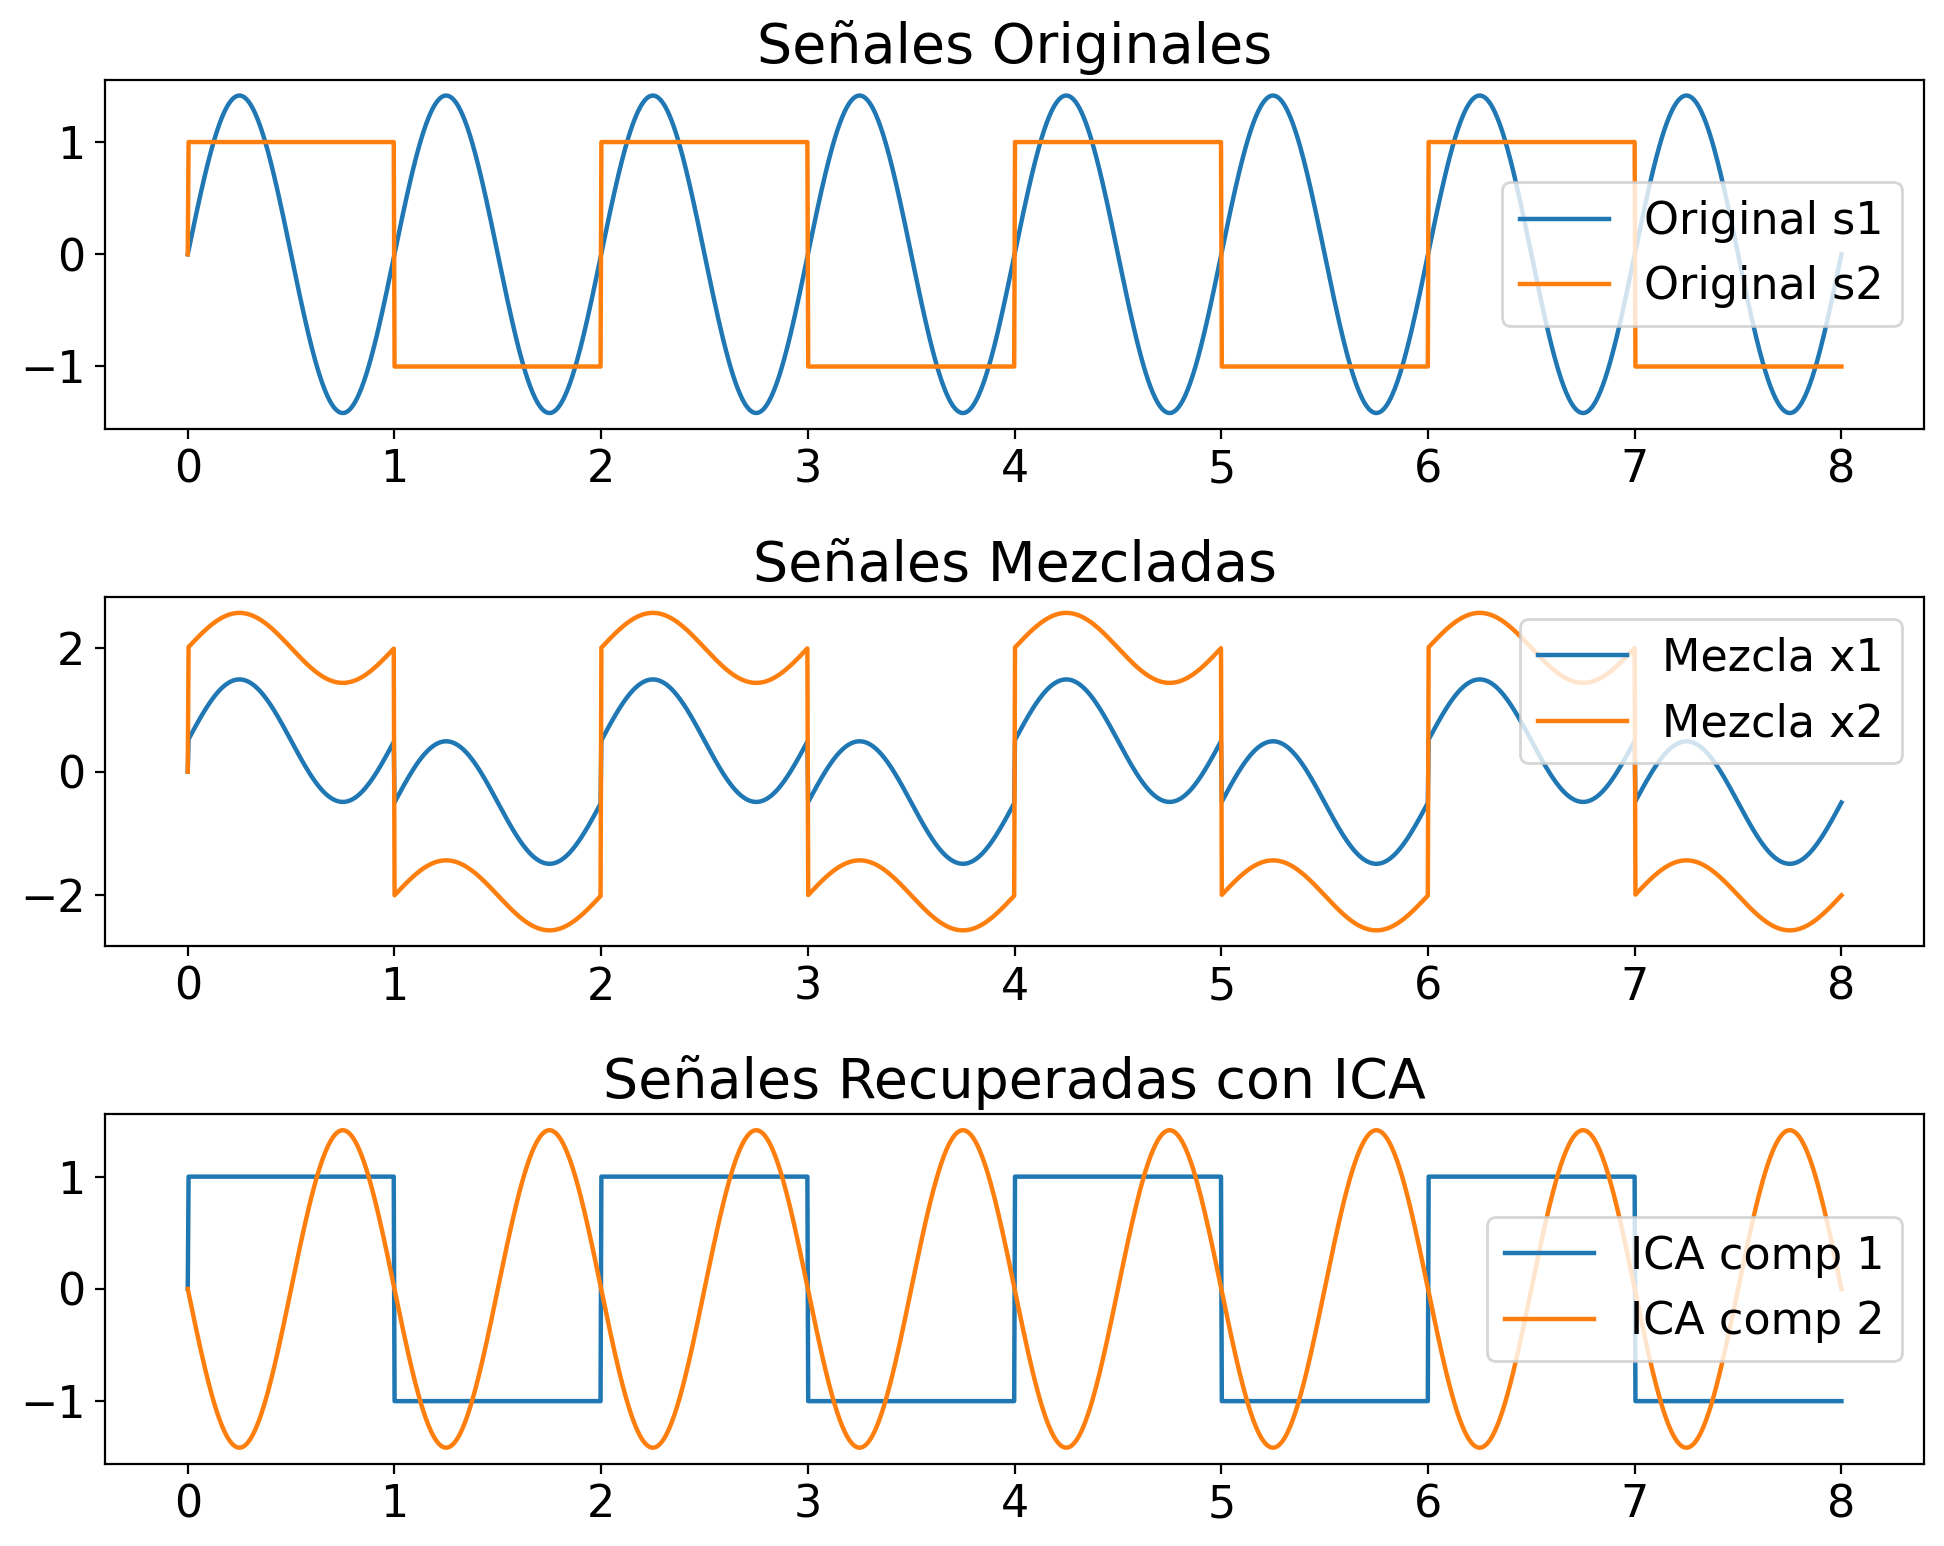

In [50]:
np.random.seed(1)

n=2000
t= np.linspace(0,8,n)

#Señal 1
S1= np.sin(2 * np.pi *t)

#Señal 2
S2 = np.sign(np.sin(2 * np.pi * 0.5 * t))

#Juntamos las señales en una Matriz
S = np.c_[S1,S2] #Concatenamos las 2 señales

S /= S.std(axis=0) # El operador /= significa, a /= b es lo mismo que a = a/b

#Mezclar señales
A = np.array([[0.7, 0.5],
              [0.4, 2]])

X = S @ A.T  #  @ es el operador de multipicación de matrices :)

# ICA

ica = FastICA(n_components=2)
S_ica = ica.fit_transform(X)


#Grafica 


fig, ax = plt.subplots(3, 1, figsize=(10, 8))

ax[0].plot(t, S[:,0], label="Original s1")
ax[0].plot(t, S[:,1], label="Original s2")
ax[0].set_title("Señales Originales")
ax[0].legend()

ax[1].plot(t, X[:,0], label="Mezcla x1")
ax[1].plot(t, X[:,1], label="Mezcla x2")
ax[1].set_title("Señales Mezcladas")
ax[1].legend()

ax[2].plot(t, S_ica[:,0], label="ICA comp 1")
ax[2].plot(t, S_ica[:,1], label="ICA comp 2")
ax[2].set_title("Señales Recuperadas con ICA")
ax[2].legend()

plt.tight_layout()
plt.show()


**Otro ejemplo de señales mezcladas**

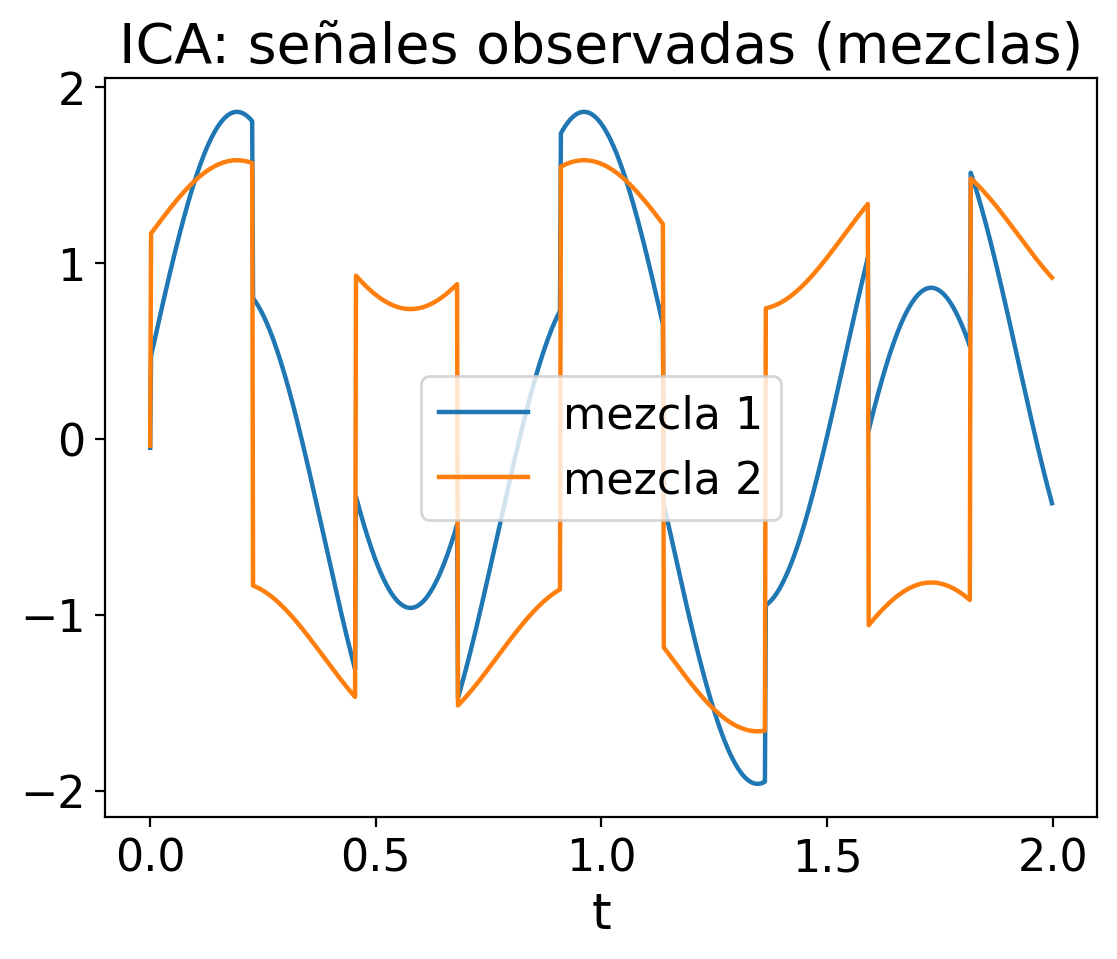

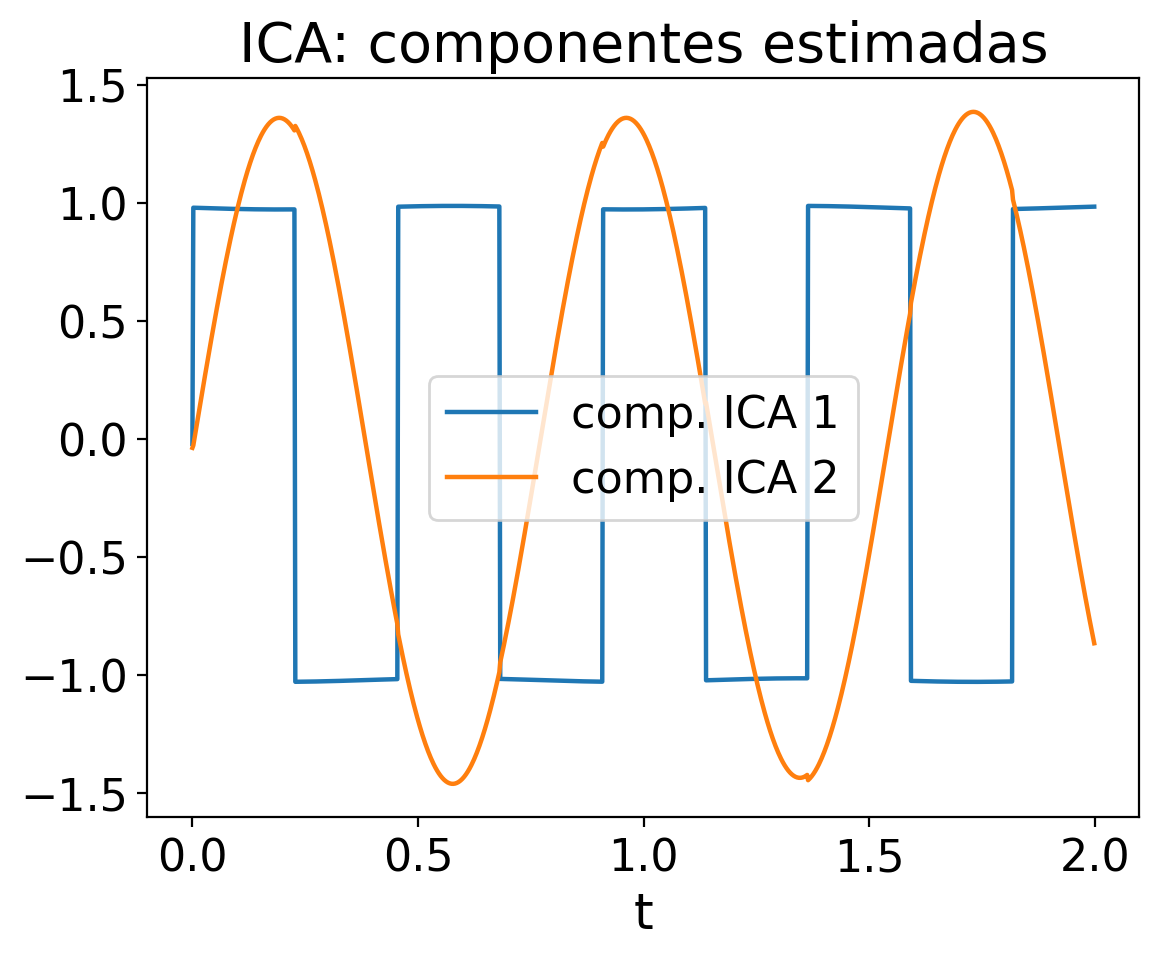

In [53]:
try:
    from sklearn.decomposition import FastICA
except Exception as e:
    raise ImportError("Falta scikit-learn. Instala con: pip install scikit-learn") from e

np.random.seed(0)
n = 4000
t = np.linspace(0, 8, n)

# Fuentes independientes (S)
s1 = np.sin(2*np.pi*1.3*t)
s2 = np.sign(np.sin(2*np.pi*2.2*t))
S = np.c_[s1, s2]
S = (S - S.mean(axis=0)) / S.std(axis=0)

# Mezcla lineal observada (X)
A = np.array([[1.0, 0.5],
              [0.3, 1.2]])
X = S @ A.T

ica = FastICA(n_components=2, random_state=0, max_iter=2000)
S_hat = ica.fit_transform(X)  # estimación de fuentes

plt.figure()
plt.plot(t[:1000], X[:1000,0], label="mezcla 1")
plt.plot(t[:1000], X[:1000,1], label="mezcla 2")
plt.title("ICA: señales observadas (mezclas)")
plt.xlabel("t")
plt.legend()
plt.show()

plt.figure()
plt.plot(t[:1000], S_hat[:1000,0], label="comp. ICA 1")
plt.plot(t[:1000], S_hat[:1000,1], label="comp. ICA 2")
plt.title("ICA: componentes estimadas")
plt.xlabel("t")
plt.legend()
plt.show()

Ahora realizaremos un ejemplo de ICA con 2 audios diferentes, simulando una situación como la presentada en el sección de ICA del apendice de Reducción de dimensionlidad del texto

In [54]:
#Cargamos los archivos
S1_V = "/Users/danielyedra/Desktop/Universidad/Referencias_APF/844529__smallclone__heavy-guitar-loop-70-bpm-in-c-major.wav"
S2_V = "/Users/danielyedra/Desktop/Universidad/Referencias_APF/845002__madgravitystudio__lost-words-feat.wav"

sr1, s1 = wavfile.read(S1_V)
sr2, s2 = wavfile.read(S2_V)

print("Frecuencia de muestreo señal 1:", sr1)
print("Frecuencia de muestreo señal 2:", sr2)
print("Número de muestras y canales, señal 1:", s1.shape)
print("Número de muestras y canales, señal 2:", s2.shape)

# Si vienen en estéreo, pasamos a mono (promedio canales)
if s1.ndim == 2:
    s1 = s1.mean(axis=1)
if s2.ndim == 2:
    s2 = s2.mean(axis=1)

# Pasamos a float y normalización [-1, 1]
def to_float(x):
    x = x.astype(np.float32)
    m = np.max(np.abs(x))
    return x/m if m > 0 else x

def mix_sources(sources, apply_noise=False):
    for i in range(len(sources)):

        #Normalización
        max_val = np.max(np.abs(sources[i]))
        if max_val > 1:
            sources[i] = sources[i] / max_val
            
    # Combinar fuentes
    mixture = np.c_[[source for source in sources]]
    
    if apply_noise:
        
        # Añadimos ruido
        mixture += 0.02 * np.random.normal(size=mixture.shape)
        
    return mixture

s1 = to_float(s1)
s2 = to_float(s2)

# Condición sobre los sampling rates
if sr1 != sr2:
    raise ValueError(f"Sampling rates distintos: {sr1} vs {sr2}. Resamplea una señal para igualarlos.")

sr = sr1
N = min(len(s1), len(s2))
s1 = s1[:N]
s2 = s2[:N]

S = np.c_[s1, s2]  # matriz Nx2
print("Matriz S=(s1,s2)")
print("S:", S.shape)

sampling_rate = sr1

# Mezclamos las señales
x = mix_sources([s1, s2[:s1.shape[0]]], False)
print(f'Tamaño señal 1 (s1): {s1.shape}, s2: {s1.shape}, Combinación lineal: {x.shape}')
wf.write('./talk_and_music.wav', sampling_rate, x.mean(axis=0).astype(np.float32))

Frecuencia de muestreo señal 1: 44100
Frecuencia de muestreo señal 2: 44100
Número de muestras y canales, señal 1: (1360800, 2)
Número de muestras y canales, señal 2: (2540287, 2)
Matriz S=(s1,s2)
S: (1360800, 2)
Tamaño señal 1 (s1): (1360800,), s2: (1360800,), Combinación lineal: (2, 1360800)


/var/folders/kp/6z23sv5s1cb7rkrzzzslh1qc0000gn/T/ipykernel_10466/940885187.py:5: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr1, s1 = wavfile.read(S1_V)


In [52]:
def center(x):
    x = np.array(x)
    return x - x.mean(axis=1, keepdims=True)

def whiten(x):
    eigen_values, eigen_vectors = np.linalg.eigh(np.cov(x))
    D = np.diag(eigen_values)
    sqrt_inverse_D = np.sqrt(np.linalg.inv(D))
    x_whiten = eigen_vectors @ (sqrt_inverse_D @ (eigen_vectors.T @ x))
    
    print(f'Tamaño Eigen Valores: {eigen_values.shape}, Eigen Vectores: {eigen_vectors.shape}, Datos Transformados por Whitening: {x_whiten.shape}')
    
    return x_whiten, D, eigen_vectors

X_whiten, D, E = whiten(
    center(x)
)
D, E

Tamaño Eigen Valores: (2,), Eigen Vectores: (2, 2), Datos Transformados por Whitening: (2, 1360800)


(array([[0.01482963, 0.        ],
        [0.        , 0.02147549]]),
 array([[-0.99942172,  0.03400326],
        [ 0.03400326,  0.99942172]]))

#### Uniform Manifold Approximation and Projection (UMAP)

UMAP es una técnica **no lineal** de reducción de dimensión (similar en espíritu a t-SNE, pero suele escalar mejor) que busca preservar estructura local del espacio de alta dimensión.

> Nota: si tu entorno no tiene `umap-learn`, el bloque intenta instalarlo vía pip (puedes comentar esa línea si no tienes permisos).


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


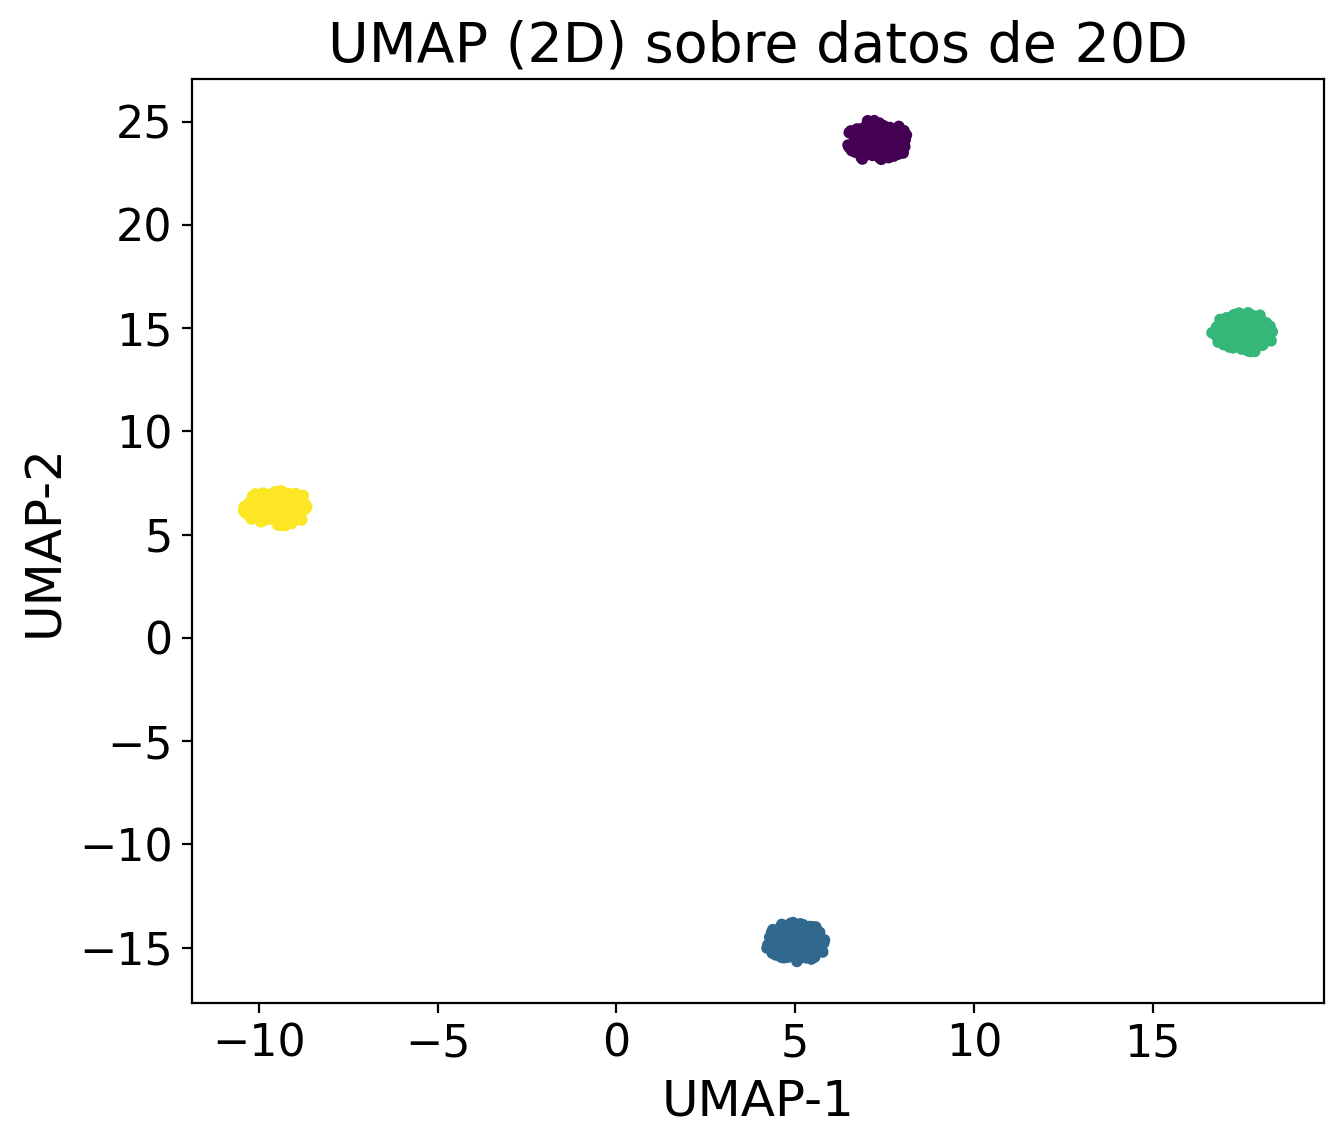

In [55]:
# Ejemplo UMAP 
try:
    import umap
except Exception as e: #En caso de no tener el paquete
    try:
        import sys
        !{sys.executable} -m pip install umap-learn
        import umap
    except Exception as e2:
        print("No se pudo importar/instalar umap-learn. Error:", e2)
        umap = None

if umap is not None:
    from sklearn.datasets import make_blobs

    X, y = make_blobs(n_samples=800, centers=4, n_features=20, random_state=42, cluster_std=2.2)

    reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)

    plt.figure(figsize=(7,6))
    plt.scatter(X_umap[:,0], X_umap[:,1], c=y, s=10)
    plt.title("UMAP (2D) sobre datos de 20D")
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
    plt.tight_layout()
